# DATA PREPARATION + EDA

## import data

data diambil dari sumber resmi Bank Indonesia dan disimpan dalam format excel

In [2]:
import pandas as pd

usd = pd.read_excel("USD.xlsx")
cny = pd.read_excel("CNY.xlsx")

print(usd.columns)
print(cny.columns)

Index(['Kurs Jual', 'Kurs Beli', 'Tanggal'], dtype='str')
Index(['Kurs Jual', 'Kurs Beli', 'Tanggal'], dtype='str')


## konversi formal tanggal & urutan (ascending)

data dikonversi datetime lalu diurut secara kronologis

In [3]:
usd['Tanggal'] = pd.to_datetime(usd['Tanggal'], errors='coerce')
usd = usd.sort_values('Tanggal')
usd = usd.reset_index(drop=True)

cny['Tanggal'] = pd.to_datetime(cny['Tanggal'], errors='coerce')
cny = cny.sort_values('Tanggal')
cny = cny.reset_index(drop=True)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_2828\3092525204.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  usd['Tanggal'] = pd.to_datetime(usd['Tanggal'], errors='coerce')
C:\Users\ASUS\AppData\Local\Temp\ipykernel_2828\3092525204.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cny['Tanggal'] = pd.to_datetime(cny['Tanggal'], errors='coerce')


In [4]:
print("Tanggal invalid USD:", usd['Tanggal'].isnull().sum())
print("Tanggal invalid CNY:", cny['Tanggal'].isnull().sum())

Tanggal invalid USD: 0
Tanggal invalid CNY: 0


## hitung kurs tengah

Kurs tengah merupakan nilai tukar yang dihitung dari rata-rata kurs jual dan kurs beli yang berasal dari transaksi valuta asing, sehingga sering digunakan sebagai representasi nilai tukar yang lebih netral dalam analisis ekonomi dan penelitian akademik.

In [5]:
usd['Kurs Jual'] = pd.to_numeric(usd['Kurs Jual'], errors='coerce')
usd['Kurs Beli'] = pd.to_numeric(usd['Kurs Beli'], errors='coerce')
usd['Kurs Tengah'] = (usd['Kurs Jual'] + usd['Kurs Beli']) / 2
usd = usd[['Tanggal', 'Kurs Tengah']]
usd.set_index('Tanggal', inplace=True)
usd = usd.sort_index()

cny['Kurs Jual'] = pd.to_numeric(cny['Kurs Jual'], errors='coerce')
cny['Kurs Beli'] = pd.to_numeric(cny['Kurs Beli'], errors='coerce')
cny['Kurs Tengah'] = (cny['Kurs Jual'] + cny['Kurs Beli']) / 2
cny = cny[['Tanggal', 'Kurs Tengah']]
cny.set_index('Tanggal', inplace=True)
cny = cny.sort_index()

Model LSTM dan GRU pada penelitian ini menggunakan univariate time series, yaitu hanya satu variabel utama yang diprediksi. lalu, kolom Tanggal diset sebagai index dataset untuk mempermudah proses pembuatan window sequence

## cek missing value & duplikat

memastikan tidak ada data kosong dan kemunculan tanggal lebih dari satu kali

In [6]:
print("Missing USD:", usd.isnull().sum())
print("Missing CNY:", cny.isnull().sum())

print("Duplicate USD:", usd.index.duplicated().sum())
print("Duplicate CNY:", cny.index.duplicated().sum())

Missing USD: Kurs Tengah    0
dtype: int64
Missing CNY: Kurs Tengah    0
dtype: int64
Duplicate USD: 0
Duplicate CNY: 0


eksplor awal untuk memastikan kedua dataset sudah sama-sama imbang agar fair digunakan untuk penelitian komparatif

In [7]:
print("USD:", usd.index.min(), "sampai", usd.index.max())
print("CNY:", cny.index.min(), "sampai", cny.index.max())
print("Jumlah data USD:", len(usd))
print("Jumlah data CNY:", len(cny))

USD: 2020-01-02 00:00:00 sampai 2026-02-20 00:00:00
CNY: 2020-01-02 00:00:00 sampai 2026-02-20 00:00:00
Jumlah data USD: 1498
Jumlah data CNY: 1498


In [8]:
print("Frekuensi index USD:", pd.infer_freq(usd.index))
print("Frekuensi index CNY:", pd.infer_freq(cny.index))

Frekuensi index USD: None
Frekuensi index CNY: None


In [9]:
usd.info()
usd.describe()

<class 'pandas.DataFrame'>
DatetimeIndex: 1498 entries, 2020-01-02 to 2026-02-20
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Kurs Tengah  1498 non-null   float64
dtypes: float64(1)
memory usage: 23.4 KB


,Kurs Tengah
count,1498.000000
mean,15238.966338
std,868.172313
min,13612.000000
25%,14421.005000
50%,15142.000000
75%,15942.750000
max,16981.000000


In [10]:
cny.info()
cny.describe()

<class 'pandas.DataFrame'>
DatetimeIndex: 1498 entries, 2020-01-02 to 2026-02-20
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Kurs Tengah  1498 non-null   float64
dtypes: float64(1)
memory usage: 23.4 KB


,Kurs Tengah
count,1498.000000
mean,2202.813855
std,82.937336
min,1954.320000
25%,2163.928750
50%,2208.905000
75%,2247.440000
max,2449.830000


## grafik awal

visualisasi awal untuk melihat pergerakan kurs sebelum dilakukan pemodelan

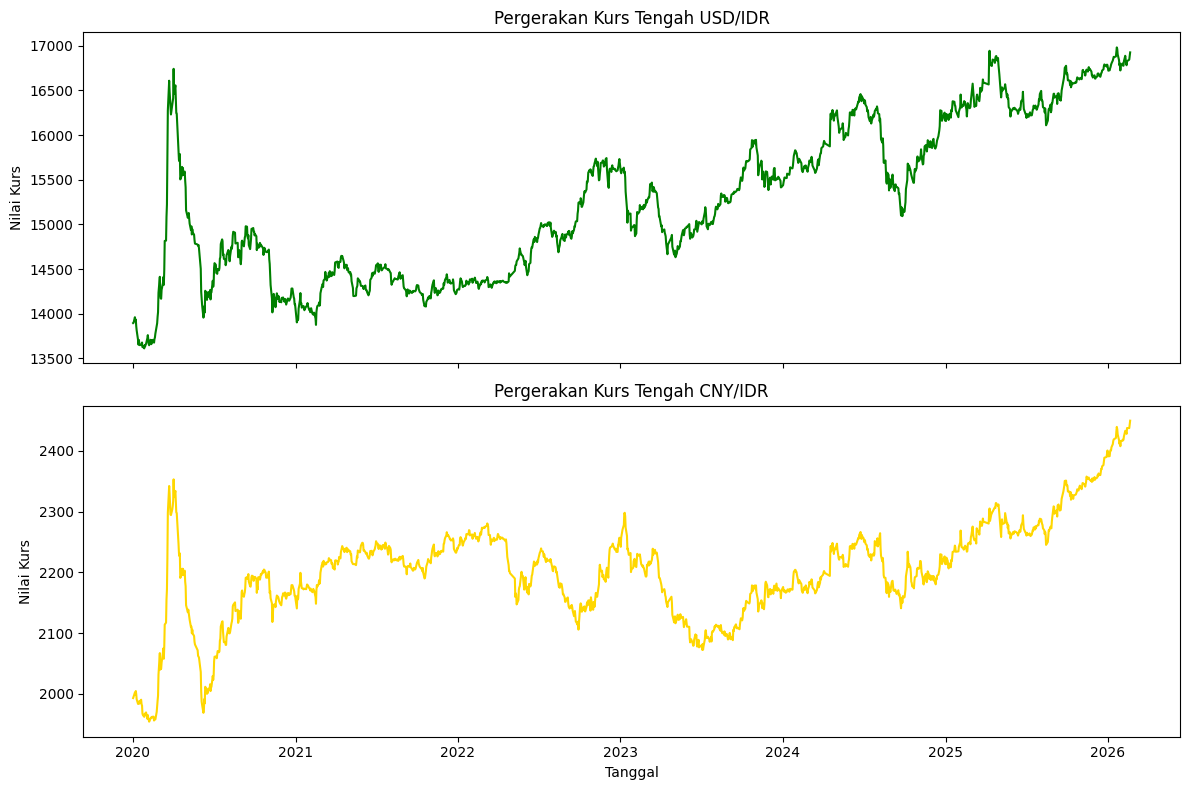

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(usd.index, usd['Kurs Tengah'], color='green')
axes[0].set_title('Pergerakan Kurs Tengah USD/IDR')
axes[0].set_ylabel('Nilai Kurs')

axes[1].plot(cny.index, cny['Kurs Tengah'], color = 'gold')
axes[1].set_title('Pergerakan Kurs Tengah CNY/IDR')
axes[1].set_ylabel('Nilai Kurs')
axes[1].set_xlabel('Tanggal')

plt.tight_layout()
plt.show()

Hal ini menunjukkan bahwa nilai Rupiah cenderung mengalami depresiasi terhadap USD maupun CNY dalam periode tersebut. 

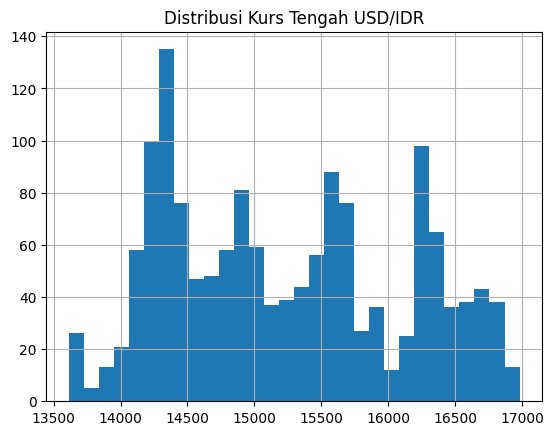

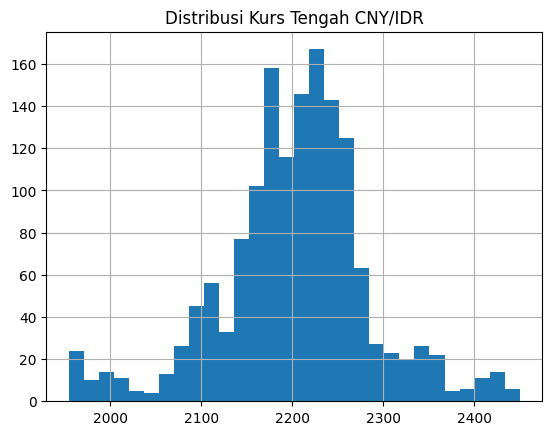

In [12]:
usd['Kurs Tengah'].hist(bins=30)
plt.title('Distribusi Kurs Tengah USD/IDR')
plt.show()

cny['Kurs Tengah'].hist(bins=30)
plt.title('Distribusi Kurs Tengah CNY/IDR')
plt.show()

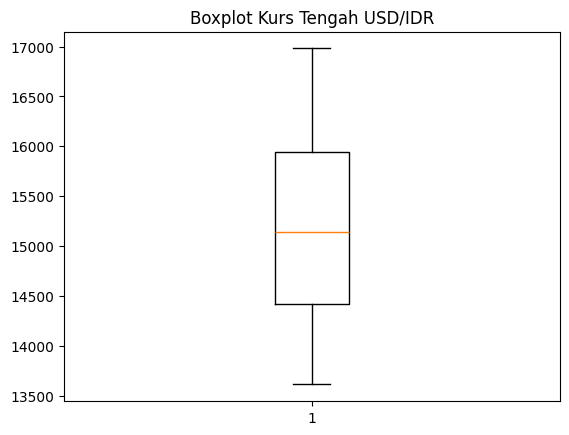

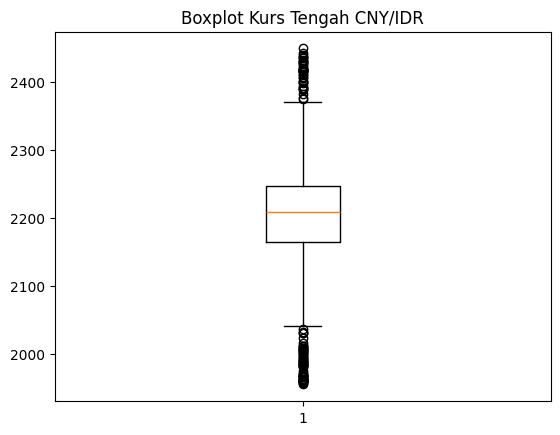

In [13]:
plt.boxplot(usd['Kurs Tengah'])
plt.title('Boxplot Kurs Tengah USD/IDR')
plt.show()

plt.boxplot(cny['Kurs Tengah'])
plt.title('Boxplot Kurs Tengah CNY/IDR')
plt.show()

# PREPROCESSING

## split data training dan testing (time-based split)

Pada time series, data tidak boleh diacak seperti data klasifikasi biasa, karena model harus belajar dari masa lalu untuk memprediksi masa depan. data awal untuk training, data setelahnya untuk validation, dan data akhir untuk testing, ini meniru kondisi dunia nyata, yaitu model dilatih pada data historis lalu diuji pada data yang benar-benar lebih baru.

In [14]:
def split_data(df, train_ratio=0.7, val_ratio=0.15):
    n = len(df)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))
    assert train_ratio + val_ratio < 1, "train_ratio + val_ratio harus < 1"
    train = df.iloc[:train_end]
    val = df.iloc[train_end:val_end]
    test = df.iloc[val_end:]
    return train, val, test

In [15]:
usd_train, usd_val, usd_test = split_data(usd)
cny_train, cny_val, cny_test = split_data(cny)

print("USD lens:", len(usd_train), len(usd_val), len(usd_test))
print("CNY lens:", len(cny_train), len(cny_val), len(cny_test))

print("USD Train:", usd_train.index.min(), "-", usd_train.index.max())
print("USD Val  :", usd_val.index.min(), "-", usd_val.index.max())
print("USD Test :", usd_test.index.min(), "-", usd_test.index.max())

print("CNY Train:", cny_train.index.min(), "-", cny_train.index.max())
print("CNY Val  :", cny_val.index.min(), "-", cny_val.index.max())
print("CNY Test :", cny_test.index.min(), "-", cny_test.index.max())

USD lens: 1048 225 225
CNY lens: 1048 225 225
USD Train: 2020-01-02 00:00:00 - 2024-03-28 00:00:00
USD Val  : 2024-04-01 00:00:00 - 2025-03-10 00:00:00
USD Test : 2025-03-11 00:00:00 - 2026-02-20 00:00:00
CNY Train: 2020-01-02 00:00:00 - 2024-03-28 00:00:00
CNY Val  : 2024-04-01 00:00:00 - 2025-03-10 00:00:00
CNY Test : 2025-03-11 00:00:00 - 2026-02-20 00:00:00


rasio 75:15:15 cukup seimbang/fair, karena training cukup besar untuk belajar pola, validation untuk tuning dan early stopping, dan test untuk evaluasi akhir.

## normalisasi: minmaxscaler

mengubah rentang data 0 sampai 1. normalisasi perlu agar LSTM dan GRU lebih stabil apabila input berada pada skala yang seragam dan mengurangi risiko dominasi nilai yang terlalu besar. it_transform() hanya pada data training, lalu transform() pada validation dan test agar tidak terjadi data leakage.

In [18]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

usd_scaler = MinMaxScaler(feature_range=(0,1))
cny_scaler = MinMaxScaler(feature_range=(0,1))

usd_train_scaled = usd_scaler.fit_transform(usd_train)
usd_val_scaled   = usd_scaler.transform(usd_val)
usd_test_scaled  = usd_scaler.transform(usd_test)

cny_train_scaled = cny_scaler.fit_transform(cny_train)
cny_val_scaled   = cny_scaler.transform(cny_val)
cny_test_scaled  = cny_scaler.transform(cny_test)

usd_train_scaled = usd_train_scaled.astype(np.float32)
usd_val_scaled = usd_val_scaled.astype(np.float32)
usd_test_scaled = usd_test_scaled.astype(np.float32)

cny_train_scaled = cny_train_scaled.astype(np.float32)
cny_val_scaled = cny_val_scaled.astype(np.float32)
cny_test_scaled = cny_test_scaled.astype(np.float32)

## sliding window = 30 hari (awal)

LSTM dan GRU tidak menerima data dalam bentuk deret tunggal biasa. Keduanya membutuhkan input berbentuk sequence, yaitu kumpulan langkah waktu sebelumnya. penelitian ini berfokus pada one-step ahead forecasting, maka targetnya 1 langkah ke depan. 

Pada data validation,  menambahkan 30 data terakhir dari training ke awal validation agar sequence validation tetap memiliki konteks historis. Ini penting karena model membutuhkan data sebelumnya untuk membentuk window prediksi

input : 30 hari sebelumnya
output: kurs hari berikutnya

In [19]:
import numpy as np

def create_sequences_t1(series_2d, window_size):
    X, y = [], []
    for i in range(window_size, len(series_2d)):
        X.append(series_2d[i-window_size:i])
        y.append(series_2d[i])
    return np.array(X), np.array(y)

window_size = 30

# ===== USD =====
X_train_usd, y_train_usd = create_sequences_t1(usd_train_scaled, window_size)
val_input_usd = np.vstack([usd_train_scaled[-window_size:], usd_val_scaled])
X_val_usd, y_val_usd = create_sequences_t1(val_input_usd, window_size)
test_input_usd = np.vstack([val_input_usd[-window_size:], usd_test_scaled])
X_test_usd, y_test_usd = create_sequences_t1(test_input_usd, window_size)

# ===== CNY =====
X_train_cny, y_train_cny = create_sequences_t1(cny_train_scaled, window_size)
val_input_cny = np.vstack([cny_train_scaled[-window_size:], cny_val_scaled])
X_val_cny, y_val_cny = create_sequences_t1(val_input_cny, window_size)
test_input_cny = np.vstack([val_input_cny[-window_size:], cny_test_scaled])
X_test_cny, y_test_cny = create_sequences_t1(test_input_cny, window_size)

In [20]:
print("USD Train:", X_train_usd.shape, y_train_usd.shape)
print("USD Val  :", X_val_usd.shape, y_val_usd.shape)
print("USD Test :", X_test_usd.shape, y_test_usd.shape)
print("CNY Train:", X_train_cny.shape, y_train_cny.shape)
print("CNY Val  :", X_val_cny.shape, y_val_cny.shape)
print("CNY Test :", X_test_cny.shape, y_test_cny.shape)

USD Train: (1018, 30, 1) (1018, 1)
USD Val  : (225, 30, 1) (225, 1)
USD Test : (225, 30, 1) (225, 1)
CNY Train: (1018, 30, 1) (1018, 1)
CNY Val  : (225, 30, 1) (225, 1)
CNY Test : (225, 30, 1) (225, 1)


# PEMODELAN

## skenario 1

deklrasi metrik MAPE manual untuk menghindari pembagian nol, lalu menambahkan callback agar training berhenti otomatis saat model sudah konvergen dan untuk menurunkan learning rate ketika validasi stagnan. Ini dilakukan supaya model tidak overfitting dan proses training lebih efisien.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


def mape(y_true, y_pred, eps=1e-8):
    y_true = np.array(y_true).reshape(-1)
    y_pred = np.array(y_pred).reshape(-1)
    denom = np.maximum(np.abs(y_true), eps)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100.0

def evaluate_regression(y_true, y_pred):
    y_true = np.array(y_true).reshape(-1)
    y_pred = np.array(y_pred).reshape(-1)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_val = mape(y_true, y_pred)
    return mae, rmse, mape_val


def get_converge_callbacks(patience=20, min_delta=1e-5):
    early_stop = EarlyStopping(
        monitor="val_loss",
        mode='min',
        patience=patience,
        min_delta=min_delta,
        restore_best_weights=True
    )
    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        mode='min',
        factor=0.5,
        patience=max(5, patience // 3),
        min_lr=1e-6,
        verbose=0
    )
    return [early_stop, reduce_lr]

Untuk baseline LSTM menggunakan arsitektur sederhana, yaitu satu layer LSTM dengan 64 unit dan satu layer output. Tujuannya agar model baseline tetap sederhana dan bisa dijadikan pembanding awal terhadap GRU. Model baseline GRU  dibuat dengan struktur yang setara dengan baseline LSTM, sehingga perbandingan keduanya adil. Perbedaan utama hanya terletak pada jenis recurrent unit-nya, yaitu LSTM dan GRU.

In [22]:
def build_lstm_baseline(input_shape, units=64, learning_rate=1e-3):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(units),
        Dense(1)
    ])
    opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=opt, loss="mse")
    return model

def build_gru_baseline(input_shape, units=64, learning_rate=1e-3):
    model = Sequential([
        Input(shape=input_shape),
        GRU(units),
        Dense(1)
    ])
    opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=opt, loss="mse")
    return model

train sampai konvergendengan validation loss sebagai acuan

Setelah model melakukan prediksi pada data test, hasil prediksi dikembalikan ke skala asli menggunakan inverse transform. Setelah itu hitung MAE, RMSE, dan MAPE berdasarkan nilai aktual dan prediksi dalam satuan Rupiah.

In [23]:
import random
import numpy as np
import tensorflow as tf

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

def train_until_converge(
    model,
    X_train, y_train,
    X_val, y_val,
    max_epochs=500,
    batch_size=32,
    patience=20,
    min_delta=1e-5,
    verbose=1
):
    callbacks = get_converge_callbacks(patience=patience, min_delta=min_delta)
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=max_epochs,
        batch_size=batch_size,
        verbose=verbose,
        callbacks=callbacks
    )
    return history


def predict_inverse_and_metrics(model, X_test, y_test, scaler):
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_true_inv = scaler.inverse_transform(y_test)
    y_pred_inv = scaler.inverse_transform(y_pred_scaled)

    mae, rmse, mape_val = evaluate_regression(y_true_inv, y_pred_inv)
    results = {"MAE": mae, "RMSE": rmse, "MAPE(%)": mape_val}
    return results, y_true_inv.reshape(-1), y_pred_inv.reshape(-1)

plot loss train vs val

In [24]:
def plot_loss(history, title):
    plt.figure(figsize=(8, 4))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

BAGIAN INTI SKENARIO 1. training dengan parameter yang sama untuk lstm dan gru pada usd dan cny.


Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0295 - val_loss: 0.0117 - learning_rate: 0.0010
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0043 - val_loss: 0.0028 - learning_rate: 0.0010
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0031 - val_loss: 0.0024 - learning_rate: 0.0010
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0027 - val_loss: 0.0021 - learning_rate: 0.0010
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0024 - val_loss: 0.0023 - learning_rate: 0.0010
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0022 - val_loss: 0.0024 - learning_rate: 0.0010
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0020 - val_loss: 0.0023 - learning_rate: 0.0010
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0019 - val_loss: 0.0021 - learning_rate: 0.0010
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0018 - val_loss: 0.0018 - learning_rate: 0.0010
Epoch 10/

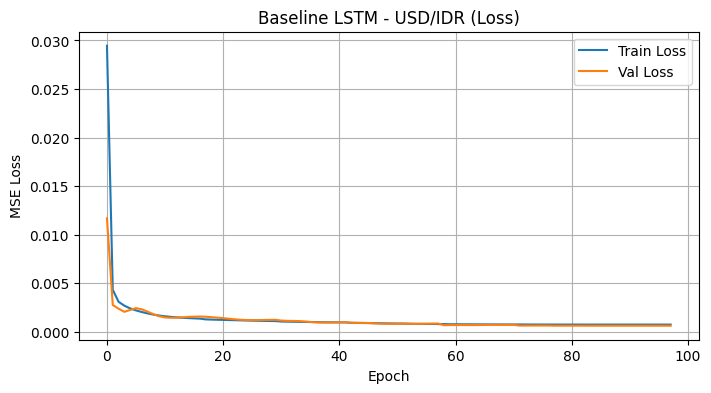

Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0349 - val_loss: 0.0320 - learning_rate: 0.0010
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0046 - val_loss: 0.0071 - learning_rate: 0.0010
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0020 - val_loss: 0.0014 - learning_rate: 0.0010
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0014 - val_loss: 9.6631e-04 - learning_rate: 0.0010
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0013 - val_loss: 9.2713e-04 - learning_rate: 0.0010
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0012 - val_loss: 8.9789e-04 - learning_rate: 0.0010
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0011 - val_loss: 8.7710e-04 - learning_rate: 0.0010
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0011 - val_loss: 8.7753e-04 - learning_rate: 0.0010
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 9.9990e-04 - val_loss: 8.9559e-04 - lear

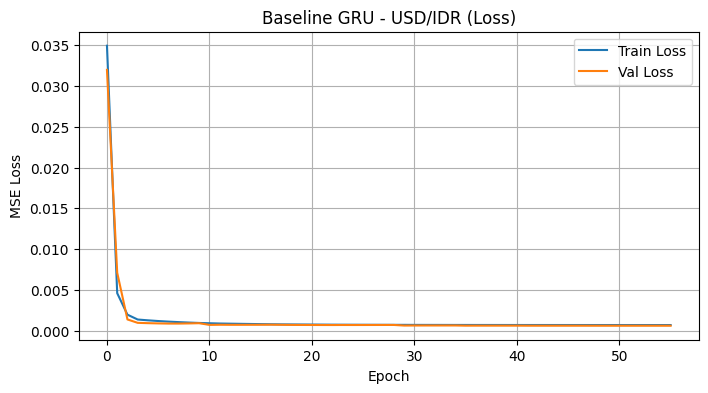

Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0515 - val_loss: 0.0042 - learning_rate: 0.0010
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0046 - val_loss: 0.0020 - learning_rate: 0.0010
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0037 - val_loss: 0.0019 - learning_rate: 0.0010
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0034 - val_loss: 0.0019 - learning_rate: 0.0010
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0031 - val_loss: 0.0018 - learning_rate: 0.0010
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0028 - val_loss: 0.0019 - learning_rate: 0.0010
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0026 - val_loss: 0.0021 - learning_rate: 0.0010
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0025 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0023 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 10/5

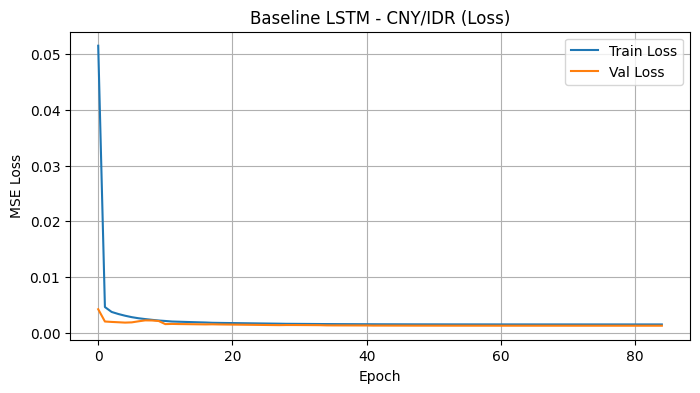

Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0627 - val_loss: 0.0054 - learning_rate: 0.0010
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0050 - val_loss: 0.0018 - learning_rate: 0.0010
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0032 - val_loss: 0.0016 - learning_rate: 0.0010
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0024 - val_loss: 0.0013 - learning_rate: 0.0010
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0019 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0015 - val_loss: 9.1108e-04 - learning_rate: 0.0010
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0013 - val_loss: 8.4538e-04 - learning_rate: 0.0010
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0012 - val_loss: 8.0420e-04 - learning_rate: 0.0010
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0012 - val_loss: 7.7367e-04 - learning_rate: 0

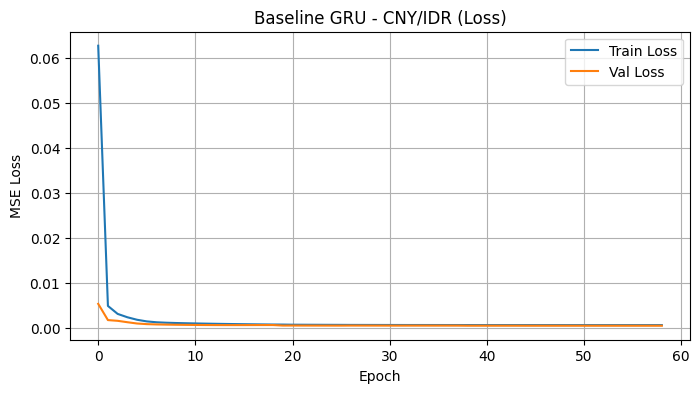

In [25]:
input_shape_usd = (X_train_usd.shape[1], X_train_usd.shape[2])  # (30, 1)
input_shape_cny = (X_train_cny.shape[1], X_train_cny.shape[2])  # (30, 1)

# usd
tf.keras.backend.clear_session()
set_seed(42)
lstm_usd = build_lstm_baseline(input_shape_usd, units=64, learning_rate=1e-3)
hist_lstm_usd = train_until_converge(
    lstm_usd, X_train_usd, y_train_usd, X_val_usd, y_val_usd,
    max_epochs=500, batch_size=32, patience=20, min_delta=1e-5, verbose=1
)
res_lstm_usd, y_true_usd, y_pred_usd = predict_inverse_and_metrics(lstm_usd, X_test_usd, y_test_usd, usd_scaler)
plot_loss(hist_lstm_usd, "Baseline LSTM - USD/IDR (Loss)")

tf.keras.backend.clear_session()
set_seed(42)
gru_usd = build_gru_baseline(input_shape_usd, units=64, learning_rate=1e-3)
hist_gru_usd = train_until_converge(
    gru_usd, X_train_usd, y_train_usd, X_val_usd, y_val_usd,
    max_epochs=500, batch_size=32, patience=20, min_delta=1e-5, verbose=1
)
res_gru_usd, y_true_usd2, y_pred_usd2 = predict_inverse_and_metrics(gru_usd, X_test_usd, y_test_usd, usd_scaler)
plot_loss(hist_gru_usd, "Baseline GRU - USD/IDR (Loss)")

# cny
tf.keras.backend.clear_session()
set_seed(42)
lstm_cny = build_lstm_baseline(input_shape_cny, units=64, learning_rate=1e-3)
hist_lstm_cny = train_until_converge(
    lstm_cny, X_train_cny, y_train_cny, X_val_cny, y_val_cny,
    max_epochs=500, batch_size=32, patience=20, min_delta=1e-5, verbose=1
)
res_lstm_cny, y_true_cny, y_pred_cny = predict_inverse_and_metrics(lstm_cny, X_test_cny, y_test_cny, cny_scaler)
plot_loss(hist_lstm_cny, "Baseline LSTM - CNY/IDR (Loss)")

tf.keras.backend.clear_session()
set_seed(42)
gru_cny = build_gru_baseline(input_shape_cny, units=64, learning_rate=1e-3)
hist_gru_cny = train_until_converge(
    gru_cny, X_train_cny, y_train_cny, X_val_cny, y_val_cny,
    max_epochs=500, batch_size=32, patience=20, min_delta=1e-5, verbose=1
)
res_gru_cny, y_true_cny2, y_pred_cny2 = predict_inverse_and_metrics(gru_cny, X_test_cny, y_test_cny, cny_scaler)
plot_loss(hist_gru_cny, "Baseline GRU - CNY/IDR (Loss)")

Selain metrik evaluasi, juga membuat tabel aktual dan prediksi agar bisa dilihat secara langsung seberapa dekat prediksi model terhadap nilai kurs aktual pada setiap observasi.

In [115]:
summary_baseline_final = pd.DataFrame([
    {
        "Skenario": "Baseline",
        "Mata Uang": "USD/IDR",
        "Model": "LSTM",
        "Best Epoch": np.argmin(hist_lstm_usd.history["val_loss"]) + 1,
        "Epoch Berhenti": len(hist_lstm_usd.history["loss"]),
        "MAE": res_lstm_usd["MAE"],
        "RMSE": res_lstm_usd["RMSE"],
        "MAPE (%)": res_lstm_usd["MAPE(%)"]
    },
    {
        "Skenario": "Baseline",
        "Mata Uang": "USD/IDR",
        "Model": "GRU",
        "Best Epoch": np.argmin(hist_gru_usd.history["val_loss"]) + 1,
        "Epoch Berhenti": len(hist_gru_usd.history["loss"]),
        "MAE": res_gru_usd["MAE"],
        "RMSE": res_gru_usd["RMSE"],
        "MAPE (%)": res_gru_usd["MAPE(%)"]
    },
    {
        "Skenario": "Baseline",
        "Mata Uang": "CNY/IDR",
        "Model": "LSTM",
        "Best Epoch": np.argmin(hist_lstm_cny.history["val_loss"]) + 1,
        "Epoch Berhenti": len(hist_lstm_cny.history["loss"]),
        "MAE": res_lstm_cny["MAE"],
        "RMSE": res_lstm_cny["RMSE"],
        "MAPE (%)": res_lstm_cny["MAPE(%)"]
    },
    {
        "Skenario": "Baseline",
        "Mata Uang": "CNY/IDR",
        "Model": "GRU",
        "Best Epoch": np.argmin(hist_gru_cny.history["val_loss"]) + 1,
        "Epoch Berhenti": len(hist_gru_cny.history["loss"]),
        "MAE": res_gru_cny["MAE"],
        "RMSE": res_gru_cny["RMSE"],
        "MAPE (%)": res_gru_cny["MAPE(%)"]
    }
])

summary_baseline_final = summary_baseline_final.round({
    "MAE": 4,
    "RMSE": 4,
    "MAPE (%)": 4
})

summary_baseline_final

,Skenario,Mata Uang,Model,Best Epoch,Epoch Berhenti,MAE,RMSE,MAPE (%)
0,Baseline,USD/IDR,LSTM,98,98,58.7403,73.2208,0.3541
1,Baseline,USD/IDR,GRU,56,56,62.8310,76.2527,0.3789
2,Baseline,CNY/IDR,LSTM,85,85,12.2752,14.3812,0.5260
3,Baseline,CNY/IDR,GRU,59,59,7.6314,9.3654,0.3275


In [116]:
baseline_rank_usd = summary_baseline_final[
    summary_baseline_final["Mata Uang"] == "USD/IDR"
].sort_values(by=["MAPE (%)", "RMSE", "MAE"]).reset_index(drop=True)

baseline_rank_cny = summary_baseline_final[
    summary_baseline_final["Mata Uang"] == "CNY/IDR"
].sort_values(by=["MAPE (%)", "RMSE", "MAE"]).reset_index(drop=True)

print("Ranking Baseline USD/IDR")
display(baseline_rank_usd)

print("Ranking Baseline CNY/IDR")
display(baseline_rank_cny)

Ranking Baseline USD/IDR


,Skenario,Mata Uang,Model,Best Epoch,Epoch Berhenti,MAE,RMSE,MAPE (%)
0,Baseline,USD/IDR,LSTM,98,98,58.7403,73.2208,0.3541
1,Baseline,USD/IDR,GRU,56,56,62.8310,76.2527,0.3789


Ranking Baseline CNY/IDR


,Skenario,Mata Uang,Model,Best Epoch,Epoch Berhenti,MAE,RMSE,MAPE (%)
0,Baseline,CNY/IDR,GRU,59,59,7.6314,9.3654,0.3275
1,Baseline,CNY/IDR,LSTM,85,85,12.2752,14.3812,0.5260


In [27]:
usd_test_dates = usd_test.index
cny_test_dates = cny_test.index

In [123]:
usd_baseline_compare = pd.DataFrame({
    "Tanggal": usd_test.index,
    "Aktual (Rp)": np.array(y_true_usd).reshape(-1),
    "Prediksi LSTM (Rp)": np.array(y_pred_usd).reshape(-1),
    "Prediksi GRU (Rp)": np.array(y_pred_usd2).reshape(-1),
})

usd_baseline_compare["Error LSTM (Rp)"] = (
    usd_baseline_compare["Aktual (Rp)"] - usd_baseline_compare["Prediksi LSTM (Rp)"]
)

usd_baseline_compare["Error GRU (Rp)"] = (
    usd_baseline_compare["Aktual (Rp)"] - usd_baseline_compare["Prediksi GRU (Rp)"]
)

usd_baseline_compare["APE LSTM (%)"] = (
    np.abs(usd_baseline_compare["Error LSTM (Rp)"]) / usd_baseline_compare["Aktual (Rp)"]
) * 100

usd_baseline_compare["APE GRU (%)"] = (
    np.abs(usd_baseline_compare["Error GRU (Rp)"]) / usd_baseline_compare["Aktual (Rp)"]
) * 100

usd_baseline_compare["Model Lebih Dekat"] = np.where(
    np.abs(usd_baseline_compare["Error LSTM (Rp)"]) < np.abs(usd_baseline_compare["Error GRU (Rp)"]),
    "LSTM",
    np.where(
        np.abs(usd_baseline_compare["Error GRU (Rp)"]) < np.abs(usd_baseline_compare["Error LSTM (Rp)"]),
        "GRU",
        "Seri"
    )
)

numeric_cols = usd_baseline_compare.select_dtypes(include=["number"]).columns
usd_baseline_compare[numeric_cols] = usd_baseline_compare[numeric_cols].round(2)

usd_baseline_compare.head(20)

,Tanggal,Aktual (Rp),Prediksi LSTM (Rp),Prediksi GRU (Rp),Error LSTM (Rp),Error GRU (Rp),APE LSTM (%),APE GRU (%),Model Lebih Dekat
0,2025-03-11,16326.0,16307.290039,16277.200195,18.709999,48.799999,0.11,0.30,LSTM
1,2025-03-12,16430.0,16287.759766,16267.969727,142.240005,162.029999,0.87,0.99,LSTM
2,2025-03-13,16453.0,16328.150391,16326.750000,124.849998,126.250000,0.76,0.77,LSTM
3,2025-03-14,16428.0,16374.099609,16385.490234,53.900002,42.509998,0.33,0.26,GRU
4,2025-03-17,16392.0,16394.210938,16403.750000,-2.210000,-11.750000,0.01,0.07,LSTM
5,2025-03-18,16379.0,16387.109375,16384.449219,-8.110000,-5.450000,0.05,0.03,GRU
6,2025-03-19,16432.0,16371.780273,16357.849609,60.230000,74.150002,0.37,0.45,LSTM
7,2025-03-20,16528.0,16383.400391,16369.929688,144.610001,158.070007,0.87,0.96,LSTM
8,2025-03-21,16481.0,16436.160156,16435.599609,44.840000,45.400002,0.27,0.28,LSTM
9,2025-03-24,16501.0,16452.160156,16455.089844,48.840000,45.910000,0.30,0.28,GRU


In [124]:
cny_baseline_compare = pd.DataFrame({
    "Tanggal": cny_test.index,
    "Aktual (Rp)": np.array(y_true_cny).reshape(-1),
    "Prediksi LSTM (Rp)": np.array(y_pred_cny).reshape(-1),
    "Prediksi GRU (Rp)": np.array(y_pred_cny2).reshape(-1),
})

cny_baseline_compare["Error LSTM (Rp)"] = (
    cny_baseline_compare["Aktual (Rp)"] - cny_baseline_compare["Prediksi LSTM (Rp)"]
)

cny_baseline_compare["Error GRU (Rp)"] = (
    cny_baseline_compare["Aktual (Rp)"] - cny_baseline_compare["Prediksi GRU (Rp)"]
)

cny_baseline_compare["APE LSTM (%)"] = (
    np.abs(cny_baseline_compare["Error LSTM (Rp)"]) / cny_baseline_compare["Aktual (Rp)"]
) * 100

cny_baseline_compare["APE GRU (%)"] = (
    np.abs(cny_baseline_compare["Error GRU (Rp)"]) / cny_baseline_compare["Aktual (Rp)"]
) * 100

cny_baseline_compare["Model Lebih Dekat"] = np.where(
    np.abs(cny_baseline_compare["Error LSTM (Rp)"]) < np.abs(cny_baseline_compare["Error GRU (Rp)"]),
    "LSTM",
    np.where(
        np.abs(cny_baseline_compare["Error GRU (Rp)"]) < np.abs(cny_baseline_compare["Error LSTM (Rp)"]),
        "GRU",
        "Seri"
    )
)

numeric_cols = cny_baseline_compare.select_dtypes(include=["number"]).columns
cny_baseline_compare[numeric_cols] = cny_baseline_compare[numeric_cols].round(2)

cny_baseline_compare.head(20)

,Tanggal,Aktual (Rp),Prediksi LSTM (Rp),Prediksi GRU (Rp),Error LSTM (Rp),Error GRU (Rp),APE LSTM (%),APE GRU (%),Model Lebih Dekat
0,2025-03-11,2247.570068,2257.429932,2251.030029,-9.860000,-3.460000,0.44,0.15,GRU
1,2025-03-12,2272.679932,2254.169922,2247.310059,18.510000,25.370001,0.81,1.12,LSTM
2,2025-03-13,2271.169922,2255.340088,2259.479980,15.830000,11.690000,0.70,0.51,GRU
3,2025-03-14,2268.439941,2257.209961,2267.050049,11.230000,1.390000,0.49,0.06,GRU
4,2025-03-17,2266.300049,2258.959961,2268.320068,7.340000,-2.020000,0.32,0.09,GRU
5,2025-03-18,2262.310059,2260.250000,2266.439941,2.060000,-4.130000,0.09,0.18,LSTM
6,2025-03-19,2273.600098,2260.520020,2262.500000,13.080000,11.100000,0.58,0.49,GRU
7,2025-03-20,2283.840088,2262.439941,2266.679932,21.389999,17.160000,0.94,0.75,GRU
8,2025-03-21,2276.820068,2266.310059,2275.800049,10.520000,1.030000,0.46,0.05,GRU
9,2025-03-24,2276.790039,2269.000000,2276.820068,7.780000,-0.030000,0.34,0.00,GRU


In [127]:
usd_total = len(usd_baseline_compare)

usd_closest_summary = usd_baseline_compare["Model Lebih Dekat"].value_counts().reset_index()
usd_closest_summary.columns = ["Model", "Jumlah Lebih Dekat"]
usd_closest_summary["Persentase (%)"] = (
    usd_closest_summary["Jumlah Lebih Dekat"] / usd_total * 100
).round(2)

usd_closest_summary

,Model,Jumlah Lebih Dekat,Persentase (%)
0,LSTM,151,67.11
1,GRU,74,32.89


In [128]:
cny_total = len(cny_baseline_compare)

cny_closest_summary = cny_baseline_compare["Model Lebih Dekat"].value_counts().reset_index()
cny_closest_summary.columns = ["Model", "Jumlah Lebih Dekat"]
cny_closest_summary["Persentase (%)"] = (
    cny_closest_summary["Jumlah Lebih Dekat"] / cny_total * 100
).round(2)

cny_closest_summary

,Model,Jumlah Lebih Dekat,Persentase (%)
0,GRU,189,84.0
1,LSTM,36,16.0


In [118]:
usd_lstm_table = pd.DataFrame({
    "Tanggal": usd_test_dates,
    "Aktual (Rp)": y_true_usd,
    "Prediksi (Rp)": y_pred_usd,
})

usd_lstm_table["Error (Rp)"] = usd_lstm_table["Aktual (Rp)"] - usd_lstm_table["Prediksi (Rp)"]
usd_lstm_table["APE (%)"] = (
    abs(usd_lstm_table["Error (Rp)"]) / usd_lstm_table["Aktual (Rp)"]
) * 100

In [119]:
usd_gru_table = pd.DataFrame({
    "Tanggal": usd_test_dates,
    "Aktual (Rp)": y_true_usd2,
    "Prediksi (Rp)": y_pred_usd2,
})

usd_gru_table["Error (Rp)"] = usd_gru_table["Aktual (Rp)"] - usd_gru_table["Prediksi (Rp)"]
usd_gru_table["APE (%)"] = (
    abs(usd_gru_table["Error (Rp)"]) / usd_gru_table["Aktual (Rp)"]
) * 100

In [120]:
cny_lstm_table = pd.DataFrame({
    "Tanggal": cny_test_dates,
    "Aktual (Rp)": y_true_cny,
    "Prediksi (Rp)": y_pred_cny,
})

cny_lstm_table["Error (Rp)"] = cny_lstm_table["Aktual (Rp)"] - cny_lstm_table["Prediksi (Rp)"]
cny_lstm_table["APE (%)"] = (
    abs(cny_lstm_table["Error (Rp)"]) / cny_lstm_table["Aktual (Rp)"]
) * 100

In [121]:
cny_gru_table = pd.DataFrame({
    "Tanggal": cny_test_dates,
    "Aktual (Rp)": y_true_cny2,
    "Prediksi (Rp)": y_pred_cny2,
})

cny_gru_table["Error (Rp)"] = cny_gru_table["Aktual (Rp)"] - cny_gru_table["Prediksi (Rp)"]
cny_gru_table["APE (%)"] = (
    abs(cny_gru_table["Error (Rp)"]) / cny_gru_table["Aktual (Rp)"]
) * 100

In [117]:
usd_baseline_best_table = usd_lstm_table.copy()
usd_baseline_best_table["Aktual (Rp)"] = usd_baseline_best_table["Aktual (Rp)"].round(2)
usd_baseline_best_table["Prediksi (Rp)"] = usd_baseline_best_table["Prediksi (Rp)"].round(2)
usd_baseline_best_table["Error (Rp)"] = usd_baseline_best_table["Error (Rp)"].round(2)
usd_baseline_best_table["APE (%)"] = usd_baseline_best_table["APE (%)"].round(4)

cny_baseline_best_table = cny_gru_table.copy()
cny_baseline_best_table["Aktual (Rp)"] = cny_baseline_best_table["Aktual (Rp)"].round(2)
cny_baseline_best_table["Prediksi (Rp)"] = cny_baseline_best_table["Prediksi (Rp)"].round(2)
cny_baseline_best_table["Error (Rp)"] = cny_baseline_best_table["Error (Rp)"].round(2)
cny_baseline_best_table["APE (%)"] = cny_baseline_best_table["APE (%)"].round(4)

print("Contoh Prediksi Baseline Terbaik USD/IDR")
display(usd_baseline_best_table.head(10))

print("Contoh Prediksi Baseline Terbaik CNY/IDR")
display(cny_baseline_best_table.head(10))

Contoh Prediksi Baseline Terbaik USD/IDR


,Tanggal,Aktual (Rp),Prediksi (Rp),Error (Rp),APE (%)
0,2025-03-11,16326.0,16307.290039,18.709999,0.1146
1,2025-03-12,16430.0,16287.759766,142.240005,0.8657
2,2025-03-13,16453.0,16328.150391,124.849998,0.7588
3,2025-03-14,16428.0,16374.099609,53.900002,0.3281
4,2025-03-17,16392.0,16394.210938,-2.210000,0.0135
5,2025-03-18,16379.0,16387.109375,-8.110000,0.0495
6,2025-03-19,16432.0,16371.780273,60.230000,0.3665
7,2025-03-20,16528.0,16383.400391,144.610001,0.8749
8,2025-03-21,16481.0,16436.160156,44.840000,0.2721
9,2025-03-24,16501.0,16452.160156,48.840000,0.2960


Contoh Prediksi Baseline Terbaik CNY/IDR


,Tanggal,Aktual (Rp),Prediksi (Rp),Error (Rp),APE (%)
0,2025-03-11,2247.570068,2251.030029,-3.460000,0.1540
1,2025-03-12,2272.679932,2247.310059,25.370001,1.1164
2,2025-03-13,2271.169922,2259.479980,11.690000,0.5146
3,2025-03-14,2268.439941,2267.050049,1.390000,0.0611
4,2025-03-17,2266.300049,2268.320068,-2.020000,0.0892
5,2025-03-18,2262.310059,2266.439941,-4.130000,0.1824
6,2025-03-19,2273.600098,2262.500000,11.100000,0.4881
7,2025-03-20,2283.840088,2266.679932,17.160000,0.7513
8,2025-03-21,2276.820068,2275.800049,1.030000,0.0452
9,2025-03-24,2276.790039,2276.820068,-0.030000,0.0015


In [32]:
def plot_pred_vs_actual(dates, y_true, y_pred, title, n_points=None):
    dates = pd.to_datetime(dates)

    if n_points is not None:
        dates = dates[-n_points:]
        y_true = y_true[-n_points:]
        y_pred = y_pred[-n_points:]

    plt.figure(figsize=(12, 5))
    plt.plot(dates, y_true, label="Aktual", color="black")
    plt.plot(dates, y_pred, label="Prediksi", color="red")
    plt.title(title)
    plt.xlabel("Tanggal")
    plt.ylabel("Kurs Tengah (Rp)")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

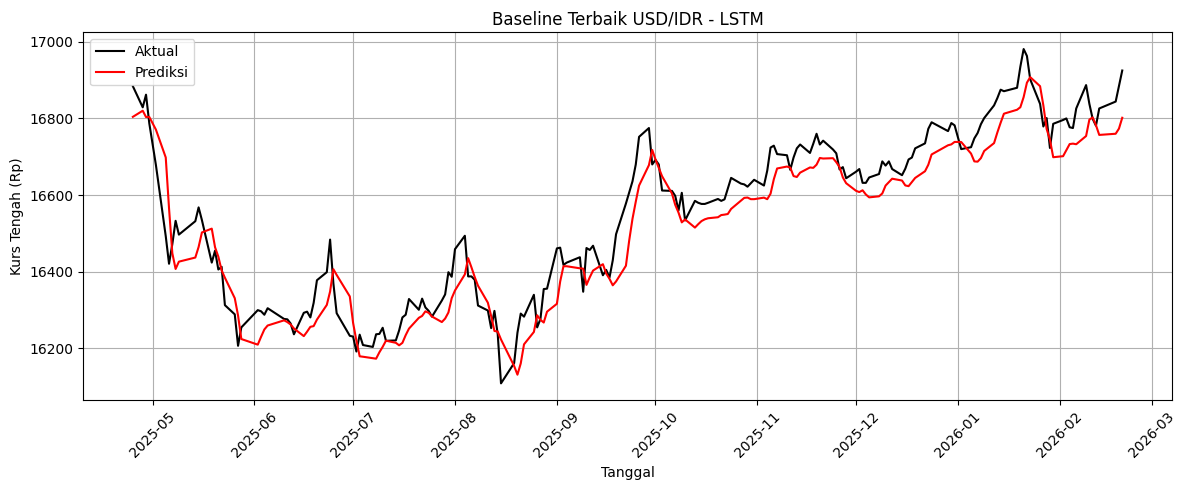

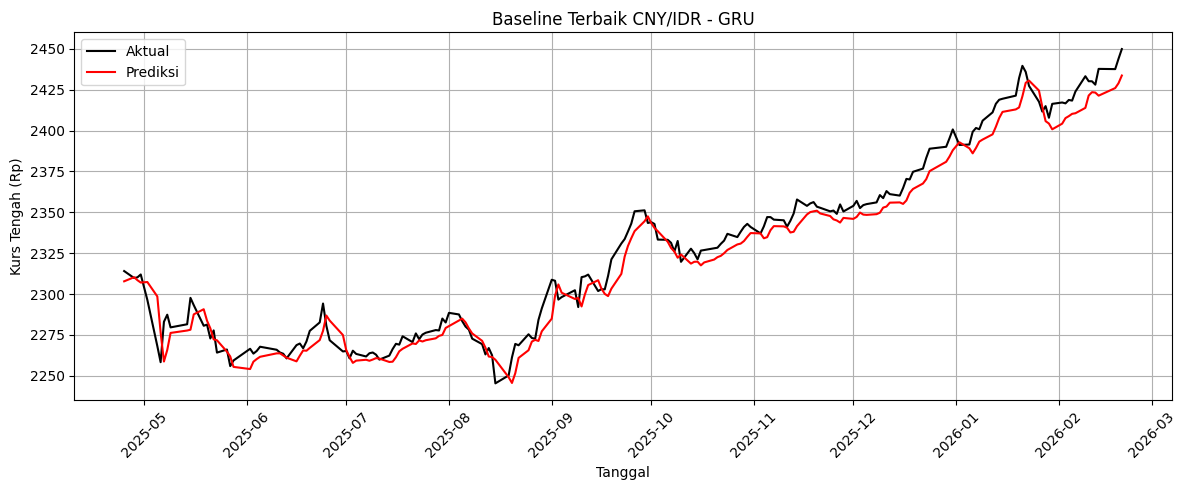

In [122]:
plot_pred_vs_actual(
    usd_test.index,
    y_true_usd,
    y_pred_usd,
    "Baseline Terbaik USD/IDR - LSTM",
    n_points=200
)

plot_pred_vs_actual(
    cny_test.index,
    y_true_cny2,
    y_pred_cny2,
    "Baseline Terbaik CNY/IDR - GRU",
    n_points=200
)

SUMMARY SKENARIO 1: membangun baseline model LSTM dan GRU dengan arsitektur sederhana, yaitu satu layer recurrent dan satu output neuron. Parameter awal dibuat setara agar perbandingan adil. Masing-masing model dilatih menggunakan data train, dipantau dengan validation loss menggunakan early stopping dan reduce learning rate, lalu dievaluasi pada data test dengan MAE, RMSE, dan MAPE. Selain itu, membandingkan nilai aktual dan prediksi secara langsung untuk melihat kedekatan model terhadap data riil.

## skenario 2

membersihkan session TensorFlow agar eksperimen baru berjalan dari kondisi yang bersih dan tidak terganggu oleh state model sebelumnya.

Pada model stacked, jumlah parameter lebih banyak dibanding baseline, sehingga risiko overfitting juga meningkat. Karena itu menambahkan dropout sebagai regularisasi.

Pada stacked LSTM  menambahkan satu layer LSTM lagi sehingga model menjadi lebih dalam. Layer pertama menggunakan return_sequences=True agar output sequence-nya dapat diproses kembali oleh layer LSTM kedua.Arsitektur stacked GRU buat setara dengan stacked LSTM agar perbandingan keduanya tetap objektif. Perbedaannya hanya pada jenis recurrent unit yang digunakan.

In [37]:
from tensorflow.keras.layers import Dropout

def build_stacked_lstm(input_shape, units=64, dropout_rate=0.1, learning_rate=1e-3):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(units, return_sequences=True),
        Dropout(dropout_rate),
        LSTM(units),
        Dense(1)
    ])
    opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=opt, loss="mse")
    return model


def build_stacked_gru(input_shape, units=64, dropout_rate=0.1, learning_rate=1e-3):
    model = Sequential([
        Input(shape=input_shape),
        GRU(units, return_sequences=True),
        Dropout(dropout_rate),
        GRU(units),
        Dense(1)
    ])
    opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=opt, loss="mse")
    return model

Epoch 1/800
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.0256 - val_loss: 0.0045 - learning_rate: 0.0010
Epoch 2/800
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0048 - val_loss: 0.0041 - learning_rate: 0.0010
Epoch 3/800
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0037 - val_loss: 0.0037 - learning_rate: 0.0010
Epoch 4/800
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0029 - val_loss: 0.0028 - learning_rate: 0.0010
Epoch 5/800
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0026 - val_loss: 0.0019 - learning_rate: 0.0010
Epoch 6/800
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0024 - val_loss: 0.0020 - learning_rate: 0.0010
Epoch 7/800
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0022 - val_loss: 0.0021 - learning_rate: 0.0010
Epoch 8/800
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0020 - val_loss: 0.0018 - learning_rate: 0.0010
Epoch 9/800
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0020 - val_loss: 0.0019 - learning_rate: 0.0010
Epoch 10/8

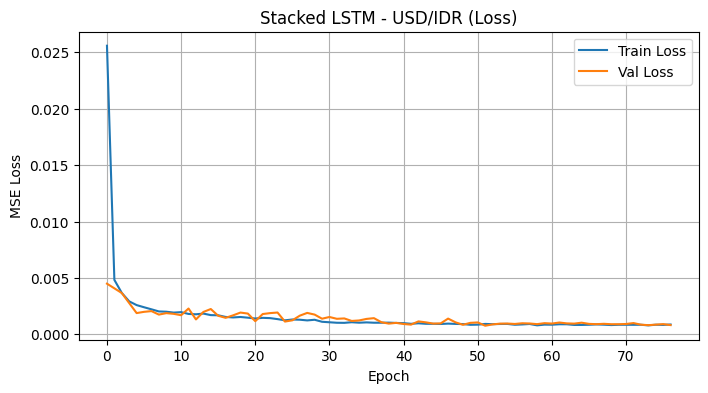

Epoch 1/800
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.0232 - val_loss: 0.0019 - learning_rate: 0.0010
Epoch 2/800
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0025 - val_loss: 0.0013 - learning_rate: 0.0010
Epoch 3/800
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0016 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 4/800
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0014 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 5/800
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0014 - val_loss: 0.0010 - learning_rate: 0.0010
Epoch 6/800
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0013 - val_loss: 0.0012 - learning_rate: 0.0010
Epoch 7/800
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0012 - val_loss: 0.0012 - learning_rate: 0.0010
Epoch 8/800
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0011 - val_loss: 9.3991e-04 - learning_rate: 0.0010
Epoch 9/800
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0012 - val_loss: 8.5833e-04 - learning_rate: 0.0010
Ep

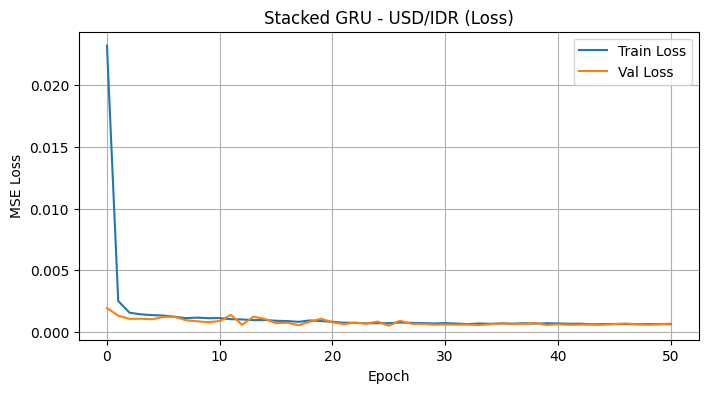

In [38]:
# usd
tf.keras.backend.clear_session()
set_seed(42)
stacked_lstm_usd = build_stacked_lstm(input_shape_usd)
hist_st_lstm_usd = train_until_converge(
    stacked_lstm_usd,
    X_train_usd, y_train_usd,
    X_val_usd, y_val_usd,
    max_epochs=800,
    batch_size=32,
    patience=25,
    min_delta=1e-5,
    verbose=1
)
res_st_lstm_usd, y_true_usd_st, y_pred_usd_st = predict_inverse_and_metrics(
    stacked_lstm_usd, X_test_usd, y_test_usd, usd_scaler
)
plot_loss(hist_st_lstm_usd, "Stacked LSTM - USD/IDR (Loss)")

tf.keras.backend.clear_session()
set_seed(42)
stacked_gru_usd = build_stacked_gru(input_shape_usd)
hist_st_gru_usd = train_until_converge(
    stacked_gru_usd,
    X_train_usd, y_train_usd,
    X_val_usd, y_val_usd,
    max_epochs=800,
    batch_size=32,
    patience=25,
    min_delta=1e-5,
    verbose=1
)
res_st_gru_usd, y_true_usd_st2, y_pred_usd_st2 = predict_inverse_and_metrics(
    stacked_gru_usd, X_test_usd, y_test_usd, usd_scaler
)
plot_loss(hist_st_gru_usd, "Stacked GRU - USD/IDR (Loss)")

Epoch 1/800
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 0.0405 - val_loss: 0.0025 - learning_rate: 0.0010
Epoch 2/800
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0059 - val_loss: 0.0029 - learning_rate: 0.0010
Epoch 3/800
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0048 - val_loss: 0.0032 - learning_rate: 0.0010
Epoch 4/800
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0041 - val_loss: 0.0035 - learning_rate: 0.0010
Epoch 5/800
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0035 - val_loss: 0.0020 - learning_rate: 0.0010
Epoch 6/800
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0030 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 7/800
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0027 - val_loss: 0.0024 - learning_rate: 0.0010
Epoch 8/800
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0026 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 9/800
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0025 - val_loss: 0.0023 - learning_rate: 0.0010
Epoch 10/8

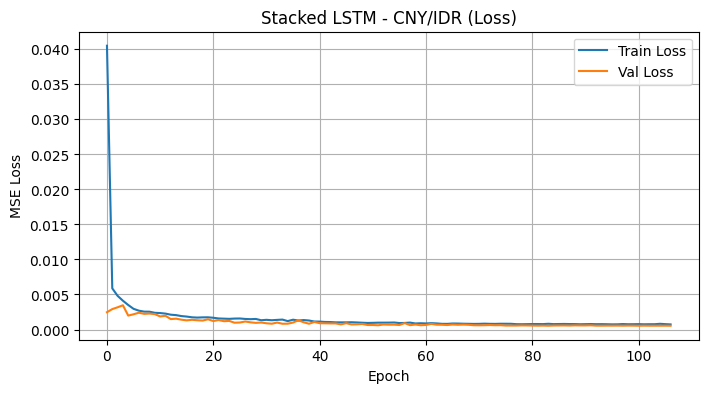

Epoch 1/800
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - loss: 0.0394 - val_loss: 0.0012 - learning_rate: 0.0010
Epoch 2/800
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0033 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 3/800
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0022 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 4/800
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0018 - val_loss: 9.5805e-04 - learning_rate: 0.0010
Epoch 5/800
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0017 - val_loss: 9.1951e-04 - learning_rate: 0.0010
Epoch 6/800
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0017 - val_loss: 9.5051e-04 - learning_rate: 0.0010
Epoch 7/800
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0016 - val_loss: 0.0010 - learning_rate: 0.0010
Epoch 8/800
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0015 - val_loss: 8.9289e-04 - learning_rate: 0.0010
Epoch 9/800
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0015 - val_loss: 8.7847e-04 - learning_rat

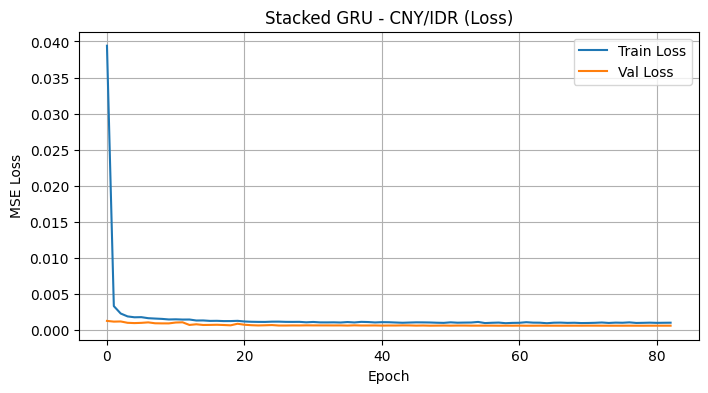

In [39]:
# cny
tf.keras.backend.clear_session()
set_seed(42)
stacked_lstm_cny = build_stacked_lstm(input_shape_cny)
hist_st_lstm_cny = train_until_converge(
    stacked_lstm_cny,
    X_train_cny, y_train_cny,
    X_val_cny, y_val_cny,
    max_epochs=800,
    batch_size=32,
    patience=25,
    min_delta=1e-5,
    verbose=1
)
res_st_lstm_cny, y_true_cny_st, y_pred_cny_st = predict_inverse_and_metrics(
    stacked_lstm_cny, X_test_cny, y_test_cny, cny_scaler
)
plot_loss(hist_st_lstm_cny, "Stacked LSTM - CNY/IDR (Loss)")

tf.keras.backend.clear_session()
set_seed(42)
stacked_gru_cny = build_stacked_gru(input_shape_cny)
hist_st_gru_cny = train_until_converge(
    stacked_gru_cny,
    X_train_cny, y_train_cny,
    X_val_cny, y_val_cny,
    max_epochs=800,
    batch_size=32,
    patience=25,
    min_delta=1e-5,
    verbose=1
)
res_st_gru_cny, y_true_cny_st2, y_pred_cny_st2 = predict_inverse_and_metrics(
    stacked_gru_cny, X_test_cny, y_test_cny, cny_scaler
)
plot_loss(hist_st_gru_cny, "Stacked GRU - CNY/IDR (Loss)")

In [130]:
summary_stacked_final = pd.DataFrame([
    {
        "Skenario": "Stacked",
        "Mata Uang": "USD/IDR",
        "Model": "LSTM",
        "Best Epoch": np.argmin(hist_st_lstm_usd.history["val_loss"]) + 1,
        "Epoch Berhenti": len(hist_st_lstm_usd.history["loss"]),
        "MAE": res_st_lstm_usd["MAE"],
        "RMSE": res_st_lstm_usd["RMSE"],
        "MAPE (%)": res_st_lstm_usd["MAPE(%)"]
    },
    {
        "Skenario": "Stacked",
        "Mata Uang": "USD/IDR",
        "Model": "GRU",
        "Best Epoch": np.argmin(hist_st_gru_usd.history["val_loss"]) + 1,
        "Epoch Berhenti": len(hist_st_gru_usd.history["loss"]),
        "MAE": res_st_gru_usd["MAE"],
        "RMSE": res_st_gru_usd["RMSE"],
        "MAPE (%)": res_st_gru_usd["MAPE(%)"]
    },
    {
        "Skenario": "Stacked",
        "Mata Uang": "CNY/IDR",
        "Model": "LSTM",
        "Best Epoch": np.argmin(hist_st_lstm_cny.history["val_loss"]) + 1,
        "Epoch Berhenti": len(hist_st_lstm_cny.history["loss"]),
        "MAE": res_st_lstm_cny["MAE"],
        "RMSE": res_st_lstm_cny["RMSE"],
        "MAPE (%)": res_st_lstm_cny["MAPE(%)"]
    },
    {
        "Skenario": "Stacked",
        "Mata Uang": "CNY/IDR",
        "Model": "GRU",
        "Best Epoch": np.argmin(hist_st_gru_cny.history["val_loss"]) + 1,
        "Epoch Berhenti": len(hist_st_gru_cny.history["loss"]),
        "MAE": res_st_gru_cny["MAE"],
        "RMSE": res_st_gru_cny["RMSE"],
        "MAPE (%)": res_st_gru_cny["MAPE(%)"]
    }
])

summary_stacked_final = summary_stacked_final.round({
    "MAE": 4,
    "RMSE": 4,
    "MAPE (%)": 4
})

summary_stacked_final

,Skenario,Mata Uang,Model,Best Epoch,Epoch Berhenti,MAE,RMSE,MAPE (%)
0,Stacked,USD/IDR,LSTM,52,77,94.9710,107.9531,0.5716
1,Stacked,USD/IDR,GRU,26,51,54.2805,67.0008,0.3272
2,Stacked,CNY/IDR,LSTM,107,107,11.4975,14.0053,0.4895
3,Stacked,CNY/IDR,GRU,79,83,8.4947,10.3327,0.3636


In [131]:
usd_lstm_st_table = pd.DataFrame({
    "Tanggal": usd_test_dates,
    "Aktual (Rp)": y_true_usd_st,
    "Prediksi (Rp)": y_pred_usd_st,
})

usd_lstm_st_table["Error (Rp)"] = usd_lstm_st_table["Aktual (Rp)"] - usd_lstm_st_table["Prediksi (Rp)"]
usd_lstm_st_table["APE (%)"] = (
    abs(usd_lstm_st_table["Error (Rp)"]) / usd_lstm_st_table["Aktual (Rp)"]
) * 100

In [132]:
usd_gru_st_table = pd.DataFrame({
    "Tanggal": usd_test_dates,
    "Aktual (Rp)": y_true_usd_st2,
    "Prediksi (Rp)": y_pred_usd_st2,
})

usd_gru_st_table["Error (Rp)"] = usd_gru_st_table["Aktual (Rp)"] - usd_gru_st_table["Prediksi (Rp)"]
usd_gru_st_table["APE (%)"] = (
    abs(usd_gru_st_table["Error (Rp)"]) / usd_gru_st_table["Aktual (Rp)"]
) * 100

In [133]:
cny_lstm_st_table = pd.DataFrame({
    "Tanggal": cny_test_dates,
    "Aktual (Rp)": y_true_cny_st,
    "Prediksi (Rp)": y_pred_cny_st,
})

cny_lstm_st_table["Error (Rp)"] = cny_lstm_st_table["Aktual (Rp)"] - cny_lstm_st_table["Prediksi (Rp)"]
cny_lstm_st_table["APE (%)"] = (
    abs(cny_lstm_st_table["Error (Rp)"]) / cny_lstm_st_table["Aktual (Rp)"]
) * 100

In [134]:
cny_gru_st_table = pd.DataFrame({
    "Tanggal": cny_test_dates,
    "Aktual (Rp)": y_true_cny_st2,
    "Prediksi (Rp)": y_pred_cny_st2,
})

cny_gru_st_table["Error (Rp)"] = cny_gru_st_table["Aktual (Rp)"] - cny_gru_st_table["Prediksi (Rp)"]
cny_gru_st_table["APE (%)"] = (
    abs(cny_gru_st_table["Error (Rp)"]) / cny_gru_st_table["Aktual (Rp)"]
) * 100

In [135]:
stacked_rank_usd = summary_stacked_final[
    summary_stacked_final["Mata Uang"] == "USD/IDR"
].sort_values(by=["MAPE (%)", "RMSE", "MAE"]).reset_index(drop=True)

stacked_rank_cny = summary_stacked_final[
    summary_stacked_final["Mata Uang"] == "CNY/IDR"
].sort_values(by=["MAPE (%)", "RMSE", "MAE"]).reset_index(drop=True)

print("Ranking Stacked USD/IDR")
display(stacked_rank_usd)

print("Ranking Stacked CNY/IDR")
display(stacked_rank_cny)

Ranking Stacked USD/IDR


,Skenario,Mata Uang,Model,Best Epoch,Epoch Berhenti,MAE,RMSE,MAPE (%)
0,Stacked,USD/IDR,GRU,26,51,54.2805,67.0008,0.3272
1,Stacked,USD/IDR,LSTM,52,77,94.9710,107.9531,0.5716


Ranking Stacked CNY/IDR


,Skenario,Mata Uang,Model,Best Epoch,Epoch Berhenti,MAE,RMSE,MAPE (%)
0,Stacked,CNY/IDR,GRU,79,83,8.4947,10.3327,0.3636
1,Stacked,CNY/IDR,LSTM,107,107,11.4975,14.0053,0.4895


In [136]:
usd_stacked_compare = pd.DataFrame({
    "Tanggal": usd_test.index,
    "Aktual (Rp)": np.array(y_true_usd_st).reshape(-1),
    "Prediksi Stacked LSTM (Rp)": np.array(y_pred_usd_st).reshape(-1),
    "Prediksi Stacked GRU (Rp)": np.array(y_pred_usd_st2).reshape(-1),
})

usd_stacked_compare["Error Stacked LSTM (Rp)"] = (
    usd_stacked_compare["Aktual (Rp)"] - usd_stacked_compare["Prediksi Stacked LSTM (Rp)"]
)

usd_stacked_compare["Error Stacked GRU (Rp)"] = (
    usd_stacked_compare["Aktual (Rp)"] - usd_stacked_compare["Prediksi Stacked GRU (Rp)"]
)

usd_stacked_compare["APE Stacked LSTM (%)"] = (
    np.abs(usd_stacked_compare["Error Stacked LSTM (Rp)"]) / usd_stacked_compare["Aktual (Rp)"]
) * 100

usd_stacked_compare["APE Stacked GRU (%)"] = (
    np.abs(usd_stacked_compare["Error Stacked GRU (Rp)"]) / usd_stacked_compare["Aktual (Rp)"]
) * 100

usd_stacked_compare["Model Lebih Dekat"] = np.where(
    np.abs(usd_stacked_compare["Error Stacked LSTM (Rp)"]) < np.abs(usd_stacked_compare["Error Stacked GRU (Rp)"]),
    "Stacked LSTM",
    np.where(
        np.abs(usd_stacked_compare["Error Stacked GRU (Rp)"]) < np.abs(usd_stacked_compare["Error Stacked LSTM (Rp)"]),
        "Stacked GRU",
        "Seri"
    )
)

numeric_cols = usd_stacked_compare.select_dtypes(include=["number"]).columns
usd_stacked_compare[numeric_cols] = usd_stacked_compare[numeric_cols].round(2)

usd_stacked_compare.head(20)

,Tanggal,Aktual (Rp),Prediksi Stacked LSTM (Rp),Prediksi Stacked GRU (Rp),Error Stacked LSTM (Rp),Error Stacked GRU (Rp),APE Stacked LSTM (%),APE Stacked GRU (%),Model Lebih Dekat
0,2025-03-11,16326.0,16244.740234,16287.700195,81.260002,38.299999,0.50,0.23,Stacked GRU
1,2025-03-12,16430.0,16241.120117,16292.059570,188.880005,137.940002,1.15,0.84,Stacked GRU
2,2025-03-13,16453.0,16299.799805,16376.750000,153.199997,76.250000,0.93,0.46,Stacked GRU
3,2025-03-14,16428.0,16359.919922,16426.400391,68.080002,1.600000,0.41,0.01,Stacked GRU
4,2025-03-17,16392.0,16379.809570,16412.900391,12.190000,-20.900000,0.07,0.13,Stacked LSTM
5,2025-03-18,16379.0,16360.660156,16371.780273,18.330000,7.220000,0.11,0.04,Stacked GRU
6,2025-03-19,16432.0,16332.549805,16347.530273,99.449997,84.470001,0.61,0.51,Stacked GRU
7,2025-03-20,16528.0,16340.410156,16385.919922,187.589996,142.080002,1.13,0.86,Stacked GRU
8,2025-03-21,16481.0,16400.250000,16479.759766,80.750000,1.240000,0.49,0.01,Stacked GRU
9,2025-03-24,16501.0,16420.199219,16470.330078,80.800003,30.670000,0.49,0.19,Stacked GRU


In [137]:
cny_stacked_compare = pd.DataFrame({
    "Tanggal": cny_test.index,
    "Aktual (Rp)": np.array(y_true_cny_st).reshape(-1),
    "Prediksi Stacked LSTM (Rp)": np.array(y_pred_cny_st).reshape(-1),
    "Prediksi Stacked GRU (Rp)": np.array(y_pred_cny_st2).reshape(-1),
})

cny_stacked_compare["Error Stacked LSTM (Rp)"] = (
    cny_stacked_compare["Aktual (Rp)"] - cny_stacked_compare["Prediksi Stacked LSTM (Rp)"]
)

cny_stacked_compare["Error Stacked GRU (Rp)"] = (
    cny_stacked_compare["Aktual (Rp)"] - cny_stacked_compare["Prediksi Stacked GRU (Rp)"]
)

cny_stacked_compare["APE Stacked LSTM (%)"] = (
    np.abs(cny_stacked_compare["Error Stacked LSTM (Rp)"]) / cny_stacked_compare["Aktual (Rp)"]
) * 100

cny_stacked_compare["APE Stacked GRU (%)"] = (
    np.abs(cny_stacked_compare["Error Stacked GRU (Rp)"]) / cny_stacked_compare["Aktual (Rp)"]
) * 100

cny_stacked_compare["Model Lebih Dekat"] = np.where(
    np.abs(cny_stacked_compare["Error Stacked LSTM (Rp)"]) < np.abs(cny_stacked_compare["Error Stacked GRU (Rp)"]),
    "Stacked LSTM",
    np.where(
        np.abs(cny_stacked_compare["Error Stacked GRU (Rp)"]) < np.abs(cny_stacked_compare["Error Stacked LSTM (Rp)"]),
        "Stacked GRU",
        "Seri"
    )
)

numeric_cols = cny_stacked_compare.select_dtypes(include=["number"]).columns
cny_stacked_compare[numeric_cols] = cny_stacked_compare[numeric_cols].round(2)

cny_stacked_compare.head(20)

,Tanggal,Aktual (Rp),Prediksi Stacked LSTM (Rp),Prediksi Stacked GRU (Rp),Error Stacked LSTM (Rp),Error Stacked GRU (Rp),APE Stacked LSTM (%),APE Stacked GRU (%),Model Lebih Dekat
0,2025-03-11,2247.570068,2249.879883,2251.540039,-2.310000,-3.970000,0.10,0.18,Stacked LSTM
1,2025-03-12,2272.679932,2246.820068,2247.810059,25.860001,24.870001,1.14,1.09,Stacked GRU
2,2025-03-13,2271.169922,2260.959961,2260.050049,10.210000,11.120000,0.45,0.49,Stacked LSTM
3,2025-03-14,2268.439941,2268.850098,2267.090088,-0.420000,1.340000,0.02,0.06,Stacked LSTM
4,2025-03-17,2266.300049,2268.570068,2267.659912,-2.270000,-1.360000,0.10,0.06,Stacked GRU
5,2025-03-18,2262.310059,2264.959961,2265.600098,-2.650000,-3.290000,0.12,0.15,Stacked LSTM
6,2025-03-19,2273.600098,2260.040039,2261.939941,13.560000,11.660000,0.60,0.51,Stacked GRU
7,2025-03-20,2283.840088,2265.110107,2266.610107,18.719999,17.219999,0.82,0.75,Stacked GRU
8,2025-03-21,2276.820068,2275.610107,2275.860107,1.220000,0.970000,0.05,0.04,Stacked GRU
9,2025-03-24,2276.790039,2275.919922,2276.310059,0.870000,0.470000,0.04,0.02,Stacked GRU


In [138]:
usd_stacked_closest_summary = usd_stacked_compare["Model Lebih Dekat"].value_counts().reset_index()
usd_stacked_closest_summary.columns = ["Model", "Jumlah Lebih Dekat"]

usd_total = len(usd_stacked_compare)
usd_stacked_closest_summary["Persentase (%)"] = (
    usd_stacked_closest_summary["Jumlah Lebih Dekat"] / usd_total * 100
).round(2)

usd_stacked_closest_summary

,Model,Jumlah Lebih Dekat,Persentase (%)
0,Stacked GRU,203,90.22
1,Stacked LSTM,22,9.78


In [139]:
cny_stacked_closest_summary = cny_stacked_compare["Model Lebih Dekat"].value_counts().reset_index()
cny_stacked_closest_summary.columns = ["Model", "Jumlah Lebih Dekat"]

cny_total = len(cny_stacked_compare)
cny_stacked_closest_summary["Persentase (%)"] = (
    cny_stacked_closest_summary["Jumlah Lebih Dekat"] / cny_total * 100
).round(2)

cny_stacked_closest_summary

,Model,Jumlah Lebih Dekat,Persentase (%)
0,Stacked GRU,178,79.11
1,Stacked LSTM,47,20.89


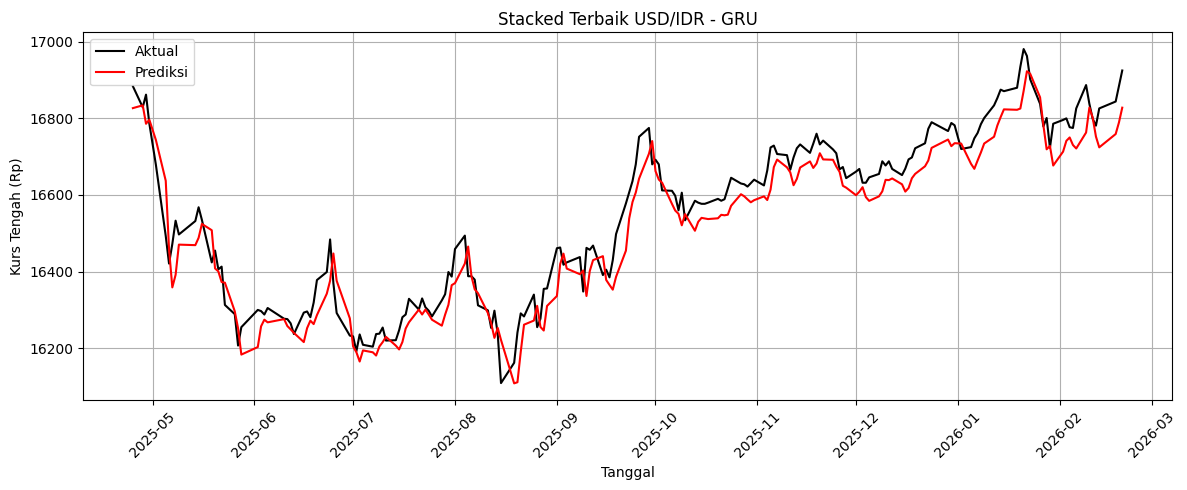

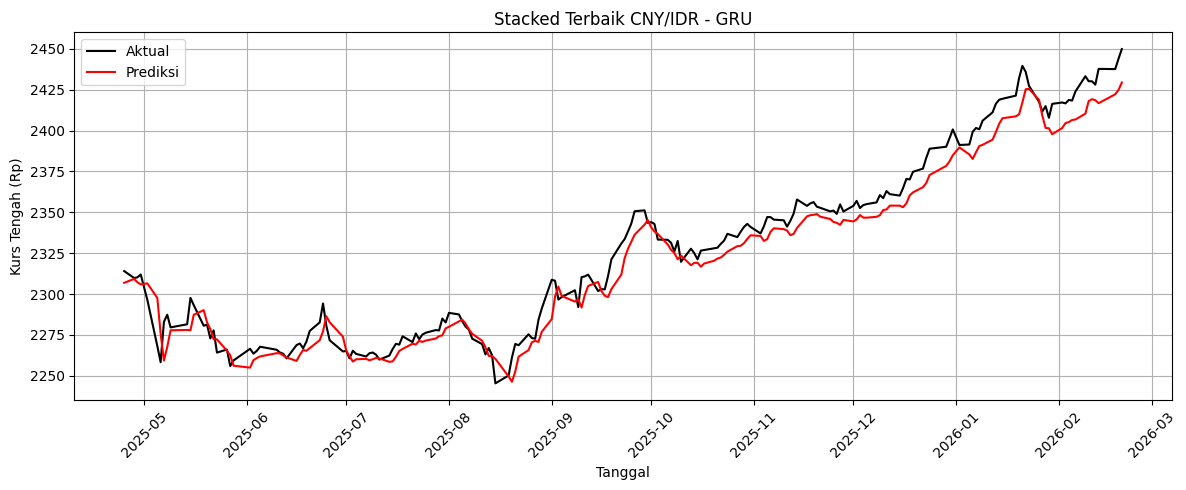

In [140]:
plot_pred_vs_actual(
    usd_test.index,
    y_true_usd_st2,
    y_pred_usd_st2,
    "Stacked Terbaik USD/IDR - GRU",
    n_points=200
)

plot_pred_vs_actual(
    cny_test.index,
    y_true_cny_st2,
    y_pred_cny_st2,
    "Stacked Terbaik CNY/IDR - GRU",
    n_points=200
)

summary skenario 2: arsitektur stacked, yaitu dua layer recurrent dengan tambahan dropout 0,1. Tujuannya adalah melihat apakah penambahan kompleksitas model dapat meningkatkan akurasi dibanding baseline.

### summary skenario 1 dan 2

In [142]:
usd_compare_full = pd.DataFrame({
    "Tanggal": usd_test.index,
    "Aktual (Rp)": np.array(y_true_usd).reshape(-1),
    "Prediksi Baseline LSTM (Rp)": np.array(y_pred_usd).reshape(-1),
    "Prediksi Baseline GRU (Rp)": np.array(y_pred_usd2).reshape(-1),
    "Prediksi Stacked LSTM (Rp)": np.array(y_pred_usd_st).reshape(-1),
    "Prediksi Stacked GRU (Rp)": np.array(y_pred_usd_st2).reshape(-1),
})

usd_compare_full["Error Baseline LSTM (Rp)"] = (
    usd_compare_full["Aktual (Rp)"] - usd_compare_full["Prediksi Baseline LSTM (Rp)"]
)
usd_compare_full["Error Baseline GRU (Rp)"] = (
    usd_compare_full["Aktual (Rp)"] - usd_compare_full["Prediksi Baseline GRU (Rp)"]
)
usd_compare_full["Error Stacked LSTM (Rp)"] = (
    usd_compare_full["Aktual (Rp)"] - usd_compare_full["Prediksi Stacked LSTM (Rp)"]
)
usd_compare_full["Error Stacked GRU (Rp)"] = (
    usd_compare_full["Aktual (Rp)"] - usd_compare_full["Prediksi Stacked GRU (Rp)"]
)

usd_compare_full["APE Baseline LSTM (%)"] = (
    np.abs(usd_compare_full["Error Baseline LSTM (Rp)"]) / usd_compare_full["Aktual (Rp)"]
) * 100
usd_compare_full["APE Baseline GRU (%)"] = (
    np.abs(usd_compare_full["Error Baseline GRU (Rp)"]) / usd_compare_full["Aktual (Rp)"]
) * 100
usd_compare_full["APE Stacked LSTM (%)"] = (
    np.abs(usd_compare_full["Error Stacked LSTM (Rp)"]) / usd_compare_full["Aktual (Rp)"]
) * 100
usd_compare_full["APE Stacked GRU (%)"] = (
    np.abs(usd_compare_full["Error Stacked GRU (Rp)"]) / usd_compare_full["Aktual (Rp)"]
) * 100

usd_compare_full["Model Paling Dekat"] = usd_compare_full[
    [
        "APE Baseline LSTM (%)",
        "APE Baseline GRU (%)",
        "APE Stacked LSTM (%)",
        "APE Stacked GRU (%)"
    ]
].idxmin(axis=1)

usd_compare_full["Model Paling Dekat"] = usd_compare_full["Model Paling Dekat"].replace({
    "APE Baseline LSTM (%)": "Baseline LSTM",
    "APE Baseline GRU (%)": "Baseline GRU",
    "APE Stacked LSTM (%)": "Stacked LSTM",
    "APE Stacked GRU (%)": "Stacked GRU"
})

numeric_cols = usd_compare_full.select_dtypes(include=["number"]).columns
usd_compare_full[numeric_cols] = usd_compare_full[numeric_cols].round(2)

usd_compare_full.head(20)

,Tanggal,Aktual (Rp),Prediksi Baseline LSTM (Rp),Prediksi Baseline GRU (Rp),Prediksi Stacked LSTM (Rp),Prediksi Stacked GRU (Rp),Error Baseline LSTM (Rp),Error Baseline GRU (Rp),Error Stacked LSTM (Rp),Error Stacked GRU (Rp),APE Baseline LSTM (%),APE Baseline GRU (%),APE Stacked LSTM (%),APE Stacked GRU (%),Model Paling Dekat
0,2025-03-11,16326.0,16307.290039,16277.200195,16244.740234,16287.700195,18.709999,48.799999,81.260002,38.299999,0.11,0.30,0.50,0.23,Baseline LSTM
1,2025-03-12,16430.0,16287.759766,16267.969727,16241.120117,16292.059570,142.240005,162.029999,188.880005,137.940002,0.87,0.99,1.15,0.84,Stacked GRU
2,2025-03-13,16453.0,16328.150391,16326.750000,16299.799805,16376.750000,124.849998,126.250000,153.199997,76.250000,0.76,0.77,0.93,0.46,Stacked GRU
3,2025-03-14,16428.0,16374.099609,16385.490234,16359.919922,16426.400391,53.900002,42.509998,68.080002,1.600000,0.33,0.26,0.41,0.01,Stacked GRU
4,2025-03-17,16392.0,16394.210938,16403.750000,16379.809570,16412.900391,-2.210000,-11.750000,12.190000,-20.900000,0.01,0.07,0.07,0.13,Baseline LSTM
5,2025-03-18,16379.0,16387.109375,16384.449219,16360.660156,16371.780273,-8.110000,-5.450000,18.330000,7.220000,0.05,0.03,0.11,0.04,Baseline GRU
6,2025-03-19,16432.0,16371.780273,16357.849609,16332.549805,16347.530273,60.230000,74.150002,99.449997,84.470001,0.37,0.45,0.61,0.51,Baseline LSTM
7,2025-03-20,16528.0,16383.400391,16369.929688,16340.410156,16385.919922,144.610001,158.070007,187.589996,142.080002,0.87,0.96,1.13,0.86,Stacked GRU
8,2025-03-21,16481.0,16436.160156,16435.599609,16400.250000,16479.759766,44.840000,45.400002,80.750000,1.240000,0.27,0.28,0.49,0.01,Stacked GRU
9,2025-03-24,16501.0,16452.160156,16455.089844,16420.199219,16470.330078,48.840000,45.910000,80.800003,30.670000,0.30,0.28,0.49,0.19,Stacked GRU


In [143]:
cny_compare_full = pd.DataFrame({
    "Tanggal": cny_test.index,
    "Aktual (Rp)": np.array(y_true_cny).reshape(-1),
    "Prediksi Baseline LSTM (Rp)": np.array(y_pred_cny).reshape(-1),
    "Prediksi Baseline GRU (Rp)": np.array(y_pred_cny2).reshape(-1),
    "Prediksi Stacked LSTM (Rp)": np.array(y_pred_cny_st).reshape(-1),
    "Prediksi Stacked GRU (Rp)": np.array(y_pred_cny_st2).reshape(-1),
})

cny_compare_full["Error Baseline LSTM (Rp)"] = (
    cny_compare_full["Aktual (Rp)"] - cny_compare_full["Prediksi Baseline LSTM (Rp)"]
)
cny_compare_full["Error Baseline GRU (Rp)"] = (
    cny_compare_full["Aktual (Rp)"] - cny_compare_full["Prediksi Baseline GRU (Rp)"]
)
cny_compare_full["Error Stacked LSTM (Rp)"] = (
    cny_compare_full["Aktual (Rp)"] - cny_compare_full["Prediksi Stacked LSTM (Rp)"]
)
cny_compare_full["Error Stacked GRU (Rp)"] = (
    cny_compare_full["Aktual (Rp)"] - cny_compare_full["Prediksi Stacked GRU (Rp)"]
)

cny_compare_full["APE Baseline LSTM (%)"] = (
    np.abs(cny_compare_full["Error Baseline LSTM (Rp)"]) / cny_compare_full["Aktual (Rp)"]
) * 100
cny_compare_full["APE Baseline GRU (%)"] = (
    np.abs(cny_compare_full["Error Baseline GRU (Rp)"]) / cny_compare_full["Aktual (Rp)"]
) * 100
cny_compare_full["APE Stacked LSTM (%)"] = (
    np.abs(cny_compare_full["Error Stacked LSTM (Rp)"]) / cny_compare_full["Aktual (Rp)"]
) * 100
cny_compare_full["APE Stacked GRU (%)"] = (
    np.abs(cny_compare_full["Error Stacked GRU (Rp)"]) / cny_compare_full["Aktual (Rp)"]
) * 100

cny_compare_full["Model Paling Dekat"] = cny_compare_full[
    [
        "APE Baseline LSTM (%)",
        "APE Baseline GRU (%)",
        "APE Stacked LSTM (%)",
        "APE Stacked GRU (%)"
    ]
].idxmin(axis=1)

cny_compare_full["Model Paling Dekat"] = cny_compare_full["Model Paling Dekat"].replace({
    "APE Baseline LSTM (%)": "Baseline LSTM",
    "APE Baseline GRU (%)": "Baseline GRU",
    "APE Stacked LSTM (%)": "Stacked LSTM",
    "APE Stacked GRU (%)": "Stacked GRU"
})

numeric_cols = cny_compare_full.select_dtypes(include=["number"]).columns
cny_compare_full[numeric_cols] = cny_compare_full[numeric_cols].round(2)

cny_compare_full.head(20)

,Tanggal,Aktual (Rp),Prediksi Baseline LSTM (Rp),Prediksi Baseline GRU (Rp),Prediksi Stacked LSTM (Rp),Prediksi Stacked GRU (Rp),Error Baseline LSTM (Rp),Error Baseline GRU (Rp),Error Stacked LSTM (Rp),Error Stacked GRU (Rp),APE Baseline LSTM (%),APE Baseline GRU (%),APE Stacked LSTM (%),APE Stacked GRU (%),Model Paling Dekat
0,2025-03-11,2247.570068,2257.429932,2251.030029,2249.879883,2251.540039,-9.860000,-3.460000,-2.310000,-3.970000,0.44,0.15,0.10,0.18,Stacked LSTM
1,2025-03-12,2272.679932,2254.169922,2247.310059,2246.820068,2247.810059,18.510000,25.370001,25.860001,24.870001,0.81,1.12,1.14,1.09,Baseline LSTM
2,2025-03-13,2271.169922,2255.340088,2259.479980,2260.959961,2260.050049,15.830000,11.690000,10.210000,11.120000,0.70,0.51,0.45,0.49,Stacked LSTM
3,2025-03-14,2268.439941,2257.209961,2267.050049,2268.850098,2267.090088,11.230000,1.390000,-0.420000,1.340000,0.49,0.06,0.02,0.06,Stacked LSTM
4,2025-03-17,2266.300049,2258.959961,2268.320068,2268.570068,2267.659912,7.340000,-2.020000,-2.270000,-1.360000,0.32,0.09,0.10,0.06,Stacked GRU
5,2025-03-18,2262.310059,2260.250000,2266.439941,2264.959961,2265.600098,2.060000,-4.130000,-2.650000,-3.290000,0.09,0.18,0.12,0.15,Baseline LSTM
6,2025-03-19,2273.600098,2260.520020,2262.500000,2260.040039,2261.939941,13.080000,11.100000,13.560000,11.660000,0.58,0.49,0.60,0.51,Baseline GRU
7,2025-03-20,2283.840088,2262.439941,2266.679932,2265.110107,2266.610107,21.389999,17.160000,18.719999,17.219999,0.94,0.75,0.82,0.75,Baseline GRU
8,2025-03-21,2276.820068,2266.310059,2275.800049,2275.610107,2275.860107,10.520000,1.030000,1.220000,0.970000,0.46,0.05,0.05,0.04,Stacked GRU
9,2025-03-24,2276.790039,2269.000000,2276.820068,2275.919922,2276.310059,7.780000,-0.030000,0.870000,0.470000,0.34,0.00,0.04,0.02,Baseline GRU


In [144]:
usd_closest_full_summary = usd_compare_full["Model Paling Dekat"].value_counts().reset_index()
usd_closest_full_summary.columns = ["Model", "Jumlah Menjadi Prediksi Terdekat"]

usd_total = len(usd_compare_full)
usd_closest_full_summary["Persentase (%)"] = (
    usd_closest_full_summary["Jumlah Menjadi Prediksi Terdekat"] / usd_total * 100
).round(2)

usd_closest_full_summary

,Model,Jumlah Menjadi Prediksi Terdekat,Persentase (%)
0,Stacked GRU,111,49.33
1,Baseline LSTM,81,36.00
2,Baseline GRU,17,7.56
3,Stacked LSTM,16,7.11


In [145]:
cny_closest_full_summary = cny_compare_full["Model Paling Dekat"].value_counts().reset_index()
cny_closest_full_summary.columns = ["Model", "Jumlah Menjadi Prediksi Terdekat"]

cny_total = len(cny_compare_full)
cny_closest_full_summary["Persentase (%)"] = (
    cny_closest_full_summary["Jumlah Menjadi Prediksi Terdekat"] / cny_total * 100
).round(2)

cny_closest_full_summary

,Model,Jumlah Menjadi Prediksi Terdekat,Persentase (%)
0,Baseline GRU,138,61.33
1,Stacked LSTM,36,16.00
2,Baseline LSTM,28,12.44
3,Stacked GRU,23,10.22


In [146]:
usd_compare_full_simple = usd_compare_full[
    [
        "Tanggal",
        "Aktual (Rp)",
        "Prediksi Baseline LSTM (Rp)",
        "Prediksi Baseline GRU (Rp)",
        "Prediksi Stacked LSTM (Rp)",
        "Prediksi Stacked GRU (Rp)",
        "Model Paling Dekat"
    ]
].copy()

usd_compare_full_simple.head(20)

,Tanggal,Aktual (Rp),Prediksi Baseline LSTM (Rp),Prediksi Baseline GRU (Rp),Prediksi Stacked LSTM (Rp),Prediksi Stacked GRU (Rp),Model Paling Dekat
0,2025-03-11,16326.0,16307.290039,16277.200195,16244.740234,16287.700195,Baseline LSTM
1,2025-03-12,16430.0,16287.759766,16267.969727,16241.120117,16292.059570,Stacked GRU
2,2025-03-13,16453.0,16328.150391,16326.750000,16299.799805,16376.750000,Stacked GRU
3,2025-03-14,16428.0,16374.099609,16385.490234,16359.919922,16426.400391,Stacked GRU
4,2025-03-17,16392.0,16394.210938,16403.750000,16379.809570,16412.900391,Baseline LSTM
5,2025-03-18,16379.0,16387.109375,16384.449219,16360.660156,16371.780273,Baseline GRU
6,2025-03-19,16432.0,16371.780273,16357.849609,16332.549805,16347.530273,Baseline LSTM
7,2025-03-20,16528.0,16383.400391,16369.929688,16340.410156,16385.919922,Stacked GRU
8,2025-03-21,16481.0,16436.160156,16435.599609,16400.250000,16479.759766,Stacked GRU
9,2025-03-24,16501.0,16452.160156,16455.089844,16420.199219,16470.330078,Stacked GRU


In [147]:
cny_compare_full_simple = cny_compare_full[
    [
        "Tanggal",
        "Aktual (Rp)",
        "Prediksi Baseline LSTM (Rp)",
        "Prediksi Baseline GRU (Rp)",
        "Prediksi Stacked LSTM (Rp)",
        "Prediksi Stacked GRU (Rp)",
        "Model Paling Dekat"
    ]
].copy()

cny_compare_full_simple.head(20)

,Tanggal,Aktual (Rp),Prediksi Baseline LSTM (Rp),Prediksi Baseline GRU (Rp),Prediksi Stacked LSTM (Rp),Prediksi Stacked GRU (Rp),Model Paling Dekat
0,2025-03-11,2247.570068,2257.429932,2251.030029,2249.879883,2251.540039,Stacked LSTM
1,2025-03-12,2272.679932,2254.169922,2247.310059,2246.820068,2247.810059,Baseline LSTM
2,2025-03-13,2271.169922,2255.340088,2259.479980,2260.959961,2260.050049,Stacked LSTM
3,2025-03-14,2268.439941,2257.209961,2267.050049,2268.850098,2267.090088,Stacked LSTM
4,2025-03-17,2266.300049,2258.959961,2268.320068,2268.570068,2267.659912,Stacked GRU
5,2025-03-18,2262.310059,2260.250000,2266.439941,2264.959961,2265.600098,Baseline LSTM
6,2025-03-19,2273.600098,2260.520020,2262.500000,2260.040039,2261.939941,Baseline GRU
7,2025-03-20,2283.840088,2262.439941,2266.679932,2265.110107,2266.610107,Baseline GRU
8,2025-03-21,2276.820068,2266.310059,2275.800049,2275.610107,2275.860107,Stacked GRU
9,2025-03-24,2276.790039,2269.000000,2276.820068,2275.919922,2276.310059,Baseline GRU


In [148]:
summary_s1_s2 = pd.DataFrame([
    {
        "Mata Uang": "USD/IDR",
        "Skenario": "Baseline",
        "Model": "LSTM",
        "Best Epoch": np.argmin(hist_lstm_usd.history["val_loss"]) + 1,
        "Epoch Berhenti": len(hist_lstm_usd.history["loss"]),
        "MAE": res_lstm_usd["MAE"],
        "RMSE": res_lstm_usd["RMSE"],
        "MAPE (%)": res_lstm_usd["MAPE(%)"]
    },
    {
        "Mata Uang": "USD/IDR",
        "Skenario": "Baseline",
        "Model": "GRU",
        "Best Epoch": np.argmin(hist_gru_usd.history["val_loss"]) + 1,
        "Epoch Berhenti": len(hist_gru_usd.history["loss"]),
        "MAE": res_gru_usd["MAE"],
        "RMSE": res_gru_usd["RMSE"],
        "MAPE (%)": res_gru_usd["MAPE(%)"]
    },
    {
        "Mata Uang": "USD/IDR",
        "Skenario": "Stacked",
        "Model": "LSTM",
        "Best Epoch": np.argmin(hist_st_lstm_usd.history["val_loss"]) + 1,
        "Epoch Berhenti": len(hist_st_lstm_usd.history["loss"]),
        "MAE": res_st_lstm_usd["MAE"],
        "RMSE": res_st_lstm_usd["RMSE"],
        "MAPE (%)": res_st_lstm_usd["MAPE(%)"]
    },
    {
        "Mata Uang": "USD/IDR",
        "Skenario": "Stacked",
        "Model": "GRU",
        "Best Epoch": np.argmin(hist_st_gru_usd.history["val_loss"]) + 1,
        "Epoch Berhenti": len(hist_st_gru_usd.history["loss"]),
        "MAE": res_st_gru_usd["MAE"],
        "RMSE": res_st_gru_usd["RMSE"],
        "MAPE (%)": res_st_gru_usd["MAPE(%)"]
    },
    {
        "Mata Uang": "CNY/IDR",
        "Skenario": "Baseline",
        "Model": "LSTM",
        "Best Epoch": np.argmin(hist_lstm_cny.history["val_loss"]) + 1,
        "Epoch Berhenti": len(hist_lstm_cny.history["loss"]),
        "MAE": res_lstm_cny["MAE"],
        "RMSE": res_lstm_cny["RMSE"],
        "MAPE (%)": res_lstm_cny["MAPE(%)"]
    },
    {
        "Mata Uang": "CNY/IDR",
        "Skenario": "Baseline",
        "Model": "GRU",
        "Best Epoch": np.argmin(hist_gru_cny.history["val_loss"]) + 1,
        "Epoch Berhenti": len(hist_gru_cny.history["loss"]),
        "MAE": res_gru_cny["MAE"],
        "RMSE": res_gru_cny["RMSE"],
        "MAPE (%)": res_gru_cny["MAPE(%)"]
    },
    {
        "Mata Uang": "CNY/IDR",
        "Skenario": "Stacked",
        "Model": "LSTM",
        "Best Epoch": np.argmin(hist_st_lstm_cny.history["val_loss"]) + 1,
        "Epoch Berhenti": len(hist_st_lstm_cny.history["loss"]),
        "MAE": res_st_lstm_cny["MAE"],
        "RMSE": res_st_lstm_cny["RMSE"],
        "MAPE (%)": res_st_lstm_cny["MAPE(%)"]
    },
    {
        "Mata Uang": "CNY/IDR",
        "Skenario": "Stacked",
        "Model": "GRU",
        "Best Epoch": np.argmin(hist_st_gru_cny.history["val_loss"]) + 1,
        "Epoch Berhenti": len(hist_st_gru_cny.history["loss"]),
        "MAE": res_st_gru_cny["MAE"],
        "RMSE": res_st_gru_cny["RMSE"],
        "MAPE (%)": res_st_gru_cny["MAPE(%)"]
    }
])

summary_s1_s2 = summary_s1_s2.round({
    "MAE": 4,
    "RMSE": 4,
    "MAPE (%)": 4
})

summary_s1_s2

,Mata Uang,Skenario,Model,Best Epoch,Epoch Berhenti,MAE,RMSE,MAPE (%)
0,USD/IDR,Baseline,LSTM,98,98,58.7403,73.2208,0.3541
1,USD/IDR,Baseline,GRU,56,56,62.8310,76.2527,0.3789
2,USD/IDR,Stacked,LSTM,52,77,94.9710,107.9531,0.5716
3,USD/IDR,Stacked,GRU,26,51,54.2805,67.0008,0.3272
4,CNY/IDR,Baseline,LSTM,85,85,12.2752,14.3812,0.5260
5,CNY/IDR,Baseline,GRU,59,59,7.6314,9.3654,0.3275
6,CNY/IDR,Stacked,LSTM,107,107,11.4975,14.0053,0.4895
7,CNY/IDR,Stacked,GRU,79,83,8.4947,10.3327,0.3636


In [149]:
summary_s1_s2_ranked = summary_s1_s2.sort_values(
    by=["Mata Uang", "RMSE", "MAE", "MAPE (%)"],
    ascending=[True, True, True, True]
).reset_index(drop=True)

summary_s1_s2_ranked

,Mata Uang,Skenario,Model,Best Epoch,Epoch Berhenti,MAE,RMSE,MAPE (%)
0,CNY/IDR,Baseline,GRU,59,59,7.6314,9.3654,0.3275
1,CNY/IDR,Stacked,GRU,79,83,8.4947,10.3327,0.3636
2,CNY/IDR,Stacked,LSTM,107,107,11.4975,14.0053,0.4895
3,CNY/IDR,Baseline,LSTM,85,85,12.2752,14.3812,0.5260
4,USD/IDR,Stacked,GRU,26,51,54.2805,67.0008,0.3272
5,USD/IDR,Baseline,LSTM,98,98,58.7403,73.2208,0.3541
6,USD/IDR,Baseline,GRU,56,56,62.8310,76.2527,0.3789
7,USD/IDR,Stacked,LSTM,52,77,94.9710,107.9531,0.5716


In [150]:
summary_s1_s2_usd = summary_s1_s2[
    summary_s1_s2["Mata Uang"] == "USD/IDR"
].sort_values(
    by=["RMSE", "MAE", "MAPE (%)"],
    ascending=[True, True, True]
).reset_index(drop=True)

summary_s1_s2_usd

,Mata Uang,Skenario,Model,Best Epoch,Epoch Berhenti,MAE,RMSE,MAPE (%)
0,USD/IDR,Stacked,GRU,26,51,54.2805,67.0008,0.3272
1,USD/IDR,Baseline,LSTM,98,98,58.7403,73.2208,0.3541
2,USD/IDR,Baseline,GRU,56,56,62.8310,76.2527,0.3789
3,USD/IDR,Stacked,LSTM,52,77,94.9710,107.9531,0.5716


In [151]:
summary_s1_s2_cny = summary_s1_s2[
    summary_s1_s2["Mata Uang"] == "CNY/IDR"
].sort_values(
    by=["RMSE", "MAE", "MAPE (%)"],
    ascending=[True, True, True]
).reset_index(drop=True)

summary_s1_s2_cny

,Mata Uang,Skenario,Model,Best Epoch,Epoch Berhenti,MAE,RMSE,MAPE (%)
0,CNY/IDR,Baseline,GRU,59,59,7.6314,9.3654,0.3275
1,CNY/IDR,Stacked,GRU,79,83,8.4947,10.3327,0.3636
2,CNY/IDR,Stacked,LSTM,107,107,11.4975,14.0053,0.4895
3,CNY/IDR,Baseline,LSTM,85,85,12.2752,14.3812,0.5260


In [152]:
pivot_usd_s1_s2 = summary_s1_s2[
    summary_s1_s2["Mata Uang"] == "USD/IDR"
].pivot_table(
    index=["Skenario", "Model"],
    values=["Best Epoch", "Epoch Berhenti", "MAE", "RMSE", "MAPE (%)"],
    aggfunc="first"
)

pivot_usd_s1_s2

Best Epoch  Epoch Berhenti      MAE  MAPE (%)      RMSE
Skenario Model                                                         
Baseline GRU            56              56  62.8310    0.3789   76.2527
         LSTM           98              98  58.7403    0.3541   73.2208
Stacked  GRU            26              51  54.2805    0.3272   67.0008
         LSTM           52              77  94.9710    0.5716  107.9531

In [153]:
pivot_cny_s1_s2 = summary_s1_s2[
    summary_s1_s2["Mata Uang"] == "CNY/IDR"
].pivot_table(
    index=["Skenario", "Model"],
    values=["Best Epoch", "Epoch Berhenti", "MAE", "RMSE", "MAPE (%)"],
    aggfunc="first"
)

pivot_cny_s1_s2

Best Epoch  Epoch Berhenti      MAE  MAPE (%)     RMSE
Skenario Model                                                        
Baseline GRU            59              59   7.6314    0.3275   9.3654
         LSTM           85              85  12.2752    0.5260  14.3812
Stacked  GRU            79              83   8.4947    0.3636  10.3327
         LSTM          107             107  11.4975    0.4895  14.0053

In [154]:
summary_s1_s2_best = summary_s1_s2.copy()

summary_s1_s2_best["Peringkat"] = (
    summary_s1_s2_best
    .groupby("Mata Uang")["RMSE"]
    .rank(method="dense", ascending=True)
)

summary_s1_s2_best["Keterangan"] = summary_s1_s2_best["Peringkat"].apply(
    lambda x: "Terbaik" if x == 1 else ""
)

summary_s1_s2_best = summary_s1_s2_best.sort_values(
    by=["Mata Uang", "Peringkat", "RMSE", "MAE", "MAPE (%)"]
).reset_index(drop=True)

summary_s1_s2_best

,Mata Uang,Skenario,Model,Best Epoch,Epoch Berhenti,MAE,RMSE,MAPE (%),Peringkat,Keterangan
0,CNY/IDR,Baseline,GRU,59,59,7.6314,9.3654,0.3275,1.0,Terbaik
1,CNY/IDR,Stacked,GRU,79,83,8.4947,10.3327,0.3636,2.0,
2,CNY/IDR,Stacked,LSTM,107,107,11.4975,14.0053,0.4895,3.0,
3,CNY/IDR,Baseline,LSTM,85,85,12.2752,14.3812,0.5260,4.0,
4,USD/IDR,Stacked,GRU,26,51,54.2805,67.0008,0.3272,1.0,Terbaik
5,USD/IDR,Baseline,LSTM,98,98,58.7403,73.2208,0.3541,2.0,
6,USD/IDR,Baseline,GRU,56,56,62.8310,76.2527,0.3789,3.0,
7,USD/IDR,Stacked,LSTM,52,77,94.9710,107.9531,0.5716,4.0,


Jika skenario 1 dan skenario 2 digabungkan, maka pada USD/IDR model terbaik adalah Stacked GRU, karena memiliki nilai error paling kecil dibanding model baseline maupun stacked lainnya.

Sementara pada CNY/IDR, model terbaik tetap Baseline GRU, sehingga penambahan layer pada skenario stacked tidak memberikan peningkatan performa pada data CNY.

Dengan demikian, hasil gabungan dua skenario menunjukkan bahwa model terbaik berbeda pada masing-masing mata uang: USD lebih cocok dengan Stacked GRU, sedangkan CNY lebih cocok dengan Baseline GRU.

## skenario 3

In [57]:
import os
import random
import itertools
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [58]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

callback

In [59]:
def get_callbacks(model_path, patience=20, min_delta=1e-5):
    early_stop = EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=patience,
        min_delta=min_delta,
        restore_best_weights=True
    )

    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=max(5, patience // 3),
        min_lr=1e-6,
        verbose=0
    )

    checkpoint = ModelCheckpoint(
        filepath=model_path,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        save_weights_only=False,
        verbose=0
    )

    return [early_stop, reduce_lr, checkpoint]

build model lstm tuning

In [60]:
def build_lstm_tuning(input_shape, units=64, dropout_rate=0.0, learning_rate=1e-3):
    layers = [
        Input(shape=input_shape),
        LSTM(units),
    ]

    if dropout_rate > 0:
        layers.append(Dropout(dropout_rate))

    layers.append(Dense(1))

    model = Sequential(layers)

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss="mse")

    return model

build model gru tuning

In [61]:
def build_gru_tuning(input_shape, units=64, dropout_rate=0.0, learning_rate=1e-3):
    layers = [
        Input(shape=input_shape),
        GRU(units),
    ]

    if dropout_rate > 0:
        layers.append(Dropout(dropout_rate))

    layers.append(Dense(1))

    model = Sequential(layers)

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss="mse")

    return model

fungsi sequence dataset

In [62]:
def create_sequences_t1(series_2d, window_size):
    X, y = [], []

    for i in range(window_size, len(series_2d)):
        X.append(series_2d[i - window_size:i])
        y.append(series_2d[i])

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)

    return X, y

In [63]:
def make_dataset_by_window(train_scaled, val_scaled, test_scaled, window_size):
    X_train, y_train = create_sequences_t1(train_scaled, window_size)

    val_input = np.vstack([train_scaled[-window_size:], val_scaled])
    X_val, y_val = create_sequences_t1(val_input, window_size)

    test_input = np.vstack([val_input[-window_size:], test_scaled])
    X_test, y_test = create_sequences_t1(test_input, window_size)

    return X_train, y_train, X_val, y_val, X_test, y_test

fungsi training

In [64]:
def train_model(
    model,
    X_train, y_train,
    X_val, y_val,
    model_path,
    max_epochs=500,
    batch_size=32,
    patience=20,
    min_delta=1e-5,
    verbose=0
):
    callbacks = get_callbacks(
        model_path=model_path,
        patience=patience,
        min_delta=min_delta
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=max_epochs,
        batch_size=batch_size,
        verbose=verbose,
        callbacks=callbacks
    )

    return history

fungsi metrik

In [65]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mape(y_true, y_pred, eps=1e-8):
    y_true = np.array(y_true).reshape(-1)
    y_pred = np.array(y_pred).reshape(-1)

    denom = np.maximum(np.abs(y_true), eps)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100

def evaluate_regression(y_true, y_pred):
    y_true = np.array(y_true).reshape(-1)
    y_pred = np.array(y_pred).reshape(-1)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_val = mape(y_true, y_pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape_val
    }

def predict_inverse_and_metrics(model, X_data, y_data, scaler):
    y_pred_scaled = model.predict(X_data, verbose=0)

    y_true_inv = scaler.inverse_transform(np.array(y_data).reshape(-1, 1))
    y_pred_inv = scaler.inverse_transform(np.array(y_pred_scaled).reshape(-1, 1))

    metrics = evaluate_regression(y_true_inv, y_pred_inv)

    return metrics, y_true_inv.reshape(-1), y_pred_inv.reshape(-1)

inti model

In [66]:
def run_tuning_experiment(
    train_scaled,
    val_scaled,
    test_scaled,
    scaler,
    model_builder,
    param_grid,
    save_dir,
    experiment_name="model",
    max_epochs=500,
    patience=20,
    min_delta=1e-5,
    seed=42
):
    os.makedirs(save_dir, exist_ok=True)

    results = []
    experiment = 1

    for window_size, units, dropout, lr, batch_size in itertools.product(
        param_grid["window_size"],
        param_grid["units"],
        param_grid["dropout"],
        param_grid["learning_rate"],
        param_grid["batch_size"]
    ):
        print(
            f"[{experiment_name}] Eksperimen {experiment} | "
            f"window={window_size}, units={units}, dropout={dropout}, "
            f"lr={lr}, batch={batch_size}"
        )

        tf.keras.backend.clear_session()
        set_seed(seed)

        X_train, y_train, X_val, y_val, X_test, y_test = make_dataset_by_window(
            train_scaled, val_scaled, test_scaled, window_size
        )

        input_shape = (X_train.shape[1], X_train.shape[2])

        model = model_builder(
            input_shape=input_shape,
            units=units,
            dropout_rate=dropout,
            learning_rate=lr
        )

        model_path = os.path.join(save_dir, f"{experiment_name}_exp_{experiment}.keras")

        history = train_model(
            model=model,
            X_train=X_train,
            y_train=y_train,
            X_val=X_val,
            y_val=y_val,
            model_path=model_path,
            max_epochs=max_epochs,
            batch_size=batch_size,
            patience=patience,
            min_delta=min_delta,
            verbose=0
        )

        best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
        epoch_stop = int(len(history.history["loss"]))
        best_val_loss = float(np.min(history.history["val_loss"]))

        results.append({
            "Eksperimen": experiment,
            "Window Size": window_size,
            "Units": units,
            "Dropout": dropout,
            "Learning Rate": lr,
            "Batch Size": batch_size,
            "Best Epoch": best_epoch,
            "Epoch Berhenti": epoch_stop,
            "Best Val Loss": best_val_loss,
            "Model Path": model_path
        })

        experiment += 1

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(
        by=["Best Val Loss", "Best Epoch", "Epoch Berhenti"],
        ascending=[True, True, True]
    ).reset_index(drop=True)

    return results_df

final model test

In [67]:
def evaluate_best_model_on_test(
    results_df,
    train_scaled,
    val_scaled,
    test_scaled,
    scaler
):
    best_row = results_df.iloc[0]

    best_window = int(best_row["Window Size"])
    best_model_path = best_row["Model Path"]

    X_train, y_train, X_val, y_val, X_test, y_test = make_dataset_by_window(
        train_scaled, val_scaled, test_scaled, best_window
    )

    best_model = tf.keras.models.load_model(best_model_path)

    test_metrics, y_true_test, y_pred_test = predict_inverse_and_metrics(
        best_model,
        X_test,
        y_test,
        scaler
    )

    return best_row, test_metrics, y_true_test, y_pred_test

usd lstm

In [68]:
param_grid = {
    "window_size": [14, 30, 60],
    "units": [32, 64, 128],
    "dropout": [0.0, 0.1, 0.2],
    "learning_rate": [0.001, 0.0005],
    "batch_size": [16, 32]
}

usd_lstm_tuning_results = run_tuning_experiment(
    train_scaled=usd_train_scaled,
    val_scaled=usd_val_scaled,
    test_scaled=usd_test_scaled,
    scaler=usd_scaler,
    model_builder=build_lstm_tuning,
    param_grid=param_grid,
    save_dir="saved_models/usd_lstm",
    experiment_name="usd_lstm",
    max_epochs=500,
    patience=20,
    min_delta=1e-5,
    seed=42
)

best_usd_lstm_row, best_usd_lstm_test_metrics, y_true_usd_lstm_tune, y_pred_usd_lstm_tune = evaluate_best_model_on_test(
    results_df=usd_lstm_tuning_results,
    train_scaled=usd_train_scaled,
    val_scaled=usd_val_scaled,
    test_scaled=usd_test_scaled,
    scaler=usd_scaler
)

usd_lstm_tuning_results

[usd_lstm] Eksperimen 1 | window=14, units=32, dropout=0.0, lr=0.001, batch=16
[usd_lstm] Eksperimen 2 | window=14, units=32, dropout=0.0, lr=0.001, batch=32
[usd_lstm] Eksperimen 3 | window=14, units=32, dropout=0.0, lr=0.0005, batch=16
[usd_lstm] Eksperimen 4 | window=14, units=32, dropout=0.0, lr=0.0005, batch=32
[usd_lstm] Eksperimen 5 | window=14, units=32, dropout=0.1, lr=0.001, batch=16
[usd_lstm] Eksperimen 6 | window=14, units=32, dropout=0.1, lr=0.001, batch=32
[usd_lstm] Eksperimen 7 | window=14, units=32, dropout=0.1, lr=0.0005, batch=16
[usd_lstm] Eksperimen 8 | window=14, units=32, dropout=0.1, lr=0.0005, batch=32
[usd_lstm] Eksperimen 9 | window=14, units=32, dropout=0.2, lr=0.001, batch=16
[usd_lstm] Eksperimen 10 | window=14, units=32, dropout=0.2, lr=0.001, batch=32
[usd_lstm] Eksperimen 11 | window=14, units=32, dropout=0.2, lr=0.0005, batch=16
[usd_lstm] Eksperimen 12 | window=14, units=32, dropout=0.2, lr=0.0005, batch=32
[usd_lstm] Eksperimen 13 | window=14, units

,Eksperimen,Window Size,Units,Dropout,Learning Rate,Batch Size,Best Epoch,Epoch Berhenti,Best Val Loss,Model Path
0,97,60,128,0.0,0.0010,16,66,80,0.000490,saved_models/usd_lstm\usd_lstm_exp_97.keras
1,49,30,64,0.0,0.0010,16,89,93,0.000503,saved_models/usd_lstm\usd_lstm_exp_49.keras
2,29,14,128,0.1,0.0010,16,42,62,0.000531,saved_models/usd_lstm\usd_lstm_exp_29.keras
3,69,30,128,0.2,0.0010,16,31,51,0.000573,saved_models/usd_lstm\usd_lstm_exp_69.keras
4,33,14,128,0.2,0.0010,16,35,55,0.000590,saved_models/usd_lstm\usd_lstm_exp_33.keras
...,...,...,...,...,...,...,...,...,...,...
103,8,14,32,0.1,0.0005,32,23,43,0.001712,saved_models/usd_lstm\usd_lstm_exp_8.keras
104,12,14,32,0.2,0.0005,32,33,53,0.001792,saved_models/usd_lstm\usd_lstm_exp_12.keras
105,80,60,32,0.1,0.0005,32,27,47,0.001983,saved_models/usd_lstm\usd_lstm_exp_80.keras
106,48,30,32,0.2,0.0005,32,33,53,0.002349,saved_models/usd_lstm\usd_lstm_exp_48.keras


In [69]:
best_usd_lstm_row

Eksperimen                                                 97
Window Size                                                60
Units                                                     128
Dropout                                                   0.0
Learning Rate                                           0.001
Batch Size                                                 16
Best Epoch                                                 66
Epoch Berhenti                                             80
Best Val Loss                                         0.00049
Model Path        saved_models/usd_lstm\usd_lstm_exp_97.keras
Name: 0, dtype: object

In [70]:
best_usd_lstm_test_metrics

{'MAE': 43.339111328125,
 'RMSE': np.float64(56.66662765202395),
 'MAPE (%)': np.float32(0.26143897)}

Pada data USD/IDR, performa terbaik model LSTM diperoleh pada kombinasi window size 60, jumlah unit 128, tanpa dropout, learning rate 0.001, dan batch size 16. Hasil ini menunjukkan bahwa prediksi USD/IDR lebih terbantu oleh konteks historis yang lebih panjang, kapasitas model yang lebih besar, serta proses pembelajaran yang relatif agresif tanpa regularisasi dropout tambahan.

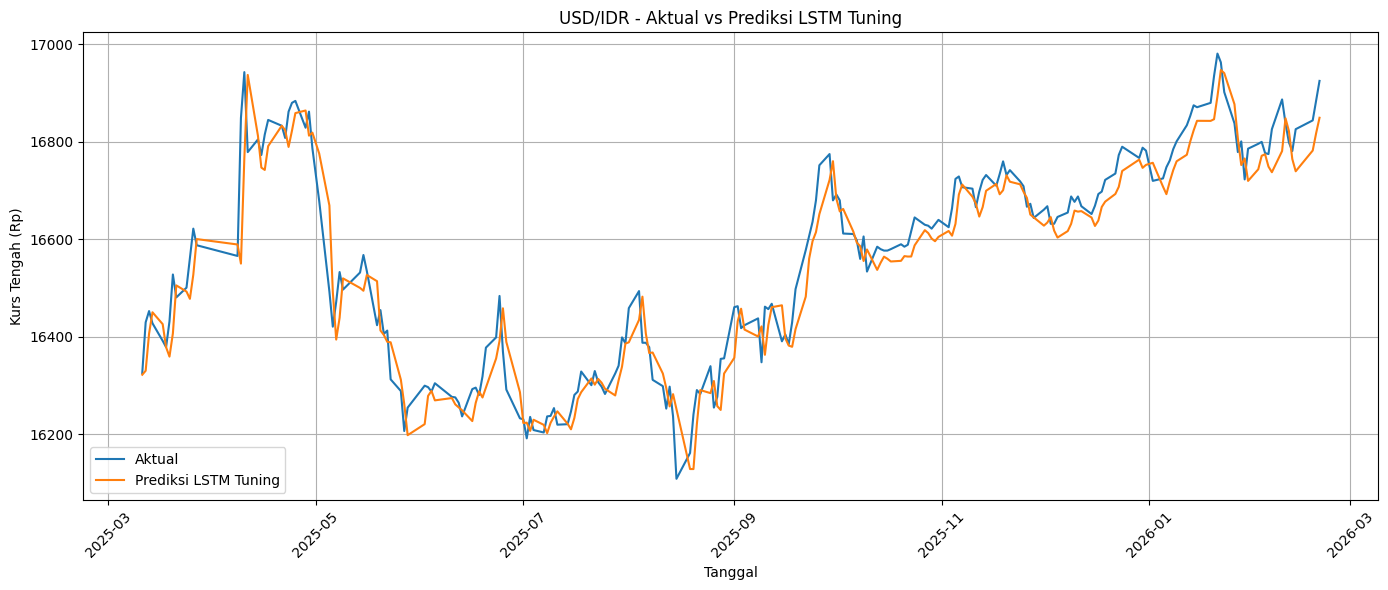

In [71]:
usd_lstm_tune_dates = usd_test.index[-len(y_true_usd_lstm_tune):]

plt.figure(figsize=(14, 6))
plt.plot(usd_lstm_tune_dates, y_true_usd_lstm_tune, label="Aktual")
plt.plot(usd_lstm_tune_dates, y_pred_usd_lstm_tune, label="Prediksi LSTM Tuning")
plt.title("USD/IDR - Aktual vs Prediksi LSTM Tuning")
plt.xlabel("Tanggal")
plt.ylabel("Kurs Tengah (Rp)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Model LSTM hasil tuning mampu mengikuti pola pergerakan kurs USD/IDR dengan cukup baik. Garis prediksi berada sangat dekat dengan garis aktual pada sebagian besar periode pengujian. Hal ini menunjukkan bahwa model berhasil menangkap tren naik dan turun nilai tukar secara relatif akurat.

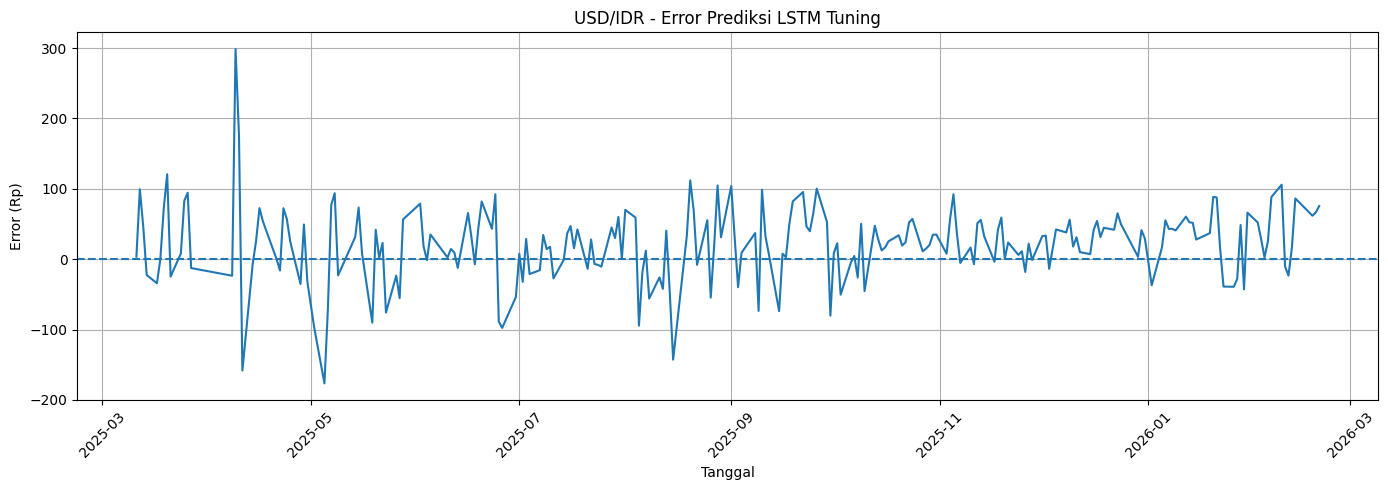

In [72]:
error_usd_lstm_tune = y_true_usd_lstm_tune - y_pred_usd_lstm_tune

plt.figure(figsize=(14, 5))
plt.plot(usd_lstm_tune_dates, error_usd_lstm_tune)
plt.axhline(0, linestyle="--")
plt.title("USD/IDR - Error Prediksi LSTM Tuning")
plt.xlabel("Tanggal")
plt.ylabel("Error (Rp)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Nilai error sebagian besar berada di sekitar 0 hingga ±100 rupiah, yang menunjukkan bahwa selisih antara prediksi dan nilai aktual relatif kecil. Walaupun terdapat beberapa lonjakan error, kejadian tersebut hanya muncul pada beberapa titik tertentu dan tidak terjadi secara konsisten.

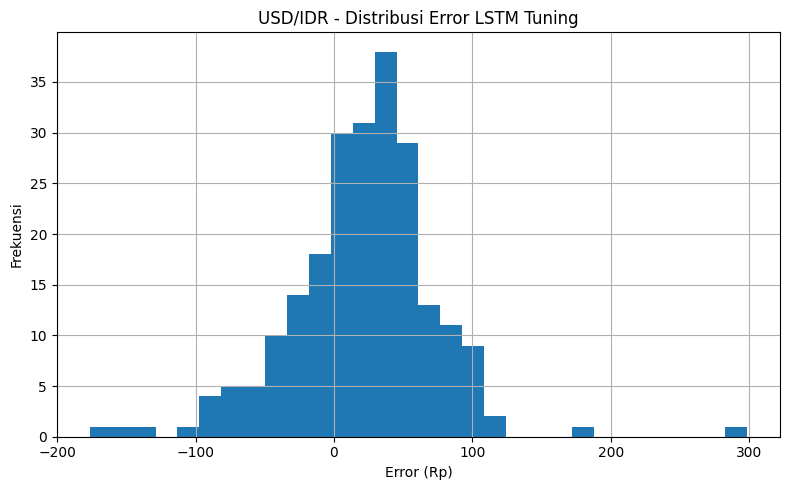

In [73]:
plt.figure(figsize=(8, 5))
plt.hist(error_usd_lstm_tune, bins=30)
plt.title("USD/IDR - Distribusi Error LSTM Tuning")
plt.xlabel("Error (Rp)")
plt.ylabel("Frekuensi")
plt.grid(True)
plt.tight_layout()
plt.show()

Distribusi error terkonsentrasi di sekitar nilai nol, yang berarti sebagian besar prediksi memiliki kesalahan yang kecil terhadap data aktual. Hal ini menunjukkan bahwa model memiliki stabilitas yang cukup baik dalam melakukan prediksi.

In [74]:
usd_lstm_tune_table = pd.DataFrame({
    "Tanggal": usd_lstm_tune_dates,
    "Aktual (Rp)": np.array(y_true_usd_lstm_tune).reshape(-1),
    "Prediksi LSTM Tuning (Rp)": np.array(y_pred_usd_lstm_tune).reshape(-1)
})

usd_lstm_tune_table["Error (Rp)"] = (
    usd_lstm_tune_table["Aktual (Rp)"] - usd_lstm_tune_table["Prediksi LSTM Tuning (Rp)"]
)

usd_lstm_tune_table["APE (%)"] = (
    np.abs(usd_lstm_tune_table["Error (Rp)"]) / usd_lstm_tune_table["Aktual (Rp)"]
) * 100

numeric_cols = usd_lstm_tune_table.select_dtypes(include=["number"]).columns
usd_lstm_tune_table[numeric_cols] = usd_lstm_tune_table[numeric_cols].round(2)

usd_lstm_tune_table.head(30)

,Tanggal,Aktual (Rp),Prediksi LSTM Tuning (Rp),Error (Rp),APE (%)
0,2025-03-11,16326.0,16322.419922,3.580000,0.02
1,2025-03-12,16430.0,16330.639648,99.360001,0.60
2,2025-03-13,16453.0,16406.689453,46.310001,0.28
3,2025-03-14,16428.0,16450.519531,-22.520000,0.14
4,2025-03-17,16392.0,16426.199219,-34.209999,0.21
5,2025-03-18,16379.0,16378.879883,0.120000,0.00
6,2025-03-19,16432.0,16359.589844,72.410004,0.44
7,2025-03-20,16528.0,16407.279297,120.709999,0.73
8,2025-03-21,16481.0,16505.669922,-24.670000,0.15
9,2025-03-24,16501.0,16493.009766,7.990000,0.05


In [75]:
usd_lstm_tune_error_table = usd_lstm_tune_table.copy()
usd_lstm_tune_error_table["Abs Error (Rp)"] = np.abs(usd_lstm_tune_error_table["Error (Rp)"])

top10_error_terbesar_usd_lstm = usd_lstm_tune_error_table.sort_values(
    by="Abs Error (Rp)",
    ascending=False
).reset_index(drop=True)

top10_error_terbesar_usd_lstm.head(10)

,Tanggal,Aktual (Rp),Prediksi LSTM Tuning (Rp),Error (Rp),APE (%),Abs Error (Rp)
0,2025-04-09,16849.000000,16550.349609,298.649994,1.77,298.649994
1,2025-05-05,16493.000000,16669.509766,-176.509995,1.07,176.509995
2,2025-04-10,16943.000000,16766.529297,176.470001,1.04,176.470001
3,2025-04-11,16779.000000,16937.250000,-158.250000,0.94,158.250000
4,2025-08-15,16109.000000,16251.820312,-142.820007,0.89,142.820007
5,2025-03-20,16528.000000,16407.279297,120.709999,0.73,120.709999
6,2025-08-20,16241.000000,16128.990234,112.010002,0.69,112.010002
7,2026-02-09,16887.000000,16781.140625,105.860001,0.63,105.860001
8,2025-08-28,16355.009766,16250.240234,104.760002,0.64,104.760002
9,2025-09-01,16461.000000,16357.080078,103.919998,0.63,103.919998


Kesalahan terbesar terjadi pada 9 April 2025 dengan selisih sekitar 298 rupiah. Kesalahan besar seperti ini biasanya terjadi ketika terjadi perubahan kurs yang cukup tajam, sehingga model membutuhkan waktu untuk menyesuaikan pola perubahan tersebut

In [76]:
print("Rata-rata Error:", np.mean(error_usd_lstm_tune).round(4))
print("Rata-rata Absolute Error:", np.mean(np.abs(error_usd_lstm_tune)).round(4))
print("Error Maksimum:", np.max(np.abs(error_usd_lstm_tune)).round(4))
print("Error Minimum:", np.min(error_usd_lstm_tune).round(4))
print("Error Maksimum Positif:", np.max(error_usd_lstm_tune).round(4))

Rata-rata Error: 20.8541
Rata-rata Absolute Error: 43.3391
Error Maksimum: 298.6504
Error Minimum: -176.5059
Error Maksimum Positif: 298.6504


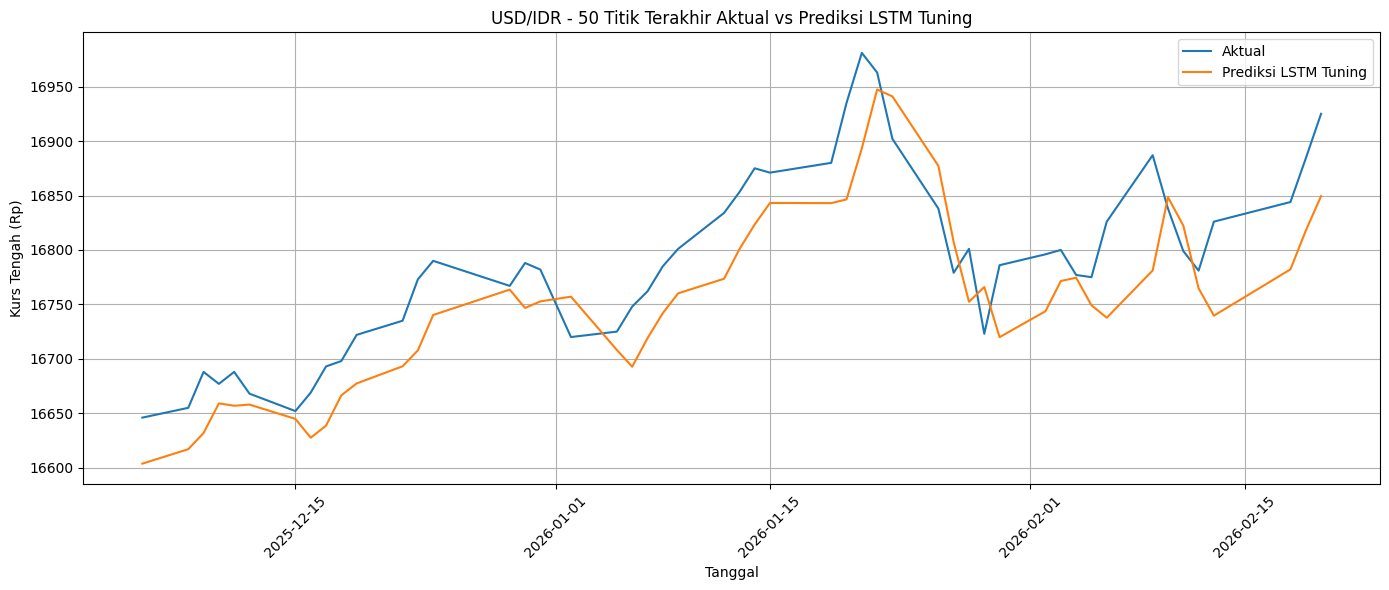

In [77]:
plot_df_usd_lstm = usd_lstm_tune_table.tail(50)

plt.figure(figsize=(14, 6))
plt.plot(plot_df_usd_lstm["Tanggal"], plot_df_usd_lstm["Aktual (Rp)"], label="Aktual")
plt.plot(plot_df_usd_lstm["Tanggal"], plot_df_usd_lstm["Prediksi LSTM Tuning (Rp)"], label="Prediksi LSTM Tuning")
plt.title("USD/IDR - 50 Titik Terakhir Aktual vs Prediksi LSTM Tuning")
plt.xlabel("Tanggal")
plt.ylabel("Kurs Tengah (Rp)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

usd gru

In [78]:
usd_gru_tuning_results = run_tuning_experiment(
    train_scaled=usd_train_scaled,
    val_scaled=usd_val_scaled,
    test_scaled=usd_test_scaled,
    scaler=usd_scaler,
    model_builder=build_gru_tuning,
    param_grid=param_grid,
    save_dir="saved_models/usd_gru",
    experiment_name="usd_gru",
    max_epochs=500,
    patience=20,
    min_delta=1e-5,
    seed=42
)

best_usd_gru_row, best_usd_gru_test_metrics, y_true_usd_gru_tune, y_pred_usd_gru_tune = evaluate_best_model_on_test(
    results_df=usd_gru_tuning_results,
    train_scaled=usd_train_scaled,
    val_scaled=usd_val_scaled,
    test_scaled=usd_test_scaled,
    scaler=usd_scaler
)

usd_gru_tuning_results

[usd_gru] Eksperimen 1 | window=14, units=32, dropout=0.0, lr=0.001, batch=16
[usd_gru] Eksperimen 2 | window=14, units=32, dropout=0.0, lr=0.001, batch=32
[usd_gru] Eksperimen 3 | window=14, units=32, dropout=0.0, lr=0.0005, batch=16
[usd_gru] Eksperimen 4 | window=14, units=32, dropout=0.0, lr=0.0005, batch=32
[usd_gru] Eksperimen 5 | window=14, units=32, dropout=0.1, lr=0.001, batch=16
[usd_gru] Eksperimen 6 | window=14, units=32, dropout=0.1, lr=0.001, batch=32
[usd_gru] Eksperimen 7 | window=14, units=32, dropout=0.1, lr=0.0005, batch=16
[usd_gru] Eksperimen 8 | window=14, units=32, dropout=0.1, lr=0.0005, batch=32
[usd_gru] Eksperimen 9 | window=14, units=32, dropout=0.2, lr=0.001, batch=16
[usd_gru] Eksperimen 10 | window=14, units=32, dropout=0.2, lr=0.001, batch=32
[usd_gru] Eksperimen 11 | window=14, units=32, dropout=0.2, lr=0.0005, batch=16
[usd_gru] Eksperimen 12 | window=14, units=32, dropout=0.2, lr=0.0005, batch=32
[usd_gru] Eksperimen 13 | window=14, units=64, dropout=

,Eksperimen,Window Size,Units,Dropout,Learning Rate,Batch Size,Best Epoch,Epoch Berhenti,Best Val Loss,Model Path
0,25,14,128,0.0,0.0010,16,40,46,0.000439,saved_models/usd_gru\usd_gru_exp_25.keras
1,33,14,128,0.2,0.0010,16,32,44,0.000460,saved_models/usd_gru\usd_gru_exp_33.keras
2,29,14,128,0.1,0.0010,16,35,44,0.000473,saved_models/usd_gru\usd_gru_exp_29.keras
3,17,14,64,0.1,0.0010,16,24,38,0.000479,saved_models/usd_gru\usd_gru_exp_17.keras
4,21,14,64,0.2,0.0010,16,20,40,0.000487,saved_models/usd_gru\usd_gru_exp_21.keras
...,...,...,...,...,...,...,...,...,...,...
103,83,60,32,0.2,0.0005,16,36,56,0.000836,saved_models/usd_gru\usd_gru_exp_83.keras
104,48,30,32,0.2,0.0005,32,34,54,0.000853,saved_models/usd_gru\usd_gru_exp_48.keras
105,12,14,32,0.2,0.0005,32,40,60,0.000870,saved_models/usd_gru\usd_gru_exp_12.keras
106,80,60,32,0.1,0.0005,32,46,66,0.000875,saved_models/usd_gru\usd_gru_exp_80.keras


In [79]:
best_usd_gru_row

Eksperimen                                               25
Window Size                                              14
Units                                                   128
Dropout                                                 0.0
Learning Rate                                         0.001
Batch Size                                               16
Best Epoch                                               40
Epoch Berhenti                                           46
Best Val Loss                                      0.000439
Model Path        saved_models/usd_gru\usd_gru_exp_25.keras
Name: 0, dtype: object

In [80]:
best_usd_gru_test_metrics

{'MAE': 40.566375732421875,
 'RMSE': np.float64(53.643394463169926),
 'MAPE (%)': np.float32(0.24497628)}

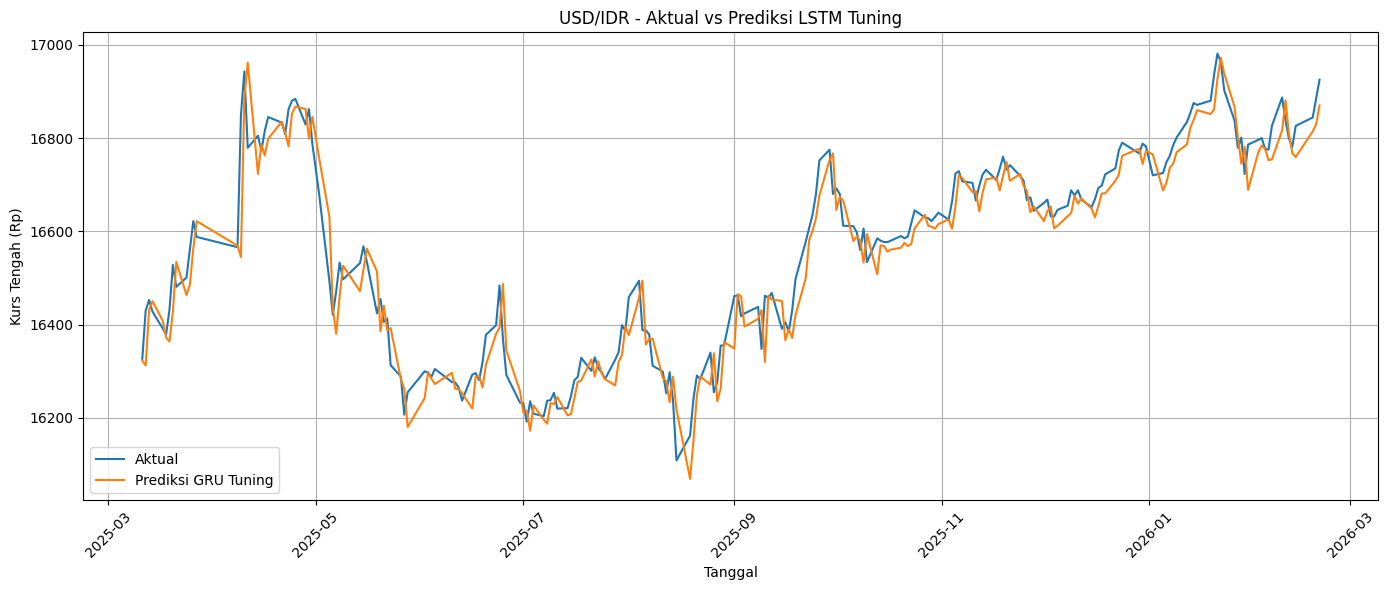

In [81]:
usd_gru_tune_dates = usd_test.index[-len(y_true_usd_gru_tune):]

plt.figure(figsize=(14, 6))
plt.plot(usd_gru_tune_dates, y_true_usd_gru_tune, label="Aktual")
plt.plot(usd_gru_tune_dates, y_pred_usd_gru_tune, label="Prediksi GRU Tuning")
plt.title("USD/IDR - Aktual vs Prediksi LSTM Tuning")
plt.xlabel("Tanggal")
plt.ylabel("Kurs Tengah (Rp)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

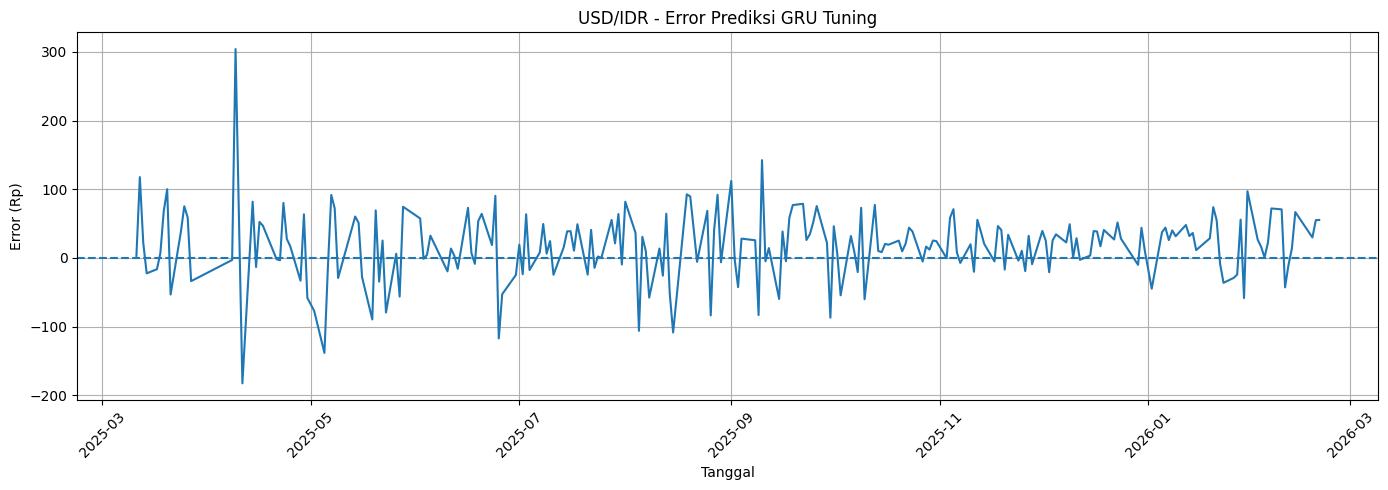

In [82]:
error_usd_gru_tune = y_true_usd_gru_tune - y_pred_usd_gru_tune

plt.figure(figsize=(14, 5))
plt.plot(usd_lstm_tune_dates, error_usd_gru_tune)
plt.axhline(0, linestyle="--")
plt.title("USD/IDR - Error Prediksi GRU Tuning")
plt.xlabel("Tanggal")
plt.ylabel("Error (Rp)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

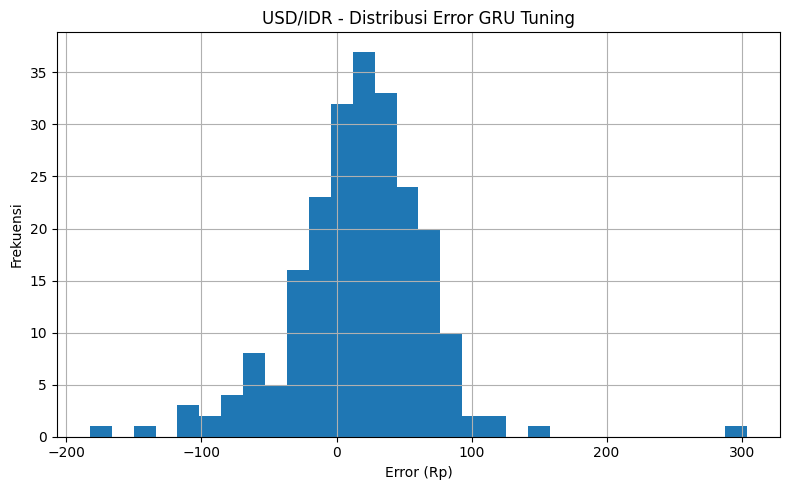

In [83]:
plt.figure(figsize=(8, 5))
plt.hist(error_usd_gru_tune, bins=30)
plt.title("USD/IDR - Distribusi Error GRU Tuning")
plt.xlabel("Error (Rp)")
plt.ylabel("Frekuensi")
plt.grid(True)
plt.tight_layout()
plt.show()

In [84]:
usd_gru_tune_table = pd.DataFrame({
    "Tanggal": usd_gru_tune_dates,
    "Aktual (Rp)": np.array(y_true_usd_gru_tune).reshape(-1),
    "Prediksi GRU Tuning (Rp)": np.array(y_pred_usd_gru_tune).reshape(-1)
})

usd_gru_tune_table["Error (Rp)"] = (
    usd_gru_tune_table["Aktual (Rp)"] - usd_gru_tune_table["Prediksi GRU Tuning (Rp)"]
)

usd_gru_tune_table["APE (%)"] = (
    np.abs(usd_gru_tune_table["Error (Rp)"]) / usd_gru_tune_table["Aktual (Rp)"]
) * 100

numeric_cols = usd_gru_tune_table.select_dtypes(include=["number"]).columns
usd_gru_tune_table[numeric_cols] = usd_gru_tune_table[numeric_cols].round(2)

usd_gru_tune_table.head(30)

,Tanggal,Aktual (Rp),Prediksi GRU Tuning (Rp),Error (Rp),APE (%)
0,2025-03-11,16326.0,16323.089844,2.910000,0.02
1,2025-03-12,16430.0,16312.379883,117.620003,0.72
2,2025-03-13,16453.0,16431.109375,21.889999,0.13
3,2025-03-14,16428.0,16450.519531,-22.520000,0.14
4,2025-03-17,16392.0,16408.519531,-16.520000,0.10
5,2025-03-18,16379.0,16372.320312,6.680000,0.04
6,2025-03-19,16432.0,16363.860352,68.139999,0.41
7,2025-03-20,16528.0,16428.039062,99.959999,0.60
8,2025-03-21,16481.0,16534.359375,-53.360001,0.32
9,2025-03-24,16501.0,16463.140625,37.860001,0.23


In [85]:
usd_gru_tune_error_table = usd_gru_tune_table.copy()
usd_gru_tune_error_table["Abs Error (Rp)"] = np.abs(usd_gru_tune_error_table["Error (Rp)"])

top10_error_terbesar_usd_gru = usd_gru_tune_error_table.sort_values(
    by="Abs Error (Rp)",
    ascending=False
).reset_index(drop=True)

top10_error_terbesar_usd_gru.head(10)

,Tanggal,Aktual (Rp),Prediksi GRU Tuning (Rp),Error (Rp),APE (%),Abs Error (Rp)
0,2025-04-09,16849.0,16544.910156,304.089996,1.80,304.089996
1,2025-04-11,16779.0,16961.720703,-182.720001,1.09,182.720001
2,2025-09-10,16462.0,16319.700195,142.300003,0.86,142.300003
3,2025-05-05,16493.0,16631.380859,-138.380005,0.84,138.380005
4,2025-03-12,16430.0,16312.379883,117.620003,0.72,117.620003
5,2025-06-25,16370.0,16487.240234,-117.239998,0.72,117.239998
6,2025-09-01,16461.0,16348.919922,112.080002,0.68,112.080002
7,2025-08-15,16109.0,16217.669922,-108.669998,0.67,108.669998
8,2025-08-05,16388.0,16494.310547,-106.309998,0.65,106.309998
9,2025-03-20,16528.0,16428.039062,99.959999,0.60,99.959999


In [86]:
print("Rata-rata Error:", np.mean(error_usd_gru_tune).round(4))
print("Rata-rata Absolute Error:", np.mean(np.abs(error_usd_gru_tune)).round(4))
print("Error Maksimum:", np.max(np.abs(error_usd_gru_tune)).round(4))
print("Error Minimum:", np.min(error_usd_gru_tune).round(4))
print("Error Maksimum Positif:", np.max(error_usd_gru_tune).round(4))

Rata-rata Error: 17.7376
Rata-rata Absolute Error: 40.5664
Error Maksimum: 304.0918
Error Minimum: -182.7168
Error Maksimum Positif: 304.0918


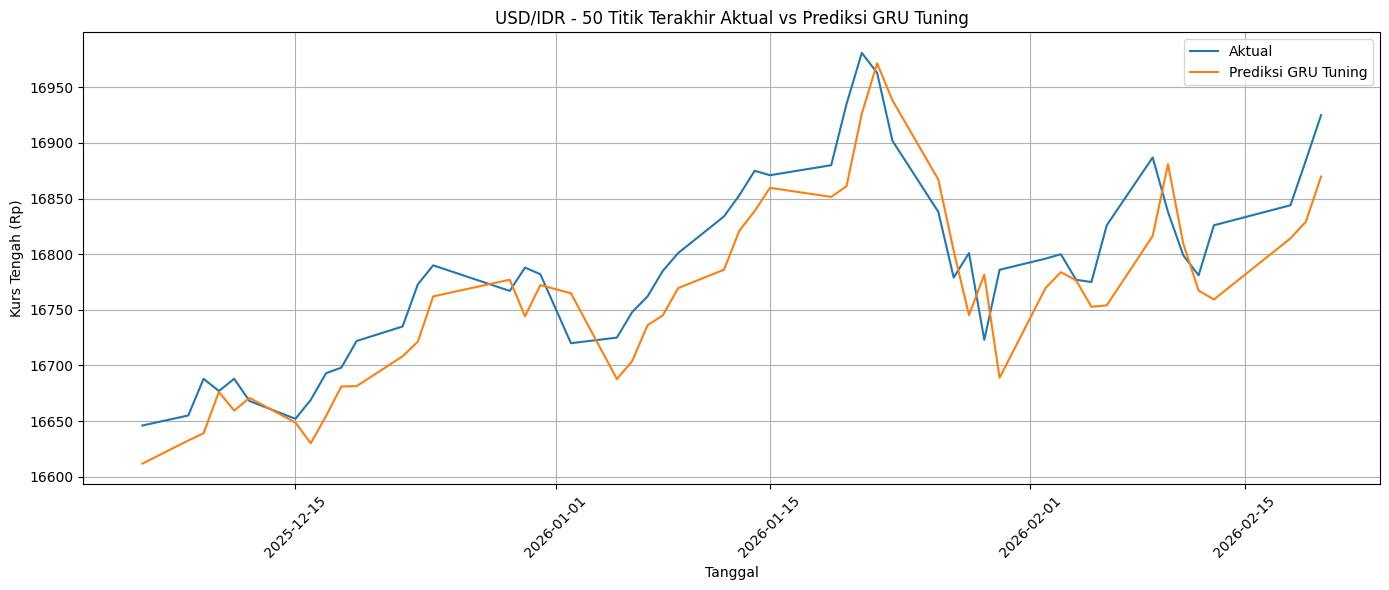

In [87]:
plot_df_usd_gru = usd_gru_tune_table.tail(50)

plt.figure(figsize=(14, 6))
plt.plot(plot_df_usd_gru["Tanggal"], plot_df_usd_gru["Aktual (Rp)"], label="Aktual")
plt.plot(plot_df_usd_gru["Tanggal"], plot_df_usd_gru["Prediksi GRU Tuning (Rp)"], label="Prediksi GRU Tuning")
plt.title("USD/IDR - 50 Titik Terakhir Aktual vs Prediksi GRU Tuning")
plt.xlabel("Tanggal")
plt.ylabel("Kurs Tengah (Rp)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

cny lstm

In [89]:
cny_lstm_tuning_results = run_tuning_experiment(
    train_scaled=cny_train_scaled,
    val_scaled=cny_val_scaled,
    test_scaled=cny_test_scaled,
    scaler=cny_scaler,
    model_builder=build_lstm_tuning,
    param_grid=param_grid,
    save_dir="saved_models/cny_lstm",
    experiment_name="cny_lstm",
    max_epochs=500,
    patience=20,
    min_delta=1e-5,
    seed=42
)

best_cny_lstm_row, best_cny_lstm_test_metrics, y_true_cny_lstm_tune, y_pred_cny_lstm_tune = evaluate_best_model_on_test(
    results_df=cny_lstm_tuning_results,
    train_scaled=cny_train_scaled,
    val_scaled=cny_val_scaled,
    test_scaled=cny_test_scaled,
    scaler=cny_scaler
)

cny_lstm_tuning_results

[cny_lstm] Eksperimen 1 | window=14, units=32, dropout=0.0, lr=0.001, batch=16
[cny_lstm] Eksperimen 2 | window=14, units=32, dropout=0.0, lr=0.001, batch=32
[cny_lstm] Eksperimen 3 | window=14, units=32, dropout=0.0, lr=0.0005, batch=16
[cny_lstm] Eksperimen 4 | window=14, units=32, dropout=0.0, lr=0.0005, batch=32
[cny_lstm] Eksperimen 5 | window=14, units=32, dropout=0.1, lr=0.001, batch=16
[cny_lstm] Eksperimen 6 | window=14, units=32, dropout=0.1, lr=0.001, batch=32
[cny_lstm] Eksperimen 7 | window=14, units=32, dropout=0.1, lr=0.0005, batch=16
[cny_lstm] Eksperimen 8 | window=14, units=32, dropout=0.1, lr=0.0005, batch=32
[cny_lstm] Eksperimen 9 | window=14, units=32, dropout=0.2, lr=0.001, batch=16
[cny_lstm] Eksperimen 10 | window=14, units=32, dropout=0.2, lr=0.001, batch=32
[cny_lstm] Eksperimen 11 | window=14, units=32, dropout=0.2, lr=0.0005, batch=16
[cny_lstm] Eksperimen 12 | window=14, units=32, dropout=0.2, lr=0.0005, batch=32
[cny_lstm] Eksperimen 13 | window=14, units

,Eksperimen,Window Size,Units,Dropout,Learning Rate,Batch Size,Best Epoch,Epoch Berhenti,Best Val Loss,Model Path
0,1,14,32,0.0,0.0010,16,64,73,0.000526,saved_models/cny_lstm\cny_lstm_exp_1.keras
1,49,30,64,0.0,0.0010,16,95,95,0.000527,saved_models/cny_lstm\cny_lstm_exp_49.keras
2,13,14,64,0.0,0.0010,16,67,76,0.000531,saved_models/cny_lstm\cny_lstm_exp_13.keras
3,25,14,128,0.0,0.0010,16,63,72,0.000535,saved_models/cny_lstm\cny_lstm_exp_25.keras
4,97,60,128,0.0,0.0010,16,62,62,0.000549,saved_models/cny_lstm\cny_lstm_exp_97.keras
...,...,...,...,...,...,...,...,...,...,...
103,47,30,32,0.2,0.0005,16,38,55,0.002066,saved_models/cny_lstm\cny_lstm_exp_47.keras
104,80,60,32,0.1,0.0005,32,48,62,0.002208,saved_models/cny_lstm\cny_lstm_exp_80.keras
105,8,14,32,0.1,0.0005,32,40,60,0.002316,saved_models/cny_lstm\cny_lstm_exp_8.keras
106,84,60,32,0.2,0.0005,32,32,47,0.002535,saved_models/cny_lstm\cny_lstm_exp_84.keras


In [90]:
best_cny_lstm_row

Eksperimen                                                 1
Window Size                                               14
Units                                                     32
Dropout                                                  0.0
Learning Rate                                          0.001
Batch Size                                                16
Best Epoch                                                64
Epoch Berhenti                                            73
Best Val Loss                                       0.000526
Model Path        saved_models/cny_lstm\cny_lstm_exp_1.keras
Name: 0, dtype: object

In [91]:
best_cny_lstm_test_metrics

{'MAE': 8.486751556396484,
 'RMSE': np.float64(10.521956602255404),
 'MAPE (%)': np.float32(0.3624778)}

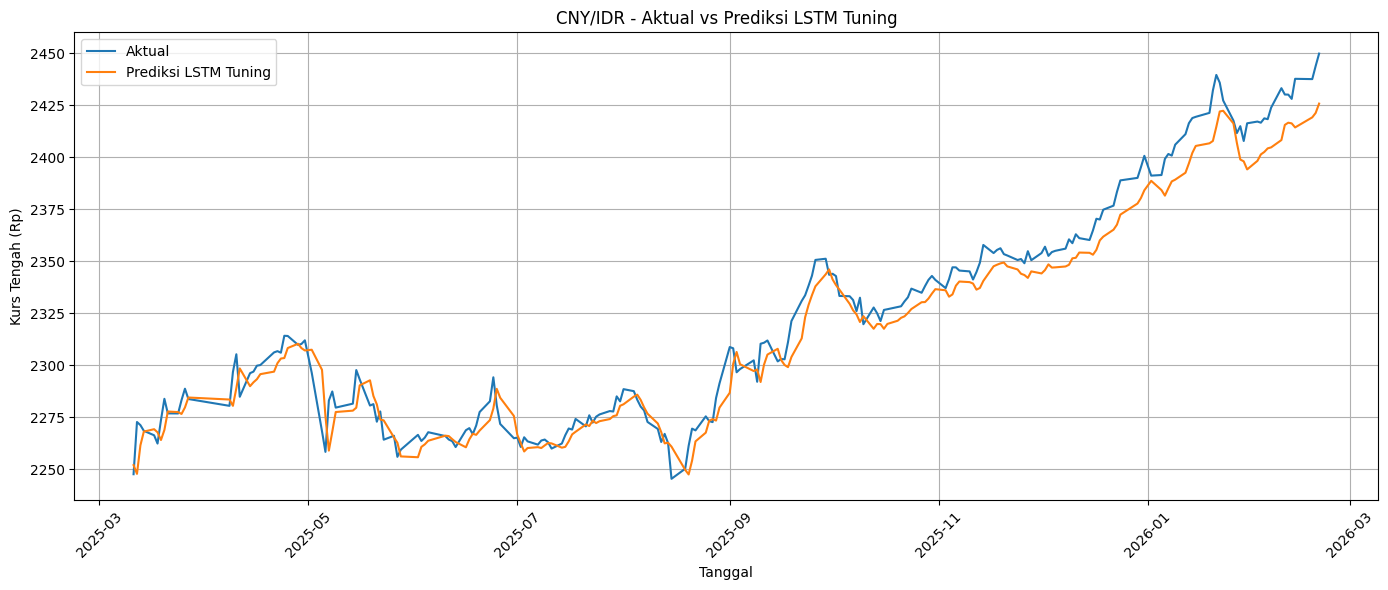

In [94]:
cny_lstm_tune_dates = cny_test.index[-len(y_true_cny_lstm_tune):]

plt.figure(figsize=(14, 6))
plt.plot(cny_lstm_tune_dates, y_true_cny_lstm_tune, label="Aktual")
plt.plot(cny_lstm_tune_dates, y_pred_cny_lstm_tune, label="Prediksi LSTM Tuning")
plt.title("CNY/IDR - Aktual vs Prediksi LSTM Tuning")
plt.xlabel("Tanggal")
plt.ylabel("Kurs Tengah (Rp)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

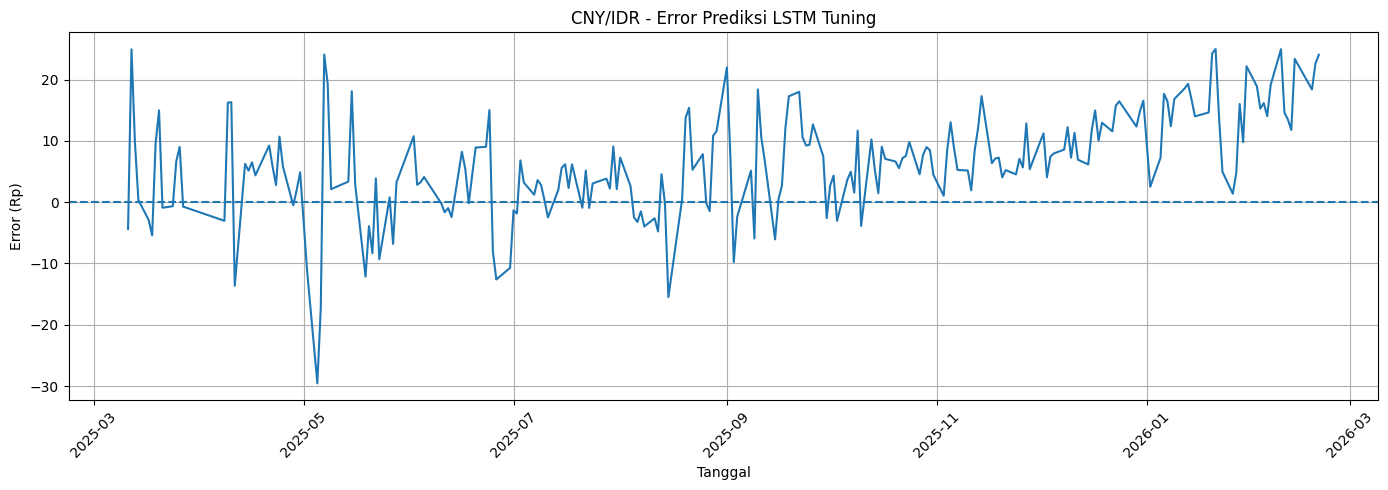

In [95]:
error_cny_lstm_tune = y_true_cny_lstm_tune - y_pred_cny_lstm_tune

plt.figure(figsize=(14, 5))
plt.plot(cny_lstm_tune_dates, error_cny_lstm_tune)
plt.axhline(0, linestyle="--")
plt.title("CNY/IDR - Error Prediksi LSTM Tuning")
plt.xlabel("Tanggal")
plt.ylabel("Error (Rp)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

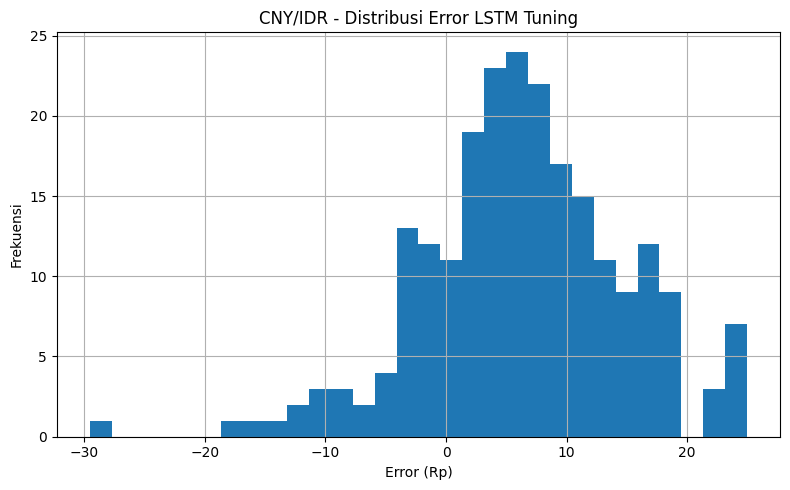

In [96]:
plt.figure(figsize=(8, 5))
plt.hist(error_cny_lstm_tune, bins=30)
plt.title("CNY/IDR - Distribusi Error LSTM Tuning")
plt.xlabel("Error (Rp)")
plt.ylabel("Frekuensi")
plt.grid(True)
plt.tight_layout()
plt.show()

In [97]:
cny_lstm_tune_table = pd.DataFrame({
    "Tanggal": cny_lstm_tune_dates,
    "Aktual (Rp)": np.array(y_true_cny_lstm_tune).reshape(-1),
    "Prediksi LSTM Tuning (Rp)": np.array(y_pred_cny_lstm_tune).reshape(-1)
})

cny_lstm_tune_table["Error (Rp)"] = (
    cny_lstm_tune_table["Aktual (Rp)"] - cny_lstm_tune_table["Prediksi LSTM Tuning (Rp)"]
)

cny_lstm_tune_table["APE (%)"] = (
    np.abs(cny_lstm_tune_table["Error (Rp)"]) / cny_lstm_tune_table["Aktual (Rp)"]
) * 100

numeric_cols = cny_lstm_tune_table.select_dtypes(include=["number"]).columns
cny_lstm_tune_table[numeric_cols] = cny_lstm_tune_table[numeric_cols].round(2)

cny_lstm_tune_table.head(30)

,Tanggal,Aktual (Rp),Prediksi LSTM Tuning (Rp),Error (Rp),APE (%)
0,2025-03-11,2247.570068,2251.939941,-4.380000,0.19
1,2025-03-12,2272.679932,2247.739990,24.940001,1.10
2,2025-03-13,2271.169922,2261.469971,9.700000,0.43
3,2025-03-14,2268.439941,2268.080078,0.360000,0.02
4,2025-03-17,2266.300049,2269.209961,-2.920000,0.13
5,2025-03-18,2262.310059,2267.729980,-5.420000,0.24
6,2025-03-19,2273.600098,2264.020020,9.580000,0.42
7,2025-03-20,2283.840088,2268.850098,14.990000,0.66
8,2025-03-21,2276.820068,2277.729980,-0.900000,0.04
9,2025-03-24,2276.790039,2277.439941,-0.660000,0.03


In [98]:
cny_lstm_tune_error_table = cny_lstm_tune_table.copy()
cny_lstm_tune_error_table["Abs Error (Rp)"] = np.abs(cny_lstm_tune_error_table["Error (Rp)"])

top10_error_terbesar_cny_lstm = cny_lstm_tune_error_table.sort_values(
    by="Abs Error (Rp)",
    ascending=False
).reset_index(drop=True)

top10_error_terbesar_cny_lstm.head(10)

,Tanggal,Aktual (Rp),Prediksi LSTM Tuning (Rp),Error (Rp),APE (%),Abs Error (Rp)
0,2025-05-05,2268.209961,2297.770020,-29.549999,1.30,29.549999
1,2026-01-21,2439.570068,2414.590088,24.980000,1.02,24.980000
2,2026-02-09,2433.199951,2408.250000,24.950001,1.03,24.950001
3,2025-03-12,2272.679932,2247.739990,24.940001,1.10,24.940001
4,2026-01-20,2432.090088,2407.820068,24.270000,1.00,24.270000
5,2025-05-07,2283.020020,2258.929932,24.090000,1.06,24.090000
6,2026-02-20,2449.830078,2425.780029,24.049999,0.98,24.049999
7,2026-02-13,2437.699951,2414.330078,23.370001,0.96,23.370001
8,2026-02-19,2443.889893,2421.300049,22.590000,0.92,22.590000
9,2026-01-30,2416.310059,2394.139893,22.170000,0.92,22.170000


In [99]:
print("Rata-rata Error:", np.mean(error_cny_lstm_tune).round(4))
print("Rata-rata Absolute Error:", np.mean(np.abs(error_cny_lstm_tune)).round(4))
print("Error Maksimum:", np.max(np.abs(error_cny_lstm_tune)).round(4))
print("Error Minimum:", np.min(error_cny_lstm_tune).round(4))
print("Error Maksimum Positif:", np.max(error_cny_lstm_tune).round(4))

Rata-rata Error: 6.3176
Rata-rata Absolute Error: 8.4868
Error Maksimum: 29.5522
Error Minimum: -29.5522
Error Maksimum Positif: 24.981


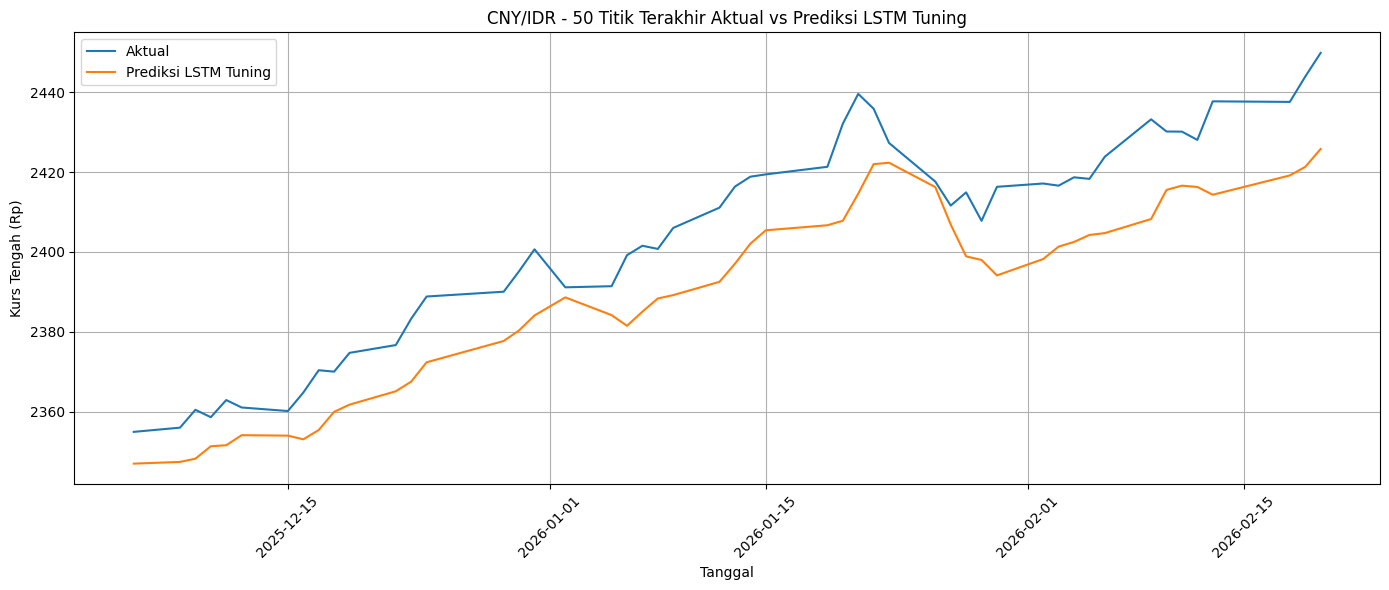

In [100]:
plot_df_cny_lstm = cny_lstm_tune_table.tail(50)

plt.figure(figsize=(14, 6))
plt.plot(plot_df_cny_lstm["Tanggal"], plot_df_cny_lstm["Aktual (Rp)"], label="Aktual")
plt.plot(plot_df_cny_lstm["Tanggal"], plot_df_cny_lstm["Prediksi LSTM Tuning (Rp)"], label="Prediksi LSTM Tuning")
plt.title("CNY/IDR - 50 Titik Terakhir Aktual vs Prediksi LSTM Tuning")
plt.xlabel("Tanggal")
plt.ylabel("Kurs Tengah (Rp)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

cny gru

In [101]:
cny_gru_tuning_results = run_tuning_experiment(
    train_scaled=cny_train_scaled,
    val_scaled=cny_val_scaled,
    test_scaled=cny_test_scaled,
    scaler=cny_scaler,
    model_builder=build_gru_tuning,
    param_grid=param_grid,
    save_dir="saved_models/cny_gru",
    experiment_name="cny_gru",
    max_epochs=500,
    patience=20,
    min_delta=1e-5,
    seed=42
)

best_cny_gru_row, best_cny_gru_test_metrics, y_true_cny_gru_tune, y_pred_cny_gru_tune = evaluate_best_model_on_test(
    results_df=cny_gru_tuning_results,
    train_scaled=cny_train_scaled,
    val_scaled=cny_val_scaled,
    test_scaled=cny_test_scaled,
    scaler=cny_scaler
)

cny_gru_tuning_results

[cny_gru] Eksperimen 1 | window=14, units=32, dropout=0.0, lr=0.001, batch=16
[cny_gru] Eksperimen 2 | window=14, units=32, dropout=0.0, lr=0.001, batch=32
[cny_gru] Eksperimen 3 | window=14, units=32, dropout=0.0, lr=0.0005, batch=16
[cny_gru] Eksperimen 4 | window=14, units=32, dropout=0.0, lr=0.0005, batch=32
[cny_gru] Eksperimen 5 | window=14, units=32, dropout=0.1, lr=0.001, batch=16
[cny_gru] Eksperimen 6 | window=14, units=32, dropout=0.1, lr=0.001, batch=32
[cny_gru] Eksperimen 7 | window=14, units=32, dropout=0.1, lr=0.0005, batch=16
[cny_gru] Eksperimen 8 | window=14, units=32, dropout=0.1, lr=0.0005, batch=32
[cny_gru] Eksperimen 9 | window=14, units=32, dropout=0.2, lr=0.001, batch=16
[cny_gru] Eksperimen 10 | window=14, units=32, dropout=0.2, lr=0.001, batch=32
[cny_gru] Eksperimen 11 | window=14, units=32, dropout=0.2, lr=0.0005, batch=16
[cny_gru] Eksperimen 12 | window=14, units=32, dropout=0.2, lr=0.0005, batch=32
[cny_gru] Eksperimen 13 | window=14, units=64, dropout=

,Eksperimen,Window Size,Units,Dropout,Learning Rate,Batch Size,Best Epoch,Epoch Berhenti,Best Val Loss,Model Path
0,25,14,128,0.0,0.0010,16,46,49,0.000491,saved_models/cny_gru\cny_gru_exp_25.keras
1,1,14,32,0.0,0.0010,16,41,50,0.000496,saved_models/cny_gru\cny_gru_exp_1.keras
2,65,30,128,0.1,0.0010,16,42,44,0.000500,saved_models/cny_gru\cny_gru_exp_65.keras
3,53,30,64,0.1,0.0010,16,40,60,0.000501,saved_models/cny_gru\cny_gru_exp_53.keras
4,33,14,128,0.2,0.0010,16,43,45,0.000501,saved_models/cny_gru\cny_gru_exp_33.keras
...,...,...,...,...,...,...,...,...,...,...
103,48,30,32,0.2,0.0005,32,41,61,0.000860,saved_models/cny_gru\cny_gru_exp_48.keras
104,80,60,32,0.1,0.0005,32,64,70,0.000937,saved_models/cny_gru\cny_gru_exp_80.keras
105,84,60,32,0.2,0.0005,32,59,79,0.000943,saved_models/cny_gru\cny_gru_exp_84.keras
106,12,14,32,0.2,0.0005,32,40,60,0.000947,saved_models/cny_gru\cny_gru_exp_12.keras


In [102]:
best_cny_gru_row

Eksperimen                                               25
Window Size                                              14
Units                                                   128
Dropout                                                 0.0
Learning Rate                                         0.001
Batch Size                                               16
Best Epoch                                               46
Epoch Berhenti                                           49
Best Val Loss                                      0.000491
Model Path        saved_models/cny_gru\cny_gru_exp_25.keras
Name: 0, dtype: object

In [103]:
best_cny_gru_test_metrics

{'MAE': 5.821609020233154,
 'RMSE': np.float64(7.690312809131688),
 'MAPE (%)': np.float32(0.25056532)}

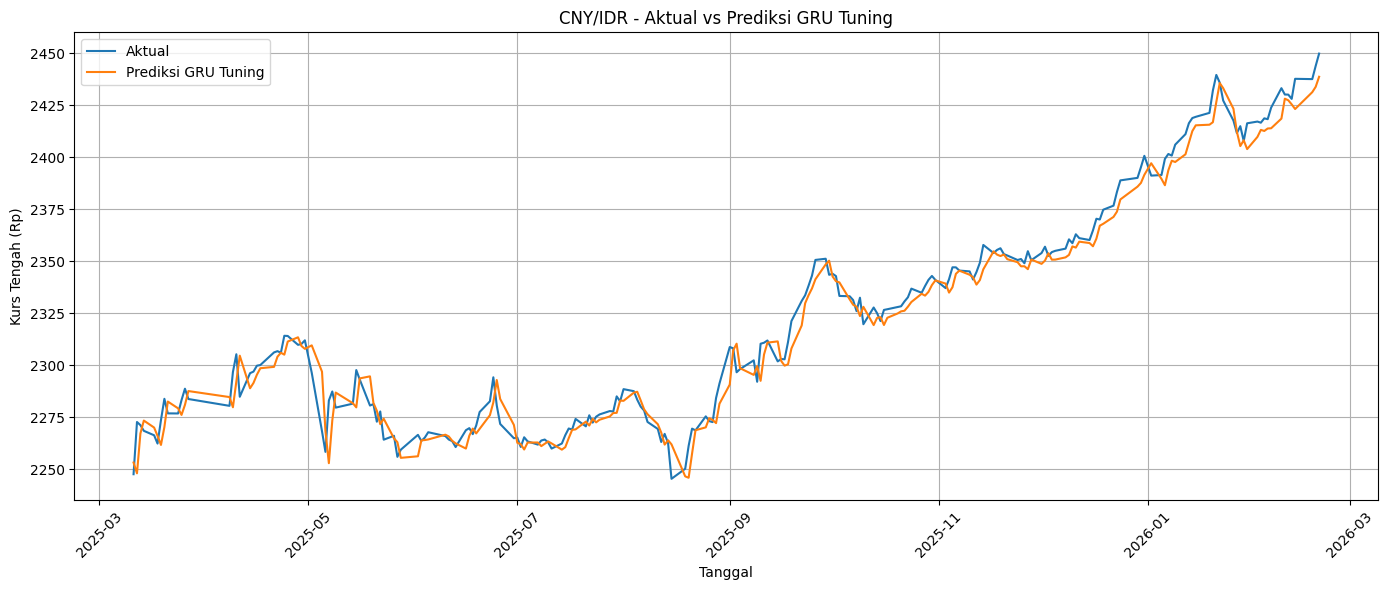

In [104]:
cny_gru_tune_dates = cny_test.index[-len(y_true_cny_gru_tune):]

plt.figure(figsize=(14, 6))
plt.plot(cny_gru_tune_dates, y_true_cny_gru_tune, label="Aktual")
plt.plot(cny_gru_tune_dates, y_pred_cny_gru_tune, label="Prediksi GRU Tuning")
plt.title("CNY/IDR - Aktual vs Prediksi GRU Tuning")
plt.xlabel("Tanggal")
plt.ylabel("Kurs Tengah (Rp)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

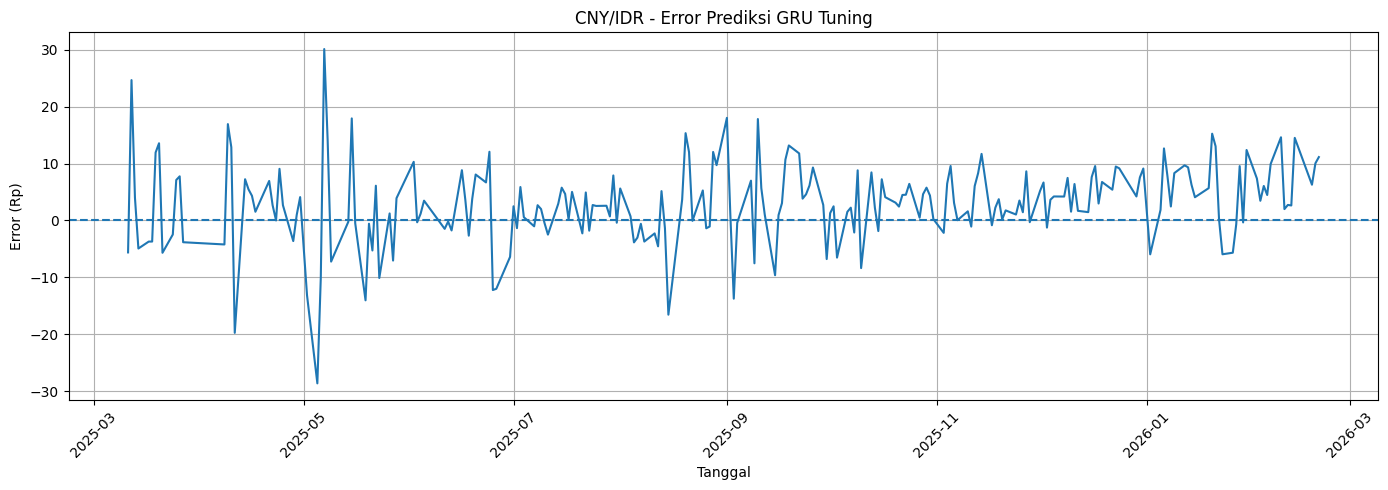

In [105]:
error_cny_gru_tune = y_true_cny_gru_tune - y_pred_cny_gru_tune

plt.figure(figsize=(14, 5))
plt.plot(cny_gru_tune_dates, error_cny_gru_tune)
plt.axhline(0, linestyle="--")
plt.title("CNY/IDR - Error Prediksi GRU Tuning")
plt.xlabel("Tanggal")
plt.ylabel("Error (Rp)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

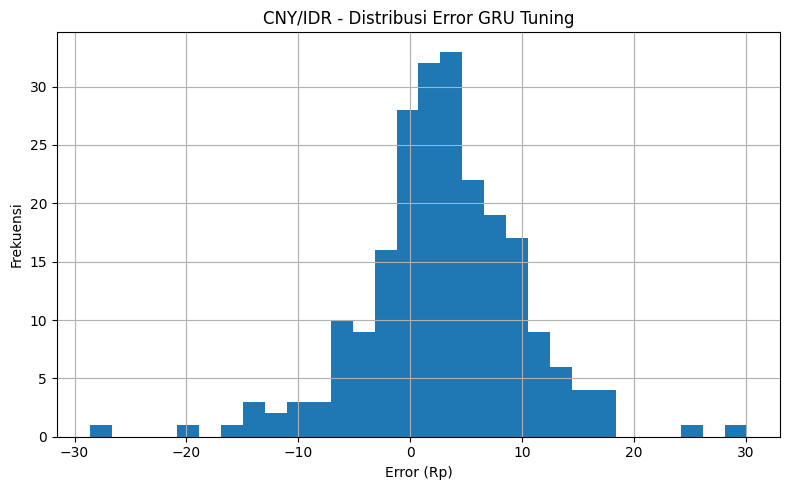

In [106]:
plt.figure(figsize=(8, 5))
plt.hist(error_cny_gru_tune, bins=30)
plt.title("CNY/IDR - Distribusi Error GRU Tuning")
plt.xlabel("Error (Rp)")
plt.ylabel("Frekuensi")
plt.grid(True)
plt.tight_layout()
plt.show()

In [108]:
cny_gru_tune_table = pd.DataFrame({
    "Tanggal": cny_gru_tune_dates,
    "Aktual (Rp)": np.array(y_true_cny_gru_tune).reshape(-1),
    "Prediksi GRU Tuning (Rp)": np.array(y_pred_cny_gru_tune).reshape(-1)
})

cny_gru_tune_table["Error (Rp)"] = (
    cny_gru_tune_table["Aktual (Rp)"] - cny_gru_tune_table["Prediksi GRU Tuning (Rp)"]
)

cny_gru_tune_table["APE (%)"] = (
    np.abs(cny_gru_tune_table["Error (Rp)"]) / cny_gru_tune_table["Aktual (Rp)"]
) * 100

numeric_cols = cny_gru_tune_table.select_dtypes(include=["number"]).columns
cny_gru_tune_table[numeric_cols] = cny_gru_tune_table[numeric_cols].round(2)

cny_gru_tune_table.head(30)

,Tanggal,Aktual (Rp),Prediksi GRU Tuning (Rp),Error (Rp),APE (%)
0,2025-03-11,2247.570068,2253.189941,-5.620000,0.25
1,2025-03-12,2272.679932,2248.000000,24.680000,1.09
2,2025-03-13,2271.169922,2267.159912,4.010000,0.18
3,2025-03-14,2268.439941,2273.370117,-4.930000,0.22
4,2025-03-17,2266.300049,2270.010010,-3.710000,0.16
5,2025-03-18,2262.310059,2266.020020,-3.710000,0.16
6,2025-03-19,2273.600098,2261.649902,11.950000,0.53
7,2025-03-20,2283.840088,2270.250000,13.580000,0.59
8,2025-03-21,2276.820068,2282.510010,-5.680000,0.25
9,2025-03-24,2276.790039,2279.250000,-2.460000,0.11


In [109]:
cny_gru_tune_error_table = cny_gru_tune_table.copy()
cny_gru_tune_error_table["Abs Error (Rp)"] = np.abs(cny_gru_tune_error_table["Error (Rp)"])

top10_error_terbesar_cny_gru = cny_gru_tune_error_table.sort_values(
    by="Abs Error (Rp)",
    ascending=False
).reset_index(drop=True)

top10_error_terbesar_cny_gru.head(10)

,Tanggal,Aktual (Rp),Prediksi GRU Tuning (Rp),Error (Rp),APE (%),Abs Error (Rp)
0,2025-05-07,2283.020020,2252.879883,30.139999,1.32,30.139999
1,2025-05-05,2268.209961,2296.860107,-28.639999,1.26,28.639999
2,2025-03-12,2272.679932,2248.000000,24.680000,1.09,24.680000
3,2025-04-11,2284.820068,2304.580078,-19.760000,0.86,19.760000
4,2025-09-01,2308.729980,2290.689941,18.040001,0.78,18.040001
5,2025-05-15,2297.659912,2279.709961,17.950001,0.78,17.950001
6,2025-09-10,2310.310059,2292.469971,17.840000,0.77,17.840000
7,2025-04-09,2296.709961,2279.770020,16.940001,0.74,16.940001
8,2025-08-15,2245.360107,2261.929932,-16.570000,0.74,16.570000
9,2025-08-20,2261.219971,2245.870117,15.350000,0.68,15.350000


In [110]:
print("Rata-rata Error:", np.mean(error_cny_gru_tune).round(4))
print("Rata-rata Absolute Error:", np.mean(np.abs(error_cny_gru_tune)).round(4))
print("Error Maksimum:", np.max(np.abs(error_cny_gru_tune)).round(4))
print("Error Minimum:", np.min(error_cny_gru_tune).round(4))
print("Error Maksimum Positif:", np.max(error_cny_gru_tune).round(4))

Rata-rata Error: 2.9649
Rata-rata Absolute Error: 5.8216
Error Maksimum: 30.1436
Error Minimum: -28.6416
Error Maksimum Positif: 30.1436


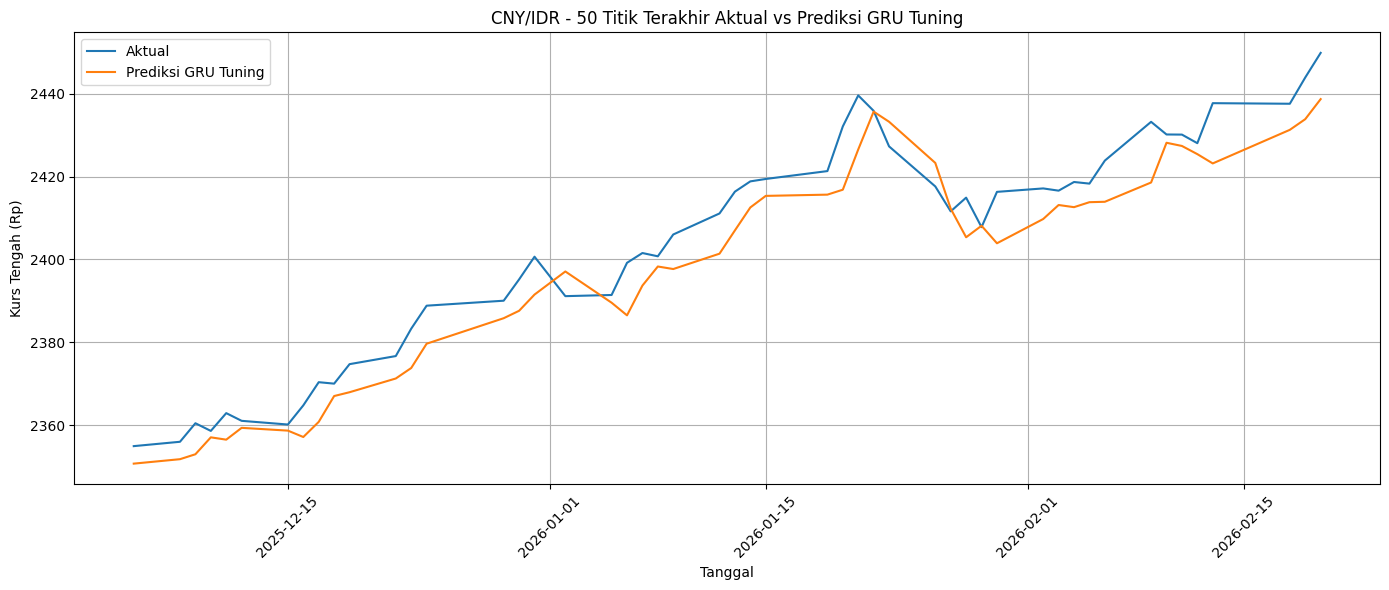

In [111]:
plot_df_cny_gru = cny_gru_tune_table.tail(50)

plt.figure(figsize=(14, 6))
plt.plot(plot_df_cny_gru["Tanggal"], plot_df_cny_gru["Aktual (Rp)"], label="Aktual")
plt.plot(plot_df_cny_gru["Tanggal"], plot_df_cny_gru["Prediksi GRU Tuning (Rp)"], label="Prediksi GRU Tuning")
plt.title("CNY/IDR - 50 Titik Terakhir Aktual vs Prediksi GRU Tuning")
plt.xlabel("Tanggal")
plt.ylabel("Kurs Tengah (Rp)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

rekap skenario 3

In [155]:
usd_tuning_compare = pd.DataFrame({
    "Tanggal": usd_test.index[-len(y_true_usd_lstm_tune):],
    "Aktual (Rp)": np.array(y_true_usd_lstm_tune).reshape(-1),
    "Prediksi LSTM Tuning (Rp)": np.array(y_pred_usd_lstm_tune).reshape(-1),
    "Prediksi GRU Tuning (Rp)": np.array(y_pred_usd_gru_tune).reshape(-1),
})

usd_tuning_compare["Error LSTM Tuning (Rp)"] = (
    usd_tuning_compare["Aktual (Rp)"] - usd_tuning_compare["Prediksi LSTM Tuning (Rp)"]
)

usd_tuning_compare["Error GRU Tuning (Rp)"] = (
    usd_tuning_compare["Aktual (Rp)"] - usd_tuning_compare["Prediksi GRU Tuning (Rp)"]
)

usd_tuning_compare["APE LSTM Tuning (%)"] = (
    np.abs(usd_tuning_compare["Error LSTM Tuning (Rp)"]) / usd_tuning_compare["Aktual (Rp)"]
) * 100

usd_tuning_compare["APE GRU Tuning (%)"] = (
    np.abs(usd_tuning_compare["Error GRU Tuning (Rp)"]) / usd_tuning_compare["Aktual (Rp)"]
) * 100

usd_tuning_compare["Model Lebih Dekat"] = np.where(
    np.abs(usd_tuning_compare["Error LSTM Tuning (Rp)"]) < np.abs(usd_tuning_compare["Error GRU Tuning (Rp)"]),
    "LSTM Tuning",
    np.where(
        np.abs(usd_tuning_compare["Error GRU Tuning (Rp)"]) < np.abs(usd_tuning_compare["Error LSTM Tuning (Rp)"]),
        "GRU Tuning",
        "Seri"
    )
)

numeric_cols = usd_tuning_compare.select_dtypes(include=["number"]).columns
usd_tuning_compare[numeric_cols] = usd_tuning_compare[numeric_cols].round(2)

usd_tuning_compare.head(20)

,Tanggal,Aktual (Rp),Prediksi LSTM Tuning (Rp),Prediksi GRU Tuning (Rp),Error LSTM Tuning (Rp),Error GRU Tuning (Rp),APE LSTM Tuning (%),APE GRU Tuning (%),Model Lebih Dekat
0,2025-03-11,16326.0,16322.419922,16323.089844,3.580000,2.910000,0.02,0.02,GRU Tuning
1,2025-03-12,16430.0,16330.639648,16312.379883,99.360001,117.620003,0.60,0.72,LSTM Tuning
2,2025-03-13,16453.0,16406.689453,16431.109375,46.310001,21.889999,0.28,0.13,GRU Tuning
3,2025-03-14,16428.0,16450.519531,16450.519531,-22.520000,-22.520000,0.14,0.14,GRU Tuning
4,2025-03-17,16392.0,16426.199219,16408.519531,-34.209999,-16.520000,0.21,0.10,GRU Tuning
5,2025-03-18,16379.0,16378.879883,16372.320312,0.120000,6.680000,0.00,0.04,LSTM Tuning
6,2025-03-19,16432.0,16359.589844,16363.860352,72.410004,68.139999,0.44,0.41,GRU Tuning
7,2025-03-20,16528.0,16407.279297,16428.039062,120.709999,99.959999,0.73,0.60,GRU Tuning
8,2025-03-21,16481.0,16505.669922,16534.359375,-24.670000,-53.360001,0.15,0.32,LSTM Tuning
9,2025-03-24,16501.0,16493.009766,16463.140625,7.990000,37.860001,0.05,0.23,LSTM Tuning


In [156]:
cny_tuning_compare = pd.DataFrame({
    "Tanggal": cny_test.index[-len(y_true_cny_lstm_tune):],
    "Aktual (Rp)": np.array(y_true_cny_lstm_tune).reshape(-1),
    "Prediksi LSTM Tuning (Rp)": np.array(y_pred_cny_lstm_tune).reshape(-1),
    "Prediksi GRU Tuning (Rp)": np.array(y_pred_cny_gru_tune).reshape(-1),
})

cny_tuning_compare["Error LSTM Tuning (Rp)"] = (
    cny_tuning_compare["Aktual (Rp)"] - cny_tuning_compare["Prediksi LSTM Tuning (Rp)"]
)

cny_tuning_compare["Error GRU Tuning (Rp)"] = (
    cny_tuning_compare["Aktual (Rp)"] - cny_tuning_compare["Prediksi GRU Tuning (Rp)"]
)

cny_tuning_compare["APE LSTM Tuning (%)"] = (
    np.abs(cny_tuning_compare["Error LSTM Tuning (Rp)"]) / cny_tuning_compare["Aktual (Rp)"]
) * 100

cny_tuning_compare["APE GRU Tuning (%)"] = (
    np.abs(cny_tuning_compare["Error GRU Tuning (Rp)"]) / cny_tuning_compare["Aktual (Rp)"]
) * 100

cny_tuning_compare["Model Lebih Dekat"] = np.where(
    np.abs(cny_tuning_compare["Error LSTM Tuning (Rp)"]) < np.abs(cny_tuning_compare["Error GRU Tuning (Rp)"]),
    "LSTM Tuning",
    np.where(
        np.abs(cny_tuning_compare["Error GRU Tuning (Rp)"]) < np.abs(cny_tuning_compare["Error LSTM Tuning (Rp)"]),
        "GRU Tuning",
        "Seri"
    )
)

numeric_cols = cny_tuning_compare.select_dtypes(include=["number"]).columns
cny_tuning_compare[numeric_cols] = cny_tuning_compare[numeric_cols].round(2)

cny_tuning_compare.head(20)

,Tanggal,Aktual (Rp),Prediksi LSTM Tuning (Rp),Prediksi GRU Tuning (Rp),Error LSTM Tuning (Rp),Error GRU Tuning (Rp),APE LSTM Tuning (%),APE GRU Tuning (%),Model Lebih Dekat
0,2025-03-11,2247.570068,2251.939941,2253.189941,-4.380000,-5.620000,0.19,0.25,LSTM Tuning
1,2025-03-12,2272.679932,2247.739990,2248.000000,24.940001,24.680000,1.10,1.09,GRU Tuning
2,2025-03-13,2271.169922,2261.469971,2267.159912,9.700000,4.010000,0.43,0.18,GRU Tuning
3,2025-03-14,2268.439941,2268.080078,2273.370117,0.360000,-4.930000,0.02,0.22,LSTM Tuning
4,2025-03-17,2266.300049,2269.209961,2270.010010,-2.920000,-3.710000,0.13,0.16,LSTM Tuning
5,2025-03-18,2262.310059,2267.729980,2266.020020,-5.420000,-3.710000,0.24,0.16,GRU Tuning
6,2025-03-19,2273.600098,2264.020020,2261.649902,9.580000,11.950000,0.42,0.53,LSTM Tuning
7,2025-03-20,2283.840088,2268.850098,2270.250000,14.990000,13.580000,0.66,0.59,GRU Tuning
8,2025-03-21,2276.820068,2277.729980,2282.510010,-0.900000,-5.680000,0.04,0.25,LSTM Tuning
9,2025-03-24,2276.790039,2277.439941,2279.250000,-0.660000,-2.460000,0.03,0.11,LSTM Tuning


In [157]:
usd_tuning_closest_summary = usd_tuning_compare["Model Lebih Dekat"].value_counts().reset_index()
usd_tuning_closest_summary.columns = ["Model", "Jumlah Lebih Dekat"]

usd_total = len(usd_tuning_compare)
usd_tuning_closest_summary["Persentase (%)"] = (
    usd_tuning_closest_summary["Jumlah Lebih Dekat"] / usd_total * 100
).round(2)

usd_tuning_closest_summary

,Model,Jumlah Lebih Dekat,Persentase (%)
0,GRU Tuning,131,58.22
1,LSTM Tuning,94,41.78


In [158]:
cny_tuning_closest_summary = cny_tuning_compare["Model Lebih Dekat"].value_counts().reset_index()
cny_tuning_closest_summary.columns = ["Model", "Jumlah Lebih Dekat"]

cny_total = len(cny_tuning_compare)
cny_tuning_closest_summary["Persentase (%)"] = (
    cny_tuning_closest_summary["Jumlah Lebih Dekat"] / cny_total * 100
).round(2)

cny_tuning_closest_summary

,Model,Jumlah Lebih Dekat,Persentase (%)
0,GRU Tuning,168,74.67
1,LSTM Tuning,57,25.33


In [159]:
summary_tuning = pd.DataFrame([
    {
        "Mata Uang": "USD/IDR",
        "Model": "LSTM Tuning",
        "Window Size": int(best_usd_lstm_row["Window Size"]),
        "Units": int(best_usd_lstm_row["Units"]),
        "Dropout": float(best_usd_lstm_row["Dropout"]),
        "Learning Rate": float(best_usd_lstm_row["Learning Rate"]),
        "Batch Size": int(best_usd_lstm_row["Batch Size"]),
        "Best Epoch": int(best_usd_lstm_row["Best Epoch"]),
        "Epoch Berhenti": int(best_usd_lstm_row["Epoch Berhenti"]),
        "MAE": best_usd_lstm_test_metrics["MAE"],
        "RMSE": best_usd_lstm_test_metrics["RMSE"],
        "MAPE (%)": best_usd_lstm_test_metrics["MAPE (%)"]
    },
    {
        "Mata Uang": "USD/IDR",
        "Model": "GRU Tuning",
        "Window Size": int(best_usd_gru_row["Window Size"]),
        "Units": int(best_usd_gru_row["Units"]),
        "Dropout": float(best_usd_gru_row["Dropout"]),
        "Learning Rate": float(best_usd_gru_row["Learning Rate"]),
        "Batch Size": int(best_usd_gru_row["Batch Size"]),
        "Best Epoch": int(best_usd_gru_row["Best Epoch"]),
        "Epoch Berhenti": int(best_usd_gru_row["Epoch Berhenti"]),
        "MAE": best_usd_gru_test_metrics["MAE"],
        "RMSE": best_usd_gru_test_metrics["RMSE"],
        "MAPE (%)": best_usd_gru_test_metrics["MAPE (%)"]
    },
    {
        "Mata Uang": "CNY/IDR",
        "Model": "LSTM Tuning",
        "Window Size": int(best_cny_lstm_row["Window Size"]),
        "Units": int(best_cny_lstm_row["Units"]),
        "Dropout": float(best_cny_lstm_row["Dropout"]),
        "Learning Rate": float(best_cny_lstm_row["Learning Rate"]),
        "Batch Size": int(best_cny_lstm_row["Batch Size"]),
        "Best Epoch": int(best_cny_lstm_row["Best Epoch"]),
        "Epoch Berhenti": int(best_cny_lstm_row["Epoch Berhenti"]),
        "MAE": best_cny_lstm_test_metrics["MAE"],
        "RMSE": best_cny_lstm_test_metrics["RMSE"],
        "MAPE (%)": best_cny_lstm_test_metrics["MAPE (%)"]
    },
    {
        "Mata Uang": "CNY/IDR",
        "Model": "GRU Tuning",
        "Window Size": int(best_cny_gru_row["Window Size"]),
        "Units": int(best_cny_gru_row["Units"]),
        "Dropout": float(best_cny_gru_row["Dropout"]),
        "Learning Rate": float(best_cny_gru_row["Learning Rate"]),
        "Batch Size": int(best_cny_gru_row["Batch Size"]),
        "Best Epoch": int(best_cny_gru_row["Best Epoch"]),
        "Epoch Berhenti": int(best_cny_gru_row["Epoch Berhenti"]),
        "MAE": best_cny_gru_test_metrics["MAE"],
        "RMSE": best_cny_gru_test_metrics["RMSE"],
        "MAPE (%)": best_cny_gru_test_metrics["MAPE (%)"]
    }
])

summary_tuning = summary_tuning.round({
    "MAE": 4,
    "RMSE": 4,
    "MAPE (%)": 4
})

summary_tuning

,Mata Uang,Model,Window Size,Units,Dropout,Learning Rate,Batch Size,Best Epoch,Epoch Berhenti,MAE,RMSE,MAPE (%)
0,USD/IDR,LSTM Tuning,60,128,0.0,0.001,16,66,80,43.3391,56.6666,0.2614
1,USD/IDR,GRU Tuning,14,128,0.0,0.001,16,40,46,40.5664,53.6434,0.2450
2,CNY/IDR,LSTM Tuning,14,32,0.0,0.001,16,64,73,8.4868,10.5220,0.3625
3,CNY/IDR,GRU Tuning,14,128,0.0,0.001,16,46,49,5.8216,7.6903,0.2506


In [160]:
summary_tuning_ranked = summary_tuning.sort_values(
    by=["Mata Uang", "RMSE", "MAE", "MAPE (%)"],
    ascending=[True, True, True, True]
).reset_index(drop=True)

summary_tuning_ranked

,Mata Uang,Model,Window Size,Units,Dropout,Learning Rate,Batch Size,Best Epoch,Epoch Berhenti,MAE,RMSE,MAPE (%)
0,CNY/IDR,GRU Tuning,14,128,0.0,0.001,16,46,49,5.8216,7.6903,0.2506
1,CNY/IDR,LSTM Tuning,14,32,0.0,0.001,16,64,73,8.4868,10.5220,0.3625
2,USD/IDR,GRU Tuning,14,128,0.0,0.001,16,40,46,40.5664,53.6434,0.2450
3,USD/IDR,LSTM Tuning,60,128,0.0,0.001,16,66,80,43.3391,56.6666,0.2614


In [162]:
usd_tuning_compare_simple = usd_tuning_compare[
    [
        "Tanggal",
        "Aktual (Rp)",
        "Prediksi LSTM Tuning (Rp)",
        "Prediksi GRU Tuning (Rp)",
        "Model Lebih Dekat"
    ]
].copy()

usd_tuning_compare_simple.head(20)

,Tanggal,Aktual (Rp),Prediksi LSTM Tuning (Rp),Prediksi GRU Tuning (Rp),Model Lebih Dekat
0,2025-03-11,16326.0,16322.419922,16323.089844,GRU Tuning
1,2025-03-12,16430.0,16330.639648,16312.379883,LSTM Tuning
2,2025-03-13,16453.0,16406.689453,16431.109375,GRU Tuning
3,2025-03-14,16428.0,16450.519531,16450.519531,GRU Tuning
4,2025-03-17,16392.0,16426.199219,16408.519531,GRU Tuning
5,2025-03-18,16379.0,16378.879883,16372.320312,LSTM Tuning
6,2025-03-19,16432.0,16359.589844,16363.860352,GRU Tuning
7,2025-03-20,16528.0,16407.279297,16428.039062,GRU Tuning
8,2025-03-21,16481.0,16505.669922,16534.359375,LSTM Tuning
9,2025-03-24,16501.0,16493.009766,16463.140625,LSTM Tuning


In [163]:
cny_tuning_compare_simple = cny_tuning_compare[
    [
        "Tanggal",
        "Aktual (Rp)",
        "Prediksi LSTM Tuning (Rp)",
        "Prediksi GRU Tuning (Rp)",
        "Model Lebih Dekat"
    ]
].copy()

cny_tuning_compare_simple.head(20)

,Tanggal,Aktual (Rp),Prediksi LSTM Tuning (Rp),Prediksi GRU Tuning (Rp),Model Lebih Dekat
0,2025-03-11,2247.570068,2251.939941,2253.189941,LSTM Tuning
1,2025-03-12,2272.679932,2247.739990,2248.000000,GRU Tuning
2,2025-03-13,2271.169922,2261.469971,2267.159912,GRU Tuning
3,2025-03-14,2268.439941,2268.080078,2273.370117,LSTM Tuning
4,2025-03-17,2266.300049,2269.209961,2270.010010,LSTM Tuning
5,2025-03-18,2262.310059,2267.729980,2266.020020,GRU Tuning
6,2025-03-19,2273.600098,2264.020020,2261.649902,LSTM Tuning
7,2025-03-20,2283.840088,2268.850098,2270.250000,GRU Tuning
8,2025-03-21,2276.820068,2277.729980,2282.510010,LSTM Tuning
9,2025-03-24,2276.790039,2277.439941,2279.250000,LSTM Tuning


Pada skenario 3, saya melakukan tuning hyperparameter untuk LSTM dan GRU. Untuk memperkuat hasil, saya tidak hanya melihat metrik evaluasi, tetapi juga membandingkan langsung angka aktual dengan prediksi LSTM tuning dan GRU tuning dalam satu tabel.

Pada USD/IDR, prediksi GRU tuning lebih sering paling dekat dengan nilai aktual, dan ini konsisten dengan metrik evaluasi yang menunjukkan MAE 40,5664, RMSE 53,6434, dan MAPE 0,2450%, lebih baik daripada LSTM tuning.

Pada CNY/IDR, hasil yang sama juga terjadi. Prediksi GRU tuning lebih dekat terhadap nilai aktual dan menghasilkan MAE 5,8216, RMSE 7,6903, dan MAPE 0,2506%, lebih baik daripada LSTM tuning.

Jadi, skenario tuning menunjukkan bahwa baik USD/IDR maupun CNY/IDR paling baik diprediksi oleh GRU tuning.

### SUMMARY SKENARIO 1, 2 DAN 3

In [164]:
summary_final_all = pd.DataFrame([
    # =========================
    # SKENARIO 1 - BASELINE
    # =========================
    {
        "Mata Uang": "USD/IDR",
        "Skenario": "Baseline",
        "Model": "LSTM",
        "Best Epoch": int(np.argmin(hist_lstm_usd.history["val_loss"]) + 1),
        "Epoch Berhenti": int(len(hist_lstm_usd.history["loss"])),
        "Window Size": 30,
        "Units": 64,
        "Dropout": 0.0,
        "Learning Rate": 0.001,
        "Batch Size": 32,
        "MAE": res_lstm_usd["MAE"],
        "RMSE": res_lstm_usd["RMSE"],
        "MAPE (%)": res_lstm_usd["MAPE(%)"]
    },
    {
        "Mata Uang": "USD/IDR",
        "Skenario": "Baseline",
        "Model": "GRU",
        "Best Epoch": int(np.argmin(hist_gru_usd.history["val_loss"]) + 1),
        "Epoch Berhenti": int(len(hist_gru_usd.history["loss"])),
        "Window Size": 30,
        "Units": 64,
        "Dropout": 0.0,
        "Learning Rate": 0.001,
        "Batch Size": 32,
        "MAE": res_gru_usd["MAE"],
        "RMSE": res_gru_usd["RMSE"],
        "MAPE (%)": res_gru_usd["MAPE(%)"]
    },
    {
        "Mata Uang": "CNY/IDR",
        "Skenario": "Baseline",
        "Model": "LSTM",
        "Best Epoch": int(np.argmin(hist_lstm_cny.history["val_loss"]) + 1),
        "Epoch Berhenti": int(len(hist_lstm_cny.history["loss"])),
        "Window Size": 30,
        "Units": 64,
        "Dropout": 0.0,
        "Learning Rate": 0.001,
        "Batch Size": 32,
        "MAE": res_lstm_cny["MAE"],
        "RMSE": res_lstm_cny["RMSE"],
        "MAPE (%)": res_lstm_cny["MAPE(%)"]
    },
    {
        "Mata Uang": "CNY/IDR",
        "Skenario": "Baseline",
        "Model": "GRU",
        "Best Epoch": int(np.argmin(hist_gru_cny.history["val_loss"]) + 1),
        "Epoch Berhenti": int(len(hist_gru_cny.history["loss"])),
        "Window Size": 30,
        "Units": 64,
        "Dropout": 0.0,
        "Learning Rate": 0.001,
        "Batch Size": 32,
        "MAE": res_gru_cny["MAE"],
        "RMSE": res_gru_cny["RMSE"],
        "MAPE (%)": res_gru_cny["MAPE(%)"]
    },

    # =========================
    # SKENARIO 2 - STACKED
    # =========================
    {
        "Mata Uang": "USD/IDR",
        "Skenario": "Stacked",
        "Model": "LSTM",
        "Best Epoch": int(np.argmin(hist_st_lstm_usd.history["val_loss"]) + 1),
        "Epoch Berhenti": int(len(hist_st_lstm_usd.history["loss"])),
        "Window Size": 30,
        "Units": 64,
        "Dropout": 0.1,
        "Learning Rate": 0.001,
        "Batch Size": 32,
        "MAE": res_st_lstm_usd["MAE"],
        "RMSE": res_st_lstm_usd["RMSE"],
        "MAPE (%)": res_st_lstm_usd["MAPE(%)"]
    },
    {
        "Mata Uang": "USD/IDR",
        "Skenario": "Stacked",
        "Model": "GRU",
        "Best Epoch": int(np.argmin(hist_st_gru_usd.history["val_loss"]) + 1),
        "Epoch Berhenti": int(len(hist_st_gru_usd.history["loss"])),
        "Window Size": 30,
        "Units": 64,
        "Dropout": 0.1,
        "Learning Rate": 0.001,
        "Batch Size": 32,
        "MAE": res_st_gru_usd["MAE"],
        "RMSE": res_st_gru_usd["RMSE"],
        "MAPE (%)": res_st_gru_usd["MAPE(%)"]
    },
    {
        "Mata Uang": "CNY/IDR",
        "Skenario": "Stacked",
        "Model": "LSTM",
        "Best Epoch": int(np.argmin(hist_st_lstm_cny.history["val_loss"]) + 1),
        "Epoch Berhenti": int(len(hist_st_lstm_cny.history["loss"])),
        "Window Size": 30,
        "Units": 64,
        "Dropout": 0.1,
        "Learning Rate": 0.001,
        "Batch Size": 32,
        "MAE": res_st_lstm_cny["MAE"],
        "RMSE": res_st_lstm_cny["RMSE"],
        "MAPE (%)": res_st_lstm_cny["MAPE(%)"]
    },
    {
        "Mata Uang": "CNY/IDR",
        "Skenario": "Stacked",
        "Model": "GRU",
        "Best Epoch": int(np.argmin(hist_st_gru_cny.history["val_loss"]) + 1),
        "Epoch Berhenti": int(len(hist_st_gru_cny.history["loss"])),
        "Window Size": 30,
        "Units": 64,
        "Dropout": 0.1,
        "Learning Rate": 0.001,
        "Batch Size": 32,
        "MAE": res_st_gru_cny["MAE"],
        "RMSE": res_st_gru_cny["RMSE"],
        "MAPE (%)": res_st_gru_cny["MAPE(%)"]
    },

    # =========================
    # SKENARIO 3 - TUNING
    # =========================
    {
        "Mata Uang": "USD/IDR",
        "Skenario": "Tuning",
        "Model": "LSTM",
        "Best Epoch": int(best_usd_lstm_row["Best Epoch"]),
        "Epoch Berhenti": int(best_usd_lstm_row["Epoch Berhenti"]),
        "Window Size": int(best_usd_lstm_row["Window Size"]),
        "Units": int(best_usd_lstm_row["Units"]),
        "Dropout": float(best_usd_lstm_row["Dropout"]),
        "Learning Rate": float(best_usd_lstm_row["Learning Rate"]),
        "Batch Size": int(best_usd_lstm_row["Batch Size"]),
        "MAE": best_usd_lstm_test_metrics["MAE"],
        "RMSE": best_usd_lstm_test_metrics["RMSE"],
        "MAPE (%)": best_usd_lstm_test_metrics["MAPE (%)"]
    },
    {
        "Mata Uang": "USD/IDR",
        "Skenario": "Tuning",
        "Model": "GRU",
        "Best Epoch": int(best_usd_gru_row["Best Epoch"]),
        "Epoch Berhenti": int(best_usd_gru_row["Epoch Berhenti"]),
        "Window Size": int(best_usd_gru_row["Window Size"]),
        "Units": int(best_usd_gru_row["Units"]),
        "Dropout": float(best_usd_gru_row["Dropout"]),
        "Learning Rate": float(best_usd_gru_row["Learning Rate"]),
        "Batch Size": int(best_usd_gru_row["Batch Size"]),
        "MAE": best_usd_gru_test_metrics["MAE"],
        "RMSE": best_usd_gru_test_metrics["RMSE"],
        "MAPE (%)": best_usd_gru_test_metrics["MAPE (%)"]
    },
    {
        "Mata Uang": "CNY/IDR",
        "Skenario": "Tuning",
        "Model": "LSTM",
        "Best Epoch": int(best_cny_lstm_row["Best Epoch"]),
        "Epoch Berhenti": int(best_cny_lstm_row["Epoch Berhenti"]),
        "Window Size": int(best_cny_lstm_row["Window Size"]),
        "Units": int(best_cny_lstm_row["Units"]),
        "Dropout": float(best_cny_lstm_row["Dropout"]),
        "Learning Rate": float(best_cny_lstm_row["Learning Rate"]),
        "Batch Size": int(best_cny_lstm_row["Batch Size"]),
        "MAE": best_cny_lstm_test_metrics["MAE"],
        "RMSE": best_cny_lstm_test_metrics["RMSE"],
        "MAPE (%)": best_cny_lstm_test_metrics["MAPE (%)"]
    },
    {
        "Mata Uang": "CNY/IDR",
        "Skenario": "Tuning",
        "Model": "GRU",
        "Best Epoch": int(best_cny_gru_row["Best Epoch"]),
        "Epoch Berhenti": int(best_cny_gru_row["Epoch Berhenti"]),
        "Window Size": int(best_cny_gru_row["Window Size"]),
        "Units": int(best_cny_gru_row["Units"]),
        "Dropout": float(best_cny_gru_row["Dropout"]),
        "Learning Rate": float(best_cny_gru_row["Learning Rate"]),
        "Batch Size": int(best_cny_gru_row["Batch Size"]),
        "MAE": best_cny_gru_test_metrics["MAE"],
        "RMSE": best_cny_gru_test_metrics["RMSE"],
        "MAPE (%)": best_cny_gru_test_metrics["MAPE (%)"]
    }
])

summary_final_all = summary_final_all.round({
    "Dropout": 2,
    "Learning Rate": 4,
    "MAE": 4,
    "RMSE": 4,
    "MAPE (%)": 4
})

summary_final_all

,Mata Uang,Skenario,Model,Best Epoch,Epoch Berhenti,Window Size,Units,Dropout,Learning Rate,Batch Size,MAE,RMSE,MAPE (%)
0,USD/IDR,Baseline,LSTM,98,98,30,64,0.0,0.001,32,58.7403,73.2208,0.3541
1,USD/IDR,Baseline,GRU,56,56,30,64,0.0,0.001,32,62.8310,76.2527,0.3789
2,CNY/IDR,Baseline,LSTM,85,85,30,64,0.0,0.001,32,12.2752,14.3812,0.5260
3,CNY/IDR,Baseline,GRU,59,59,30,64,0.0,0.001,32,7.6314,9.3654,0.3275
4,USD/IDR,Stacked,LSTM,52,77,30,64,0.1,0.001,32,94.9710,107.9531,0.5716
5,USD/IDR,Stacked,GRU,26,51,30,64,0.1,0.001,32,54.2805,67.0008,0.3272
6,CNY/IDR,Stacked,LSTM,107,107,30,64,0.1,0.001,32,11.4975,14.0053,0.4895
7,CNY/IDR,Stacked,GRU,79,83,30,64,0.1,0.001,32,8.4947,10.3327,0.3636
8,USD/IDR,Tuning,LSTM,66,80,60,128,0.0,0.001,16,43.3391,56.6666,0.2614
9,USD/IDR,Tuning,GRU,40,46,14,128,0.0,0.001,16,40.5664,53.6434,0.2450


In [165]:
summary_final_ranked = summary_final_all.sort_values(
    by=["Mata Uang", "RMSE", "MAE", "MAPE (%)"],
    ascending=[True, True, True, True]
).reset_index(drop=True)

summary_final_ranked

,Mata Uang,Skenario,Model,Best Epoch,Epoch Berhenti,Window Size,Units,Dropout,Learning Rate,Batch Size,MAE,RMSE,MAPE (%)
0,CNY/IDR,Tuning,GRU,46,49,14,128,0.0,0.001,16,5.8216,7.6903,0.2506
1,CNY/IDR,Baseline,GRU,59,59,30,64,0.0,0.001,32,7.6314,9.3654,0.3275
2,CNY/IDR,Stacked,GRU,79,83,30,64,0.1,0.001,32,8.4947,10.3327,0.3636
3,CNY/IDR,Tuning,LSTM,64,73,14,32,0.0,0.001,16,8.4868,10.5220,0.3625
4,CNY/IDR,Stacked,LSTM,107,107,30,64,0.1,0.001,32,11.4975,14.0053,0.4895
5,CNY/IDR,Baseline,LSTM,85,85,30,64,0.0,0.001,32,12.2752,14.3812,0.5260
6,USD/IDR,Tuning,GRU,40,46,14,128,0.0,0.001,16,40.5664,53.6434,0.2450
7,USD/IDR,Tuning,LSTM,66,80,60,128,0.0,0.001,16,43.3391,56.6666,0.2614
8,USD/IDR,Stacked,GRU,26,51,30,64,0.1,0.001,32,54.2805,67.0008,0.3272
9,USD/IDR,Baseline,LSTM,98,98,30,64,0.0,0.001,32,58.7403,73.2208,0.3541


In [166]:
summary_final_usd = summary_final_all[
    summary_final_all["Mata Uang"] == "USD/IDR"
].sort_values(
    by=["RMSE", "MAE", "MAPE (%)"],
    ascending=[True, True, True]
).reset_index(drop=True)

summary_final_usd

,Mata Uang,Skenario,Model,Best Epoch,Epoch Berhenti,Window Size,Units,Dropout,Learning Rate,Batch Size,MAE,RMSE,MAPE (%)
0,USD/IDR,Tuning,GRU,40,46,14,128,0.0,0.001,16,40.5664,53.6434,0.2450
1,USD/IDR,Tuning,LSTM,66,80,60,128,0.0,0.001,16,43.3391,56.6666,0.2614
2,USD/IDR,Stacked,GRU,26,51,30,64,0.1,0.001,32,54.2805,67.0008,0.3272
3,USD/IDR,Baseline,LSTM,98,98,30,64,0.0,0.001,32,58.7403,73.2208,0.3541
4,USD/IDR,Baseline,GRU,56,56,30,64,0.0,0.001,32,62.8310,76.2527,0.3789
5,USD/IDR,Stacked,LSTM,52,77,30,64,0.1,0.001,32,94.9710,107.9531,0.5716


In [167]:
summary_final_cny = summary_final_all[
    summary_final_all["Mata Uang"] == "CNY/IDR"
].sort_values(
    by=["RMSE", "MAE", "MAPE (%)"],
    ascending=[True, True, True]
).reset_index(drop=True)

summary_final_cny

,Mata Uang,Skenario,Model,Best Epoch,Epoch Berhenti,Window Size,Units,Dropout,Learning Rate,Batch Size,MAE,RMSE,MAPE (%)
0,CNY/IDR,Tuning,GRU,46,49,14,128,0.0,0.001,16,5.8216,7.6903,0.2506
1,CNY/IDR,Baseline,GRU,59,59,30,64,0.0,0.001,32,7.6314,9.3654,0.3275
2,CNY/IDR,Stacked,GRU,79,83,30,64,0.1,0.001,32,8.4947,10.3327,0.3636
3,CNY/IDR,Tuning,LSTM,64,73,14,32,0.0,0.001,16,8.4868,10.5220,0.3625
4,CNY/IDR,Stacked,LSTM,107,107,30,64,0.1,0.001,32,11.4975,14.0053,0.4895
5,CNY/IDR,Baseline,LSTM,85,85,30,64,0.0,0.001,32,12.2752,14.3812,0.5260


In [177]:
summary_final_best = summary_final_all.copy()

summary_final_best["Peringkat"] = (
    summary_final_best
    .groupby("Mata Uang")["RMSE"]
    .rank(method="dense", ascending=True)
)

summary_final_best["Keterangan"] = summary_final_best["Peringkat"].apply(
    lambda x: "Terbaik" if x == 1 else ""
)

summary_final_best = summary_final_best.sort_values(
    by=["Mata Uang", "Peringkat", "RMSE", "MAE", "MAPE (%)"]
).reset_index(drop=True)

summary_final_best

,Mata Uang,Skenario,Model,Best Epoch,Epoch Berhenti,Window Size,Units,Dropout,Learning Rate,Batch Size,MAE,RMSE,MAPE (%),Peringkat,Keterangan
0,CNY/IDR,Tuning,GRU,46,49,14,128,0.0,0.001,16,5.8216,7.6903,0.2506,1.0,Terbaik
1,CNY/IDR,Baseline,GRU,59,59,30,64,0.0,0.001,32,7.6314,9.3654,0.3275,2.0,
2,CNY/IDR,Stacked,GRU,79,83,30,64,0.1,0.001,32,8.4947,10.3327,0.3636,3.0,
3,CNY/IDR,Tuning,LSTM,64,73,14,32,0.0,0.001,16,8.4868,10.5220,0.3625,4.0,
4,CNY/IDR,Stacked,LSTM,107,107,30,64,0.1,0.001,32,11.4975,14.0053,0.4895,5.0,
5,CNY/IDR,Baseline,LSTM,85,85,30,64,0.0,0.001,32,12.2752,14.3812,0.5260,6.0,
6,USD/IDR,Tuning,GRU,40,46,14,128,0.0,0.001,16,40.5664,53.6434,0.2450,1.0,Terbaik
7,USD/IDR,Tuning,LSTM,66,80,60,128,0.0,0.001,16,43.3391,56.6666,0.2614,2.0,
8,USD/IDR,Stacked,GRU,26,51,30,64,0.1,0.001,32,54.2805,67.0008,0.3272,3.0,
9,USD/IDR,Baseline,LSTM,98,98,30,64,0.0,0.001,32,58.7403,73.2208,0.3541,4.0,


In [169]:
pivot_final_usd = summary_final_all[
    summary_final_all["Mata Uang"] == "USD/IDR"
].pivot_table(
    index=["Skenario", "Model"],
    values=[
        "Best Epoch", "Epoch Berhenti", "Window Size", "Units",
        "Dropout", "Learning Rate", "Batch Size",
        "MAE", "RMSE", "MAPE (%)"
    ],
    aggfunc="first"
)

pivot_final_usd

Batch Size  Best Epoch  Dropout  Epoch Berhenti  \
Skenario Model                                                    
Baseline GRU            32          56      0.0              56   
         LSTM           32          98      0.0              98   
Stacked  GRU            32          26      0.1              51   
         LSTM           32          52      0.1              77   
Tuning   GRU            16          40      0.0              46   
         LSTM           16          66      0.0              80   

                Learning Rate      MAE  MAPE (%)      RMSE  Units  Window Size  
Skenario Model                                                                  
Baseline GRU            0.001  62.8310    0.3789   76.2527     64           30  
         LSTM           0.001  58.7403    0.3541   73.2208     64           30  
Stacked  GRU            0.001  54.2805    0.3272   67.0008     64           30  
         LSTM           0.001  94.9710    0.5716  107.9531     64           30  
Tuning   GRU            0.001  40.5664    0.2450   53.6434    128           14  
         LSTM           0.001  43.3391    0.2614   56.6666    128           60

In [170]:
pivot_final_cny = summary_final_all[
    summary_final_all["Mata Uang"] == "CNY/IDR"
].pivot_table(
    index=["Skenario", "Model"],
    values=[
        "Best Epoch", "Epoch Berhenti", "Window Size", "Units",
        "Dropout", "Learning Rate", "Batch Size",
        "MAE", "RMSE", "MAPE (%)"
    ],
    aggfunc="first"
)

pivot_final_cny

Batch Size  Best Epoch  Dropout  Epoch Berhenti  \
Skenario Model                                                    
Baseline GRU            32          59      0.0              59   
         LSTM           32          85      0.0              85   
Stacked  GRU            32          79      0.1              83   
         LSTM           32         107      0.1             107   
Tuning   GRU            16          46      0.0              49   
         LSTM           16          64      0.0              73   

                Learning Rate      MAE  MAPE (%)     RMSE  Units  Window Size  
Skenario Model                                                                 
Baseline GRU            0.001   7.6314    0.3275   9.3654     64           30  
         LSTM           0.001  12.2752    0.5260  14.3812     64           30  
Stacked  GRU            0.001   8.4947    0.3636  10.3327     64           30  
         LSTM           0.001  11.4975    0.4895  14.0053     64           30  
Tuning   GRU            0.001   5.8216    0.2506   7.6903    128           14  
         LSTM           0.001   8.4868    0.3625  10.5220     32           14

In [171]:
usd_final_compare = pd.DataFrame({
    "Tanggal": usd_test.index[-len(y_true_usd_gru_tune):],
    "Aktual (Rp)": np.array(y_true_usd_gru_tune).reshape(-1),
    "Prediksi Baseline LSTM (Rp)": np.array(y_pred_usd).reshape(-1),
    "Prediksi Baseline GRU (Rp)": np.array(y_pred_usd2).reshape(-1),
    "Prediksi Stacked LSTM (Rp)": np.array(y_pred_usd_st).reshape(-1),
    "Prediksi Stacked GRU (Rp)": np.array(y_pred_usd_st2).reshape(-1),
    "Prediksi LSTM Tuning (Rp)": np.array(y_pred_usd_lstm_tune).reshape(-1),
    "Prediksi GRU Tuning (Rp)": np.array(y_pred_usd_gru_tune).reshape(-1),
})

usd_final_compare["Error Baseline LSTM (Rp)"] = usd_final_compare["Aktual (Rp)"] - usd_final_compare["Prediksi Baseline LSTM (Rp)"]
usd_final_compare["Error Baseline GRU (Rp)"] = usd_final_compare["Aktual (Rp)"] - usd_final_compare["Prediksi Baseline GRU (Rp)"]
usd_final_compare["Error Stacked LSTM (Rp)"] = usd_final_compare["Aktual (Rp)"] - usd_final_compare["Prediksi Stacked LSTM (Rp)"]
usd_final_compare["Error Stacked GRU (Rp)"] = usd_final_compare["Aktual (Rp)"] - usd_final_compare["Prediksi Stacked GRU (Rp)"]
usd_final_compare["Error LSTM Tuning (Rp)"] = usd_final_compare["Aktual (Rp)"] - usd_final_compare["Prediksi LSTM Tuning (Rp)"]
usd_final_compare["Error GRU Tuning (Rp)"] = usd_final_compare["Aktual (Rp)"] - usd_final_compare["Prediksi GRU Tuning (Rp)"]

usd_final_compare["APE Baseline LSTM (%)"] = np.abs(usd_final_compare["Error Baseline LSTM (Rp)"]) / usd_final_compare["Aktual (Rp)"] * 100
usd_final_compare["APE Baseline GRU (%)"] = np.abs(usd_final_compare["Error Baseline GRU (Rp)"]) / usd_final_compare["Aktual (Rp)"] * 100
usd_final_compare["APE Stacked LSTM (%)"] = np.abs(usd_final_compare["Error Stacked LSTM (Rp)"]) / usd_final_compare["Aktual (Rp)"] * 100
usd_final_compare["APE Stacked GRU (%)"] = np.abs(usd_final_compare["Error Stacked GRU (Rp)"]) / usd_final_compare["Aktual (Rp)"] * 100
usd_final_compare["APE LSTM Tuning (%)"] = np.abs(usd_final_compare["Error LSTM Tuning (Rp)"]) / usd_final_compare["Aktual (Rp)"] * 100
usd_final_compare["APE GRU Tuning (%)"] = np.abs(usd_final_compare["Error GRU Tuning (Rp)"]) / usd_final_compare["Aktual (Rp)"] * 100

usd_final_compare["Model Paling Dekat"] = usd_final_compare[
    [
        "APE Baseline LSTM (%)",
        "APE Baseline GRU (%)",
        "APE Stacked LSTM (%)",
        "APE Stacked GRU (%)",
        "APE LSTM Tuning (%)",
        "APE GRU Tuning (%)"
    ]
].idxmin(axis=1)

usd_final_compare["Model Paling Dekat"] = usd_final_compare["Model Paling Dekat"].replace({
    "APE Baseline LSTM (%)": "Baseline LSTM",
    "APE Baseline GRU (%)": "Baseline GRU",
    "APE Stacked LSTM (%)": "Stacked LSTM",
    "APE Stacked GRU (%)": "Stacked GRU",
    "APE LSTM Tuning (%)": "LSTM Tuning",
    "APE GRU Tuning (%)": "GRU Tuning"
})

numeric_cols = usd_final_compare.select_dtypes(include=["number"]).columns
usd_final_compare[numeric_cols] = usd_final_compare[numeric_cols].round(2)

usd_final_compare.head(20)

,Tanggal,Aktual (Rp),Prediksi Baseline LSTM (Rp),Prediksi Baseline GRU (Rp),Prediksi Stacked LSTM (Rp),Prediksi Stacked GRU (Rp),Prediksi LSTM Tuning (Rp),Prediksi GRU Tuning (Rp),Error Baseline LSTM (Rp),Error Baseline GRU (Rp),...,Error Stacked GRU (Rp),Error LSTM Tuning (Rp),Error GRU Tuning (Rp),APE Baseline LSTM (%),APE Baseline GRU (%),APE Stacked LSTM (%),APE Stacked GRU (%),APE LSTM Tuning (%),APE GRU Tuning (%),Model Paling Dekat
0,2025-03-11,16326.0,16307.290039,16277.200195,16244.740234,16287.700195,16322.419922,16323.089844,18.709999,48.799999,...,38.299999,3.580000,2.910000,0.11,0.30,0.50,0.23,0.02,0.02,GRU Tuning
1,2025-03-12,16430.0,16287.759766,16267.969727,16241.120117,16292.059570,16330.639648,16312.379883,142.240005,162.029999,...,137.940002,99.360001,117.620003,0.87,0.99,1.15,0.84,0.60,0.72,LSTM Tuning
2,2025-03-13,16453.0,16328.150391,16326.750000,16299.799805,16376.750000,16406.689453,16431.109375,124.849998,126.250000,...,76.250000,46.310001,21.889999,0.76,0.77,0.93,0.46,0.28,0.13,GRU Tuning
3,2025-03-14,16428.0,16374.099609,16385.490234,16359.919922,16426.400391,16450.519531,16450.519531,53.900002,42.509998,...,1.600000,-22.520000,-22.520000,0.33,0.26,0.41,0.01,0.14,0.14,Stacked GRU
4,2025-03-17,16392.0,16394.210938,16403.750000,16379.809570,16412.900391,16426.199219,16408.519531,-2.210000,-11.750000,...,-20.900000,-34.209999,-16.520000,0.01,0.07,0.07,0.13,0.21,0.10,Baseline LSTM
5,2025-03-18,16379.0,16387.109375,16384.449219,16360.660156,16371.780273,16378.879883,16372.320312,-8.110000,-5.450000,...,7.220000,0.120000,6.680000,0.05,0.03,0.11,0.04,0.00,0.04,LSTM Tuning
6,2025-03-19,16432.0,16371.780273,16357.849609,16332.549805,16347.530273,16359.589844,16363.860352,60.230000,74.150002,...,84.470001,72.410004,68.139999,0.37,0.45,0.61,0.51,0.44,0.41,Baseline LSTM
7,2025-03-20,16528.0,16383.400391,16369.929688,16340.410156,16385.919922,16407.279297,16428.039062,144.610001,158.070007,...,142.080002,120.709999,99.959999,0.87,0.96,1.13,0.86,0.73,0.60,GRU Tuning
8,2025-03-21,16481.0,16436.160156,16435.599609,16400.250000,16479.759766,16505.669922,16534.359375,44.840000,45.400002,...,1.240000,-24.670000,-53.360001,0.27,0.28,0.49,0.01,0.15,0.32,Stacked GRU
9,2025-03-24,16501.0,16452.160156,16455.089844,16420.199219,16470.330078,16493.009766,16463.140625,48.840000,45.910000,...,30.670000,7.990000,37.860001,0.30,0.28,0.49,0.19,0.05,0.23,LSTM Tuning


In [172]:
cny_final_compare = pd.DataFrame({
    "Tanggal": cny_test.index[-len(y_true_cny_gru_tune):],
    "Aktual (Rp)": np.array(y_true_cny_gru_tune).reshape(-1),
    "Prediksi Baseline LSTM (Rp)": np.array(y_pred_cny).reshape(-1),
    "Prediksi Baseline GRU (Rp)": np.array(y_pred_cny2).reshape(-1),
    "Prediksi Stacked LSTM (Rp)": np.array(y_pred_cny_st).reshape(-1),
    "Prediksi Stacked GRU (Rp)": np.array(y_pred_cny_st2).reshape(-1),
    "Prediksi LSTM Tuning (Rp)": np.array(y_pred_cny_lstm_tune).reshape(-1),
    "Prediksi GRU Tuning (Rp)": np.array(y_pred_cny_gru_tune).reshape(-1),
})

cny_final_compare["Error Baseline LSTM (Rp)"] = cny_final_compare["Aktual (Rp)"] - cny_final_compare["Prediksi Baseline LSTM (Rp)"]
cny_final_compare["Error Baseline GRU (Rp)"] = cny_final_compare["Aktual (Rp)"] - cny_final_compare["Prediksi Baseline GRU (Rp)"]
cny_final_compare["Error Stacked LSTM (Rp)"] = cny_final_compare["Aktual (Rp)"] - cny_final_compare["Prediksi Stacked LSTM (Rp)"]
cny_final_compare["Error Stacked GRU (Rp)"] = cny_final_compare["Aktual (Rp)"] - cny_final_compare["Prediksi Stacked GRU (Rp)"]
cny_final_compare["Error LSTM Tuning (Rp)"] = cny_final_compare["Aktual (Rp)"] - cny_final_compare["Prediksi LSTM Tuning (Rp)"]
cny_final_compare["Error GRU Tuning (Rp)"] = cny_final_compare["Aktual (Rp)"] - cny_final_compare["Prediksi GRU Tuning (Rp)"]

cny_final_compare["APE Baseline LSTM (%)"] = np.abs(cny_final_compare["Error Baseline LSTM (Rp)"]) / cny_final_compare["Aktual (Rp)"] * 100
cny_final_compare["APE Baseline GRU (%)"] = np.abs(cny_final_compare["Error Baseline GRU (Rp)"]) / cny_final_compare["Aktual (Rp)"] * 100
cny_final_compare["APE Stacked LSTM (%)"] = np.abs(cny_final_compare["Error Stacked LSTM (Rp)"]) / cny_final_compare["Aktual (Rp)"] * 100
cny_final_compare["APE Stacked GRU (%)"] = np.abs(cny_final_compare["Error Stacked GRU (Rp)"]) / cny_final_compare["Aktual (Rp)"] * 100
cny_final_compare["APE LSTM Tuning (%)"] = np.abs(cny_final_compare["Error LSTM Tuning (Rp)"]) / cny_final_compare["Aktual (Rp)"] * 100
cny_final_compare["APE GRU Tuning (%)"] = np.abs(cny_final_compare["Error GRU Tuning (Rp)"]) / cny_final_compare["Aktual (Rp)"] * 100

cny_final_compare["Model Paling Dekat"] = cny_final_compare[
    [
        "APE Baseline LSTM (%)",
        "APE Baseline GRU (%)",
        "APE Stacked LSTM (%)",
        "APE Stacked GRU (%)",
        "APE LSTM Tuning (%)",
        "APE GRU Tuning (%)"
    ]
].idxmin(axis=1)

cny_final_compare["Model Paling Dekat"] = cny_final_compare["Model Paling Dekat"].replace({
    "APE Baseline LSTM (%)": "Baseline LSTM",
    "APE Baseline GRU (%)": "Baseline GRU",
    "APE Stacked LSTM (%)": "Stacked LSTM",
    "APE Stacked GRU (%)": "Stacked GRU",
    "APE LSTM Tuning (%)": "LSTM Tuning",
    "APE GRU Tuning (%)": "GRU Tuning"
})

numeric_cols = cny_final_compare.select_dtypes(include=["number"]).columns
cny_final_compare[numeric_cols] = cny_final_compare[numeric_cols].round(2)

cny_final_compare.head(20)

,Tanggal,Aktual (Rp),Prediksi Baseline LSTM (Rp),Prediksi Baseline GRU (Rp),Prediksi Stacked LSTM (Rp),Prediksi Stacked GRU (Rp),Prediksi LSTM Tuning (Rp),Prediksi GRU Tuning (Rp),Error Baseline LSTM (Rp),Error Baseline GRU (Rp),...,Error Stacked GRU (Rp),Error LSTM Tuning (Rp),Error GRU Tuning (Rp),APE Baseline LSTM (%),APE Baseline GRU (%),APE Stacked LSTM (%),APE Stacked GRU (%),APE LSTM Tuning (%),APE GRU Tuning (%),Model Paling Dekat
0,2025-03-11,2247.570068,2257.429932,2251.030029,2249.879883,2251.540039,2251.939941,2253.189941,-9.860000,-3.460000,...,-3.970000,-4.380000,-5.620000,0.44,0.15,0.10,0.18,0.19,0.25,Stacked LSTM
1,2025-03-12,2272.679932,2254.169922,2247.310059,2246.820068,2247.810059,2247.739990,2248.000000,18.510000,25.370001,...,24.870001,24.940001,24.680000,0.81,1.12,1.14,1.09,1.10,1.09,Baseline LSTM
2,2025-03-13,2271.169922,2255.340088,2259.479980,2260.959961,2260.050049,2261.469971,2267.159912,15.830000,11.690000,...,11.120000,9.700000,4.010000,0.70,0.51,0.45,0.49,0.43,0.18,GRU Tuning
3,2025-03-14,2268.439941,2257.209961,2267.050049,2268.850098,2267.090088,2268.080078,2273.370117,11.230000,1.390000,...,1.340000,0.360000,-4.930000,0.49,0.06,0.02,0.06,0.02,0.22,LSTM Tuning
4,2025-03-17,2266.300049,2258.959961,2268.320068,2268.570068,2267.659912,2269.209961,2270.010010,7.340000,-2.020000,...,-1.360000,-2.920000,-3.710000,0.32,0.09,0.10,0.06,0.13,0.16,Stacked GRU
5,2025-03-18,2262.310059,2260.250000,2266.439941,2264.959961,2265.600098,2267.729980,2266.020020,2.060000,-4.130000,...,-3.290000,-5.420000,-3.710000,0.09,0.18,0.12,0.15,0.24,0.16,Baseline LSTM
6,2025-03-19,2273.600098,2260.520020,2262.500000,2260.040039,2261.939941,2264.020020,2261.649902,13.080000,11.100000,...,11.660000,9.580000,11.950000,0.58,0.49,0.60,0.51,0.42,0.53,LSTM Tuning
7,2025-03-20,2283.840088,2262.439941,2266.679932,2265.110107,2266.610107,2268.850098,2270.250000,21.389999,17.160000,...,17.219999,14.990000,13.580000,0.94,0.75,0.82,0.75,0.66,0.59,GRU Tuning
8,2025-03-21,2276.820068,2266.310059,2275.800049,2275.610107,2275.860107,2277.729980,2282.510010,10.520000,1.030000,...,0.970000,-0.900000,-5.680000,0.46,0.05,0.05,0.04,0.04,0.25,LSTM Tuning
9,2025-03-24,2276.790039,2269.000000,2276.820068,2275.919922,2276.310059,2277.439941,2279.250000,7.780000,-0.030000,...,0.470000,-0.660000,-2.460000,0.34,0.00,0.04,0.02,0.03,0.11,Baseline GRU


In [173]:
usd_final_closest_summary = usd_final_compare["Model Paling Dekat"].value_counts().reset_index()
usd_final_closest_summary.columns = ["Model", "Jumlah Menjadi Prediksi Terdekat"]

usd_total = len(usd_final_compare)
usd_final_closest_summary["Persentase (%)"] = (
    usd_final_closest_summary["Jumlah Menjadi Prediksi Terdekat"] / usd_total * 100
).round(2)

usd_final_closest_summary

,Model,Jumlah Menjadi Prediksi Terdekat,Persentase (%)
0,GRU Tuning,104,46.22
1,LSTM Tuning,50,22.22
2,Baseline LSTM,27,12.00
3,Stacked GRU,16,7.11
4,Stacked LSTM,15,6.67
5,Baseline GRU,13,5.78


Pada data USD/IDR, GRU tuning menjadi model yang paling sering menghasilkan prediksi terdekat terhadap nilai aktual, yaitu pada 104 observasi atau 46,22% dari total data uji. Temuan ini konsisten dengan metrik evaluasi yang juga menempatkan GRU tuning sebagai model terbaik.

In [174]:
cny_final_closest_summary = cny_final_compare["Model Paling Dekat"].value_counts().reset_index()
cny_final_closest_summary.columns = ["Model", "Jumlah Menjadi Prediksi Terdekat"]

cny_total = len(cny_final_compare)
cny_final_closest_summary["Persentase (%)"] = (
    cny_final_closest_summary["Jumlah Menjadi Prediksi Terdekat"] / cny_total * 100
).round(2)

cny_final_closest_summary

,Model,Jumlah Menjadi Prediksi Terdekat,Persentase (%)
0,GRU Tuning,140,62.22
1,Baseline LSTM,23,10.22
2,Stacked LSTM,17,7.56
3,LSTM Tuning,17,7.56
4,Baseline GRU,17,7.56
5,Stacked GRU,11,4.89


Pada data CNY/IDR, GRU tuning menunjukkan dominasi yang sangat kuat karena menjadi model yang paling dekat dengan nilai aktual pada 140 observasi atau 62,22% dari total data uji. Hasil ini memperkuat metrik evaluasi yang menunjukkan bahwa GRU tuning adalah model terbaik untuk CNY/IDR.

In [175]:
usd_final_compare_simple = usd_final_compare[
    [
        "Tanggal",
        "Aktual (Rp)",
        "Prediksi Baseline LSTM (Rp)",
        "Prediksi Baseline GRU (Rp)",
        "Prediksi Stacked LSTM (Rp)",
        "Prediksi Stacked GRU (Rp)",
        "Prediksi LSTM Tuning (Rp)",
        "Prediksi GRU Tuning (Rp)",
        "Model Paling Dekat"
    ]
].copy()

usd_final_compare_simple.head(20)

,Tanggal,Aktual (Rp),Prediksi Baseline LSTM (Rp),Prediksi Baseline GRU (Rp),Prediksi Stacked LSTM (Rp),Prediksi Stacked GRU (Rp),Prediksi LSTM Tuning (Rp),Prediksi GRU Tuning (Rp),Model Paling Dekat
0,2025-03-11,16326.0,16307.290039,16277.200195,16244.740234,16287.700195,16322.419922,16323.089844,GRU Tuning
1,2025-03-12,16430.0,16287.759766,16267.969727,16241.120117,16292.059570,16330.639648,16312.379883,LSTM Tuning
2,2025-03-13,16453.0,16328.150391,16326.750000,16299.799805,16376.750000,16406.689453,16431.109375,GRU Tuning
3,2025-03-14,16428.0,16374.099609,16385.490234,16359.919922,16426.400391,16450.519531,16450.519531,Stacked GRU
4,2025-03-17,16392.0,16394.210938,16403.750000,16379.809570,16412.900391,16426.199219,16408.519531,Baseline LSTM
5,2025-03-18,16379.0,16387.109375,16384.449219,16360.660156,16371.780273,16378.879883,16372.320312,LSTM Tuning
6,2025-03-19,16432.0,16371.780273,16357.849609,16332.549805,16347.530273,16359.589844,16363.860352,Baseline LSTM
7,2025-03-20,16528.0,16383.400391,16369.929688,16340.410156,16385.919922,16407.279297,16428.039062,GRU Tuning
8,2025-03-21,16481.0,16436.160156,16435.599609,16400.250000,16479.759766,16505.669922,16534.359375,Stacked GRU
9,2025-03-24,16501.0,16452.160156,16455.089844,16420.199219,16470.330078,16493.009766,16463.140625,LSTM Tuning


In [176]:
cny_final_compare_simple = cny_final_compare[
    [
        "Tanggal",
        "Aktual (Rp)",
        "Prediksi Baseline LSTM (Rp)",
        "Prediksi Baseline GRU (Rp)",
        "Prediksi Stacked LSTM (Rp)",
        "Prediksi Stacked GRU (Rp)",
        "Prediksi LSTM Tuning (Rp)",
        "Prediksi GRU Tuning (Rp)",
        "Model Paling Dekat"
    ]
].copy()

cny_final_compare_simple.head(20)

,Tanggal,Aktual (Rp),Prediksi Baseline LSTM (Rp),Prediksi Baseline GRU (Rp),Prediksi Stacked LSTM (Rp),Prediksi Stacked GRU (Rp),Prediksi LSTM Tuning (Rp),Prediksi GRU Tuning (Rp),Model Paling Dekat
0,2025-03-11,2247.570068,2257.429932,2251.030029,2249.879883,2251.540039,2251.939941,2253.189941,Stacked LSTM
1,2025-03-12,2272.679932,2254.169922,2247.310059,2246.820068,2247.810059,2247.739990,2248.000000,Baseline LSTM
2,2025-03-13,2271.169922,2255.340088,2259.479980,2260.959961,2260.050049,2261.469971,2267.159912,GRU Tuning
3,2025-03-14,2268.439941,2257.209961,2267.050049,2268.850098,2267.090088,2268.080078,2273.370117,LSTM Tuning
4,2025-03-17,2266.300049,2258.959961,2268.320068,2268.570068,2267.659912,2269.209961,2270.010010,Stacked GRU
5,2025-03-18,2262.310059,2260.250000,2266.439941,2264.959961,2265.600098,2267.729980,2266.020020,Baseline LSTM
6,2025-03-19,2273.600098,2260.520020,2262.500000,2260.040039,2261.939941,2264.020020,2261.649902,LSTM Tuning
7,2025-03-20,2283.840088,2262.439941,2266.679932,2265.110107,2266.610107,2268.850098,2270.250000,GRU Tuning
8,2025-03-21,2276.820068,2266.310059,2275.800049,2275.610107,2275.860107,2277.729980,2282.510010,LSTM Tuning
9,2025-03-24,2276.790039,2269.000000,2276.820068,2275.919922,2276.310059,2277.439941,2279.250000,Baseline GRU


dari keseluruhan eksperimen, USD/IDR baseline terbaik: LSTM, stacked terbaik: GRU, dan tuning terbaik: GRU. model terbaik berubah ketika kompleksitas model dan hyperparameter dioptimasi. Setelah tuning dilakukan, GRU menjadi model yang paling optimal.

CNY/IDR baseline terbaik: GRU, stacked terbaik: GRU, tuning terbaik: GRU. tuning hyperparameter terbukti penting karena mampu menghasilkan model final yang lebih akurat dibanding baseline maupun stacked, dan pada akhirnya GRU tuning menjadi model terbaik untuk kedua mata uang.

Berdasarkan gabungan hasil skenario 1, 2, dan 3, model terbaik untuk USD/IDR adalah GRU tuning, dengan nilai MAE 40,5664, RMSE 53,6434, dan MAPE 0,2450%. Selain unggul pada metrik evaluasi, model ini juga paling sering menghasilkan prediksi yang paling dekat dengan nilai aktual, yaitu sebanyak 104 observasi atau 46,22% dari total data uji.

Untuk CNY/IDR, model terbaik juga adalah GRU tuning, dengan nilai MAE 5,8216, RMSE 7,6903, dan MAPE 0,2506%. Model ini menjadi prediksi paling dekat pada 140 observasi atau 62,22% dari total data uji, sehingga keunggulannya sangat konsisten baik dari sisi metrik maupun kedekatan terhadap angka aktual.

Dengan demikian, hasil akhir penelitian menunjukkan bahwa setelah dilakukan perbandingan tiga skenario, yaitu baseline, stacked, dan tuning, model GRU tuning merupakan model paling optimal untuk memprediksi nilai tukar USD/IDR maupun CNY/IDR.